In [1]:
import pandas as pd
import numpy as np
from sklearn.preprocessing import StandardScaler

In [2]:
spotify = pd.read_csv("spotify_merged_clean.csv")

In [3]:
continuous_features = [
    'danceability',
    'energy',
    'loudness',
    'speechiness',
    'acousticness',
    'instrumentalness',
    'liveness',
    'valence',
    'tempo'
]

spotify[continuous_features] = StandardScaler().fit_transform(spotify[continuous_features])

spotify.drop(columns=['key', 'mode'], inplace=True)

# If you want a clustering input table, it can now be taken directly from spotify.
X_for_clustering = spotify[continuous_features].copy()

spotify[continuous_features]

,danceability,energy,loudness,speechiness,acousticness,instrumentalness,liveness,valence,tempo
0,1.868896,-1.123959,-0.335257,0.919773,-0.678968,-0.512296,-0.311653,-0.160929,-0.605689
1,0.592912,-0.364169,-1.029071,-0.417897,-0.909587,0.052991,-0.538150,-1.418237,-0.063065
2,0.553037,0.493659,0.944242,0.840984,-0.732788,-0.521856,-0.688270,1.418466,1.355952
3,-0.358380,-0.891120,-1.098452,-0.567597,-0.910132,1.764826,-0.640337,-0.929284,0.276147
4,0.570126,-1.013667,-0.380699,-0.615746,-0.050149,-0.484697,-0.655612,0.359068,-0.842090
...,...,...,...,...,...,...,...,...,...
106003,0.382146,0.755092,-0.657008,-0.474801,-0.084172,2.438127,-0.609786,-1.255252,0.107221
106004,2.170802,-0.188518,0.399132,0.753440,-0.704950,-0.521837,0.004389,0.673395,0.276793
106005,-0.705858,-0.445867,0.351863,-0.585981,1.298427,-0.520496,-0.517080,0.712201,0.692663
106006,-1.816647,1.257534,0.264629,-0.037081,-0.913043,-0.501847,0.868237,-1.045701,1.737234


In [4]:
GENRE_MAPPING = {
    # Rock
    "rock": "Rock",
    "alt-rock": "Rock",
    "album rock": "Rock",
    "classic rock": "Rock",
    "hard-rock": "Rock",
    "hard rock": "Rock",
    "psych-rock": "Rock",
    "rock-n-roll": "Rock",
    "rockabilly": "Rock",
    "grunge": "Rock",
    "j-rock": "Rock",
    "permanent wave": "Rock",

    # Punk / Alternative
    "alternative": "Alternative",
    "indie": "Alternative",
    "indie-pop": "Alternative",
    "indie poptimism": "Alternative",
    "emo": "Alternative",
    "goth": "Alternative",
    "punk": "Alternative",
    "punk-rock": "Alternative",

    # Metal
    "metal": "Metal",
    "heavy-metal": "Metal",
    "death-metal": "Metal",
    "black-metal": "Metal",
    "metalcore": "Metal",
    "grindcore": "Metal",
    "groove": "Metal",
    "hardcore": "Metal",

    # Pop
    "pop": "Pop",
    "dance pop": "Pop",
    "electropop": "Pop",
    "post-teen pop": "Pop",
    "power-pop": "Pop",
    "synth-pop": "Pop",
    "j-pop": "Pop",
    "k-pop": "Pop",
    "cantopop": "Pop",
    "mandopop": "Pop",
    "latin pop": "Pop",
    "hip pop": "Pop",

    # Hip Hop / R&B
    "rap": "Hip-Hop/R&B",
    "hip-hop": "Hip-Hop/R&B",
    "hip hop": "Hip-Hop/R&B",
    "r&b": "Hip-Hop/R&B",
    "r-n-b": "Hip-Hop/R&B",
    "neo soul": "Hip-Hop/R&B",
    "new jack swing": "Hip-Hop/R&B",
    "urban contemporary": "Hip-Hop/R&B",
    "southern hip hop": "Hip-Hop/R&B",
    "latin hip hop": "Hip-Hop/R&B",
    "gangster rap": "Hip-Hop/R&B",
    "trap": "Hip-Hop/R&B",
    "soul": "Hip-Hop/R&B",

    # Electronic
    "edm": "Electronic",
    "electronic": "Electronic",
    "electro": "Electronic",
    "house": "Electronic",
    "deep-house": "Electronic",
    "chicago-house": "Electronic",
    "progressive-house": "Electronic",
    "electro house": "Electronic",
    "progressive electro house": "Electronic",
    "techno": "Electronic",
    "minimal-techno": "Electronic",
    "detroit-techno": "Electronic",
    "trance": "Electronic",
    "dubstep": "Electronic",
    "drum-and-bass": "Electronic",
    "breakbeat": "Electronic",
    "garage": "Electronic",
    "idm": "Electronic",
    "club": "Electronic",
    "dance": "Electronic",
    "hardstyle": "Electronic",
    "big room": "Electronic",
    "pop edm": "Electronic",
    "disco": "Electronic",
    "industrial": "Electronic",

    # Ambient / Chill
    "ambient": "Ambient/Chill",
    "chill": "Ambient/Chill",
    "new-age": "Ambient/Chill",
    "sleep": "Ambient/Chill",
    "study": "Ambient/Chill",
    "trip-hop": "Ambient/Chill",
    "tropical": "Ambient/Chill",

    # Folk / Country
    "folk": "Folk/Country",
    "acoustic": "Folk/Country",
    "country": "Folk/Country",
    "bluegrass": "Folk/Country",
    "honky-tonk": "Folk/Country",
    "singer-songwriter": "Folk/Country",

    # Jazz / Blues
    "jazz": "Jazz/Blues",
    "blues": "Jazz/Blues",
    "gospel": "Jazz/Blues",
    "funk": "Jazz/Blues",

    # Reggae
    "reggae": "Reggae",
    "dancehall": "Reggae",
    "dub": "Reggae",
    "ska": "Reggae",

    # Latin
    "latin": "Latin",
    "latino": "Latin",
    "reggaeton": "Latin",
    "salsa": "Latin",
    "tango": "Latin",
    "samba": "Latin",
    "pagode": "Latin",
    "mpb": "Latin",
    "sertanejo": "Latin",
    "forro": "Latin",
    "brazil": "Latin",

    # World
    "afrobeat": "World",
    "indian": "World",
    "iranian": "World",
    "turkish": "World",
    "malay": "World",
    "world-music": "World",

    # Classical
    "classical": "Classical",
    "opera": "Classical",
    "piano": "Classical",

    # Soundtracks
    "anime": "Soundtrack",
    "disney": "Soundtrack",
    "show-tunes": "Soundtrack",
    "pop-film": "Soundtrack",

    # Kids
    "children": "Kids",
    "kids": "Kids",

    # Spoken
    "comedy": "Spoken",

    # Mood
    "happy": "Mood",
    "sad": "Mood",
    "party": "Mood",
    "romance": "Mood",

    # Instrumental
    "guitar": "Instrumental",

    # Regional labels
    "british": "Regional",
    "french": "Regional",
    "german": "Regional",
    "spanish": "Regional",
    "swedish": "Regional",
    "j-idol": "Regional",
    "j-dance": "Regional",
}

In [5]:
super_genres = {genre: [] for genre in GENRE_MAPPING.values()}

for name, super_genre in GENRE_MAPPING.items():
    super_genres[super_genre].append(name)

for genre in super_genres:
    print(f"{genre:15} \tSub-genres: {super_genres[genre]}")

Rock            	Sub-genres: ['rock', 'alt-rock', 'album rock', 'classic rock', 'hard-rock', 'hard rock', 'psych-rock', 'rock-n-roll', 'rockabilly', 'grunge', 'j-rock', 'permanent wave']
Alternative     	Sub-genres: ['alternative', 'indie', 'indie-pop', 'indie poptimism', 'emo', 'goth', 'punk', 'punk-rock']
Metal           	Sub-genres: ['metal', 'heavy-metal', 'death-metal', 'black-metal', 'metalcore', 'grindcore', 'groove', 'hardcore']
Pop             	Sub-genres: ['pop', 'dance pop', 'electropop', 'post-teen pop', 'power-pop', 'synth-pop', 'j-pop', 'k-pop', 'cantopop', 'mandopop', 'latin pop', 'hip pop']
Hip-Hop/R&B     	Sub-genres: ['rap', 'hip-hop', 'hip hop', 'r&b', 'r-n-b', 'neo soul', 'new jack swing', 'urban contemporary', 'southern hip hop', 'latin hip hop', 'gangster rap', 'trap', 'soul']
Electronic      	Sub-genres: ['edm', 'electronic', 'electro', 'house', 'deep-house', 'chicago-house', 'progressive-house', 'electro house', 'progressive electro house', 'techno', 'minimal-te

Now I would like to see with different number of cluster what we are able to achieve and analyze those clusters

In [6]:
vc = spotify['macro_genre'].value_counts()
print(vc)

macro_genre
Electronic       19481
Latin            11268
Hip-Hop/R&B      10289
Pop               9431
Rock              7936
Metal             6035
Ambient/Chill     5602
Regional          5499
World             5327
Folk/Country      4492
Soundtrack        3553
Alternative       3365
Mood              3003
Reggae            2600
Classical         2256
Jazz/Blues        2189
Kids              1827
Spoken             987
Instrumental       868
Name: count, dtype: int64


# Graph 3: The Song-to-Song k-NN Graph (The "Deep Dive")

In [7]:
import numpy as np
import pandas as pd
import networkx as nx

from scipy.sparse import csr_matrix
from sklearn.neighbors import NearestNeighbors
from sklearn.metrics import (
    adjusted_rand_score,
    normalized_mutual_info_score
)

In [8]:
def build_knn_graph(
    X,
    k,
    metric="euclidean",
    symmetrization="union",
    n_jobs=-1
):
    """
    Construct a weighted undirected k-nearest-neighbor graph.

    Parameters
    ----------
    X : array-like or pandas DataFrame
        Standardized feature matrix.
    k : int
        Number of nearest neighbors per observation.
    metric : str
        Distance metric used by NearestNeighbors.
    symmetrization : {"union", "mutual"}
        union:
            Keep edge i-j if i selects j OR j selects i.
        mutual:
            Keep edge i-j only if i selects j AND j selects i.
    n_jobs : int
        Number of parallel jobs.

    Returns
    -------
    G : networkx.Graph
        Weighted undirected graph.
    adjacency : scipy.sparse.csr_matrix
        Symmetric weighted adjacency matrix.
    """

    X_array = np.asarray(X)

    n_nodes = X_array.shape[0]

    if k >= n_nodes:
        raise ValueError(
            f"k must be smaller than the number of observations "
            f"({n_nodes}). Received k={k}."
        )

    # k + 1 because each observation is returned as its own nearest neighbor
    nn = NearestNeighbors(
        n_neighbors=k + 1,
        metric=metric,
        n_jobs=n_jobs
    )

    nn.fit(X_array)

    distances, indices = nn.kneighbors(X_array)

    # Remove the first column, corresponding to the observation itself
    distances = distances[:, 1:]
    indices = indices[:, 1:]

    rows = np.repeat(np.arange(n_nodes), k)
    cols = indices.reshape(-1)

    # Convert distances into similarities
    similarities = 1.0 / (1.0 + distances.reshape(-1))

    directed_adjacency = csr_matrix(
        (similarities, (rows, cols)),
        shape=(n_nodes, n_nodes)
    )

    if symmetrization == "union":
        # Keep the strongest weight when at least one direction exists
        adjacency = directed_adjacency.maximum(
            directed_adjacency.T
        )

    elif symmetrization == "mutual":
        # Keep only reciprocal nearest-neighbor relationships
        reciprocal_mask = (
            directed_adjacency.sign().multiply(
                directed_adjacency.T.sign()
            )
        )

        adjacency = directed_adjacency.maximum(
            directed_adjacency.T
        ).multiply(reciprocal_mask)

    else:
        raise ValueError(
            "symmetrization must be either 'union' or 'mutual'."
        )

    adjacency.setdiag(0)
    adjacency.eliminate_zeros()

    G = nx.from_scipy_sparse_array(
        adjacency,
        edge_attribute="weight"
    )

    return G, adjacency

In [9]:
def local_community_consistency(G, community_labels):
    """
    Compute the average proportion of neighbors assigned to the
    same community as each node.
    """

    node_scores = []

    for node in G.nodes():
        neighbors = list(G.neighbors(node))

        if len(neighbors) == 0:
            continue

        same_community = sum(
            community_labels[neighbor] == community_labels[node]
            for neighbor in neighbors
        )

        node_scores.append(
            same_community / len(neighbors)
        )

    if not node_scores:
        return np.nan

    return float(np.mean(node_scores))

In [10]:
def community_genre_entropy(
    community_labels,
    genre_labels
):
    """
    Compute the weighted average genre entropy across communities.
    """

    data = pd.DataFrame({
        "community": community_labels,
        "genre": genre_labels
    })

    entropies = []
    sizes = []

    for _, group in data.groupby("community"):
        probabilities = (
            group["genre"]
            .value_counts(normalize=True)
            .to_numpy()
        )

        entropy = -np.sum(
            probabilities * np.log2(probabilities)
        )

        entropies.append(entropy)
        sizes.append(len(group))

    return float(
        np.average(entropies, weights=sizes)
    )

In [11]:
def normalized_community_genre_entropy(
    community_labels,
    genre_labels
):
    data = pd.DataFrame({
        "community": community_labels,
        "genre": genre_labels
    })

    n_genres = data["genre"].nunique()

    if n_genres <= 1:
        return 0.0

    raw_entropy = community_genre_entropy(
        community_labels,
        genre_labels
    )

    return raw_entropy / np.log2(n_genres)

In [23]:
def compute_group_dispersion(X, labels):
    """
    Compute acoustic dispersion within groups.

    For each group:
        dispersion = mean Euclidean distance of observations
                     from the group centroid.

    Parameters
    ----------
    X : array-like or pandas DataFrame
        Standardized acoustic feature matrix.

    labels : array-like
        Group assignment for each observation.

    Returns
    -------
    group_dispersion_df : pandas DataFrame
        Dispersion and size for each group.

    weighted_mean_dispersion : float
        Mean dispersion weighted by group size.

    unweighted_mean_dispersion : float
        Mean of the group-level dispersions.
    """

    X_array = np.asarray(X)
    labels_array = np.asarray(labels)

    if len(X_array) != len(labels_array):
        raise ValueError(
            "X and labels must contain the same number of observations."
        )

    rows = []

    for group in np.unique(labels_array):
        mask = labels_array == group
        X_group = X_array[mask]

        centroid = X_group.mean(axis=0)

        distances = np.linalg.norm(
            X_group - centroid,
            axis=1
        )

        rows.append({
            "group": group,
            "size": len(X_group),
            "dispersion": distances.mean()
        })

    group_dispersion_df = pd.DataFrame(rows)

    weighted_mean_dispersion = np.average(
        group_dispersion_df["dispersion"],
        weights=group_dispersion_df["size"]
    )

    unweighted_mean_dispersion = (
        group_dispersion_df["dispersion"].mean()
    )

    return (
        group_dispersion_df,
        weighted_mean_dispersion,
        unweighted_mean_dispersion
    )

def evaluate_knn_graph(
    X,
    genre_labels,
    k,
    metric="euclidean",
    symmetrization="union",
    clustering_sample_size=5000,
    random_state=42
):
    """
    Construct and evaluate a k-NN similarity graph.
    """

    genre_labels = pd.Series(genre_labels).reset_index(drop=True)

    if len(genre_labels) != len(X):
        raise ValueError(
            "X and genre_labels must contain the same number of rows."
        )

    G, adjacency = build_knn_graph(
        X=X,
        k=k,
        metric=metric,
        symmetrization=symmetrization
    )

    n_nodes = G.number_of_nodes()
    n_edges = G.number_of_edges()

    # ---------------------------------------------------------
    # Basic graph properties
    # ---------------------------------------------------------

    n_components = nx.number_connected_components(G)

    component_sizes = [
        len(component)
        for component in nx.connected_components(G)
    ]

    giant_component_size = max(component_sizes)

    giant_component_fraction = (
        giant_component_size / n_nodes
    )

    average_degree = (
        2 * n_edges / n_nodes
        if n_nodes > 0
        else np.nan
    )

    density = nx.density(G)

    # ---------------------------------------------------------
    # Approximate average clustering coefficient
    # ---------------------------------------------------------

    rng = np.random.default_rng(random_state)

    if n_nodes > clustering_sample_size:
        sampled_nodes = rng.choice(
            list(G.nodes()),
            size=clustering_sample_size,
            replace=False
        ).tolist()
    else:
        sampled_nodes = list(G.nodes())

    average_clustering = nx.average_clustering(
        G,
        nodes=sampled_nodes,
        weight="weight"
    )

    # ---------------------------------------------------------
    # Genre assortativity
    # ---------------------------------------------------------

    genre_attribute = {
        node: genre_labels.iloc[node]
        for node in G.nodes()
    }

    nx.set_node_attributes(
        G,
        genre_attribute,
        "genre"
    )

    genre_assortativity = (
        nx.attribute_assortativity_coefficient(
            G,
            "genre"
        )
    )

    # ---------------------------------------------------------
    # Louvain community detection
    # ---------------------------------------------------------

    communities = nx.community.louvain_communities(
        G,
        weight="weight",
        resolution=1.0,
        seed=random_state
    )

    modularity = nx.community.modularity(
        G,
        communities,
        weight="weight"
    )

    community_labels = np.empty(
        n_nodes,
        dtype=int
    )

    for community_id, community_nodes in enumerate(communities):
        for node in community_nodes:
            community_labels[node] = community_id

    n_communities = len(communities)

    community_sizes = np.array(
        [len(community) for community in communities]
    )

    # ---------------------------------------------------------
    # Agreement with genre labels
    # ---------------------------------------------------------

    ari = adjusted_rand_score(
        genre_labels,
        community_labels
    )

    nmi = normalized_mutual_info_score(
        genre_labels,
        community_labels
    )

    # ---------------------------------------------------------
    # Local community consistency
    # ---------------------------------------------------------

    local_consistency = local_community_consistency(
        G,
        community_labels
    )

    # ---------------------------------------------------------
    # Semantic mixing
    # ---------------------------------------------------------

    normalized_entropy = (
        normalized_community_genre_entropy(
            community_labels,
            genre_labels
        )
    )

    _, community_weighted_dispersion, _ = compute_group_dispersion(
        X,
        community_labels
    )

    result = {
        "k": k,
        "nodes": n_nodes,
        "edges": n_edges,
        "average_degree": average_degree,
        "density": density,
        "connected_components": n_components,
        "giant_component_fraction": giant_component_fraction,
        "average_clustering": average_clustering,
        "genre_assortativity": genre_assortativity,
        "communities": n_communities,
        "modularity": modularity,
        "local_community_consistency": local_consistency,
        "community_genre_entropy": normalized_entropy,
        "ARI_genre_community": ari,
        "NMI_genre_community": nmi,
        "community_dispersion": community_weighted_dispersion,
        "smallest_community": community_sizes.min(),
        "median_community_size": np.median(community_sizes),
        "largest_community": community_sizes.max()
    }

    return result, G, community_labels

In [14]:
genre_labels = spotify.loc[
    X_for_clustering.index,
    "macro_genre"
].reset_index(drop=True)

In [19]:
k_values = [3, 5, 8, 10, 15]

results = []

for k in k_values:
    print(f"Evaluating k={k}...")

    result, G, community_labels = evaluate_knn_graph(
        X=X_for_clustering,
        genre_labels=genre_labels,
        k=k,
        symmetrization="union",
        clustering_sample_size=5000,
        random_state=42
    )

    results.append(result)

    # Explicitly remove large objects before constructing the next graph
    del G
    del community_labels

results_df = pd.DataFrame(results)

Evaluating k=3...
Evaluating k=5...
Evaluating k=8...
Evaluating k=10...
Evaluating k=15...


In [20]:
results_df[
    [
        "k",
        "edges",
        "average_degree",
        "connected_components",
        "giant_component_fraction",
        "average_clustering",
        "genre_assortativity",
        "communities",
        "modularity",
        "local_community_consistency",
        "community_genre_entropy",
        "ARI_genre_community",
        "NMI_genre_community"
    ]
].round(4)

,k,edges,average_degree,connected_components,giant_component_fraction,average_clustering,genre_assortativity,communities,modularity,local_community_consistency,community_genre_entropy,ARI_genre_community,NMI_genre_community
0,3,228133,4.3041,6,0.9998,0.1414,0.1995,46,0.8639,0.8848,0.7651,0.0486,0.1346
1,5,372734,7.0322,1,1.0000,0.1507,0.1937,29,0.8350,0.8680,0.7717,0.0703,0.1357
2,8,588677,11.1063,1,1.0000,0.1569,0.1893,23,0.8102,0.8523,0.7752,0.0696,0.1368
3,10,732756,13.8245,1,1.0000,0.1592,0.1871,24,0.7979,0.8386,0.7715,0.0818,0.1397
4,15,1094491,20.6492,1,1.0000,0.1613,0.1830,20,0.7920,0.8405,0.7815,0.0615,0.1330


In [21]:
k_values = [3, 5, 8, 10, 15]

results_cosine = []

for k in k_values:
    print(f"Evaluating k={k}...")

    result, G, community_labels = evaluate_knn_graph(
        X=X_for_clustering,
        genre_labels=genre_labels,
        k=k,
        metric="cosine",
        symmetrization="union",
        clustering_sample_size=5000,
        random_state=42
    )

    results_cosine.append(result)

    # Explicitly remove large objects before constructing the next graph
    del G
    del community_labels

results_cosine_df = pd.DataFrame(results_cosine)

Evaluating k=3...
Evaluating k=5...
Evaluating k=8...
Evaluating k=10...
Evaluating k=15...


In [22]:
results_cosine_df[
    [
        "k",
        "edges",
        "average_degree",
        "connected_components",
        "giant_component_fraction",
        "average_clustering",
        "genre_assortativity",
        "communities",
        "modularity",
        "local_community_consistency",
        "community_genre_entropy",
        "ARI_genre_community",
        "NMI_genre_community"
    ]
].round(4)

,k,edges,average_degree,connected_components,giant_component_fraction,average_clustering,genre_assortativity,communities,modularity,local_community_consistency,community_genre_entropy,ARI_genre_community,NMI_genre_community
0,3,228623,4.3133,2,1.0,0.2164,0.1988,38,0.8717,0.8969,0.7660,0.0461,0.1346
1,5,373603,7.0486,1,1.0,0.2384,0.1935,26,0.8433,0.8777,0.7729,0.0609,0.1350
2,8,590278,11.1365,1,1.0,0.2515,0.1895,22,0.8214,0.8615,0.7761,0.0672,0.1355
3,10,734911,13.8652,1,1.0,0.2574,0.1871,21,0.8121,0.8546,0.7804,0.0592,0.1324
4,15,1095432,20.6670,1,1.0,0.2675,0.1834,19,0.7968,0.8451,0.7849,0.0643,0.1304


In [24]:
k_values = [5, 8]

euclidean_results = []

for k in k_values:
    print(f"Evaluating k={k}...")

    result, G, community_labels = evaluate_knn_graph(
        X=X_for_clustering,
        genre_labels=genre_labels,
        k=k,
        symmetrization="union",
        clustering_sample_size=5000,
        random_state=42
    )

    euclidean_results.append(result)

    # Explicitly remove large objects before constructing the next graph
    del G
    del community_labels

euclidean_results_df = pd.DataFrame(euclidean_results)

Evaluating k=5...
Evaluating k=8...


In [29]:
_, genre_dispersion, _ = compute_group_dispersion(
    X_for_clustering,
    genre_labels
)

print("Genre dispersion:", genre_dispersion)

Genre dispersion: 2.4979153371964316


In [27]:
euclidean_results_df[
    [
        "k",
        "edges",
        "average_degree",
        "connected_components",
        "giant_component_fraction",
        "average_clustering",
        "genre_assortativity",
        "communities",
        "modularity",
        "local_community_consistency",
        "community_dispersion",
        "community_genre_entropy",
        "ARI_genre_community",
        "NMI_genre_community"
    ]
].round(4)

,k,edges,average_degree,connected_components,giant_component_fraction,average_clustering,genre_assortativity,communities,modularity,local_community_consistency,community_dispersion,community_genre_entropy,ARI_genre_community,NMI_genre_community
0,5,372734,7.0322,1,1.0,0.1507,0.1937,29,0.8350,0.8680,1.6549,0.7717,0.0703,0.1357
1,8,588677,11.1063,1,1.0,0.1569,0.1893,23,0.8102,0.8523,1.7167,0.7752,0.0696,0.1368


In [31]:
print(cosine_results_df[cosine_results_df["k"] == 5])

   k   nodes   edges  average_degree   density  connected_components  \
0  5  106008  373603        7.048581  0.000066                     1   

   giant_component_fraction  average_clustering  genre_assortativity  \
0                       1.0            0.238373             0.193504   

   communities  modularity  local_community_consistency  \
0           26    0.843254                     0.877654   

   community_genre_entropy  ARI_genre_community  NMI_genre_community  \
0                   0.7729             0.060932             0.134962   

   community_dispersion  smallest_community  median_community_size  \
0              1.675997                1073                 4074.0   

   largest_community  
0               6979  


In [28]:
k_values = [5, 8]

cosine_results = []

for k in k_values:
    print(f"Evaluating k={k}...")

    result, G, community_labels = evaluate_knn_graph(
        X=X_for_clustering,
        genre_labels=genre_labels,
        k=k,
        metric="cosine",
        symmetrization="union",
        clustering_sample_size=5000,
        random_state=42
    )

    cosine_results.append(result)

    # Explicitly remove large objects before constructing the next graph
    del G
    del community_labels

cosine_results_df = pd.DataFrame(cosine_results)

Evaluating k=5...
Evaluating k=8...


In [30]:
cosine_results_df[
    [
        "k",
        "edges",
        "average_degree",
        "connected_components",
        "giant_component_fraction",
        "average_clustering",
        "genre_assortativity",
        "communities",
        "modularity",
        "local_community_consistency",
        "community_dispersion",
        "community_genre_entropy",
        "ARI_genre_community",
        "NMI_genre_community"
    ]
].round(4)

,k,edges,average_degree,connected_components,giant_component_fraction,average_clustering,genre_assortativity,communities,modularity,local_community_consistency,community_dispersion,community_genre_entropy,ARI_genre_community,NMI_genre_community
0,5,373603,7.0486,1,1.0,0.2384,0.1935,26,0.8433,0.8777,1.6760,0.7729,0.0609,0.1350
1,8,590278,11.1365,1,1.0,0.2515,0.1895,22,0.8214,0.8615,1.7348,0.7761,0.0672,0.1355


In [33]:
result, G, community_labels = evaluate_knn_graph(
    X=X_for_clustering,
    genre_labels=genre_labels,
    k=k,
    metric="cosine",
    symmetrization="union",
    clustering_sample_size=5000,
    random_state=42
)

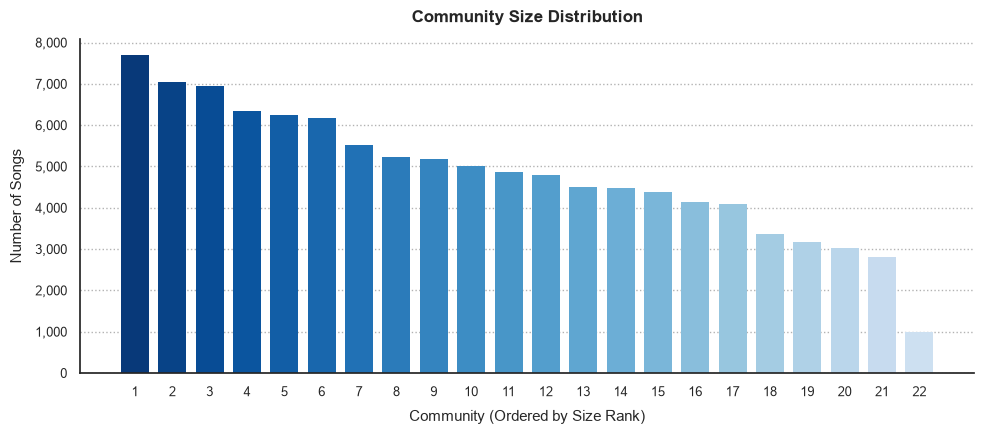

,community,size
0,4,7706
1,17,7056
2,0,6950
3,13,6353
4,18,6245
5,3,6169
6,14,5527
7,19,5235
8,1,5173
9,11,5002


In [35]:
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker
import numpy as np
import pandas as pd
import seaborn as sns

# 1. Prepare data
community_sizes = (
    pd.Series(community_labels, name="community")
    .value_counts()
    .sort_values(ascending=False)
    .reset_index()
)
community_sizes.columns = ["community", "size"]

# 2. Set publication style
sns.set_theme(style="white")

fig, ax = plt.subplots(figsize=(10, 4.5))

# Create a subtle continuous blue palette to emphasize size rank
colors = sns.color_palette("Blues_r", n_colors=len(community_sizes) + 5)[
    : len(community_sizes)
]

# 3. Plot bars with custom color, rounded edge line, and slight spacing
bars = ax.bar(
    range(1, len(community_sizes) + 1),
    community_sizes["size"],
    color=colors,
    edgecolor="none",
    width=0.75,
)

# 4. Refine Axes and Grid
ax.set_xlabel("Community (Ordered by Size Rank)", fontsize=10.5, labelpad=8)
ax.set_ylabel("Number of Songs", fontsize=10.5, labelpad=8)
ax.set_title(
    "Community Size Distribution", fontsize=12, fontweight="bold", pad=12
)

# Set precise X-ticks
ax.set_xticks(range(1, len(community_sizes) + 1))
ax.tick_params(axis="both", which="major", labelsize=9)

# Format Y-axis numbers with thousands commas (e.g., 7,000 instead of 7000)
ax.yaxis.set_major_formatter(ticker.StrMethodFormatter("{x:,.0f}"))

# Clean spines and add light horizontal gridlines behind bars
sns.despine(ax=ax)
ax.grid(axis="y", linestyle=":", alpha=0.6, color="gray")
ax.set_axisbelow(True)

plt.tight_layout()

# Save high-res vector PDF for LaTeX integration
plt.savefig("community_size_distribution.pdf", bbox_inches="tight")
plt.show()

display(community_sizes)

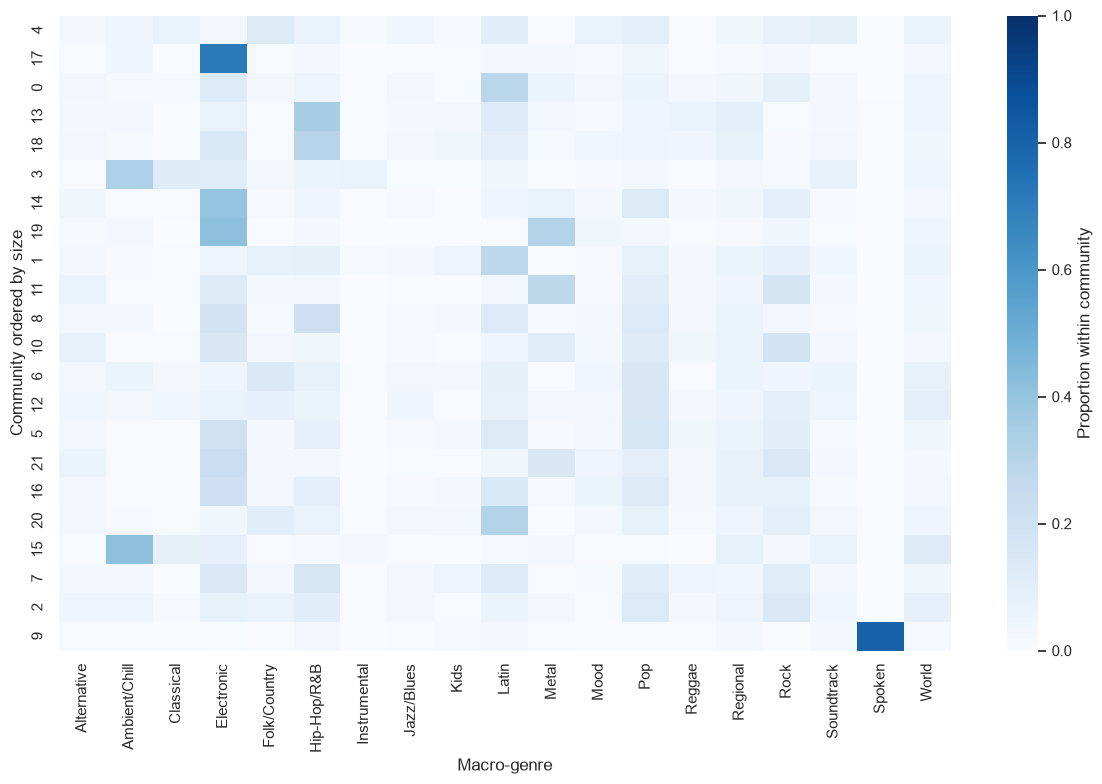

Genre,Alternative,Ambient/Chill,Classical,Electronic,Folk/Country,Hip-Hop/R&B,Instrumental,Jazz/Blues,Kids,Latin,Metal,Mood,Pop,Reggae,Regional,Rock,Soundtrack,Spoken,World
Community,,,,,,,,,,,,,,,,,,,
4,0.027,0.045,0.072,0.028,0.134,0.064,0.017,0.037,0.016,0.111,0.005,0.065,0.100,0.003,0.041,0.078,0.086,0.002,0.068
17,0.010,0.047,0.001,0.717,0.009,0.024,0.002,0.002,0.004,0.026,0.020,0.016,0.040,0.008,0.017,0.023,0.004,0.000,0.032
0,0.033,0.018,0.017,0.131,0.032,0.051,0.002,0.035,0.010,0.290,0.055,0.035,0.061,0.027,0.040,0.089,0.025,0.004,0.047
13,0.027,0.021,0.002,0.070,0.006,0.344,0.000,0.022,0.032,0.129,0.033,0.017,0.054,0.064,0.090,0.010,0.027,0.006,0.046
18,0.030,0.019,0.001,0.151,0.008,0.298,0.000,0.033,0.040,0.098,0.016,0.036,0.053,0.045,0.082,0.014,0.029,0.006,0.042
3,0.007,0.328,0.123,0.115,0.034,0.059,0.064,0.010,0.008,0.039,0.004,0.012,0.021,0.002,0.033,0.017,0.076,0.000,0.045
14,0.043,0.007,0.004,0.399,0.015,0.044,0.000,0.015,0.003,0.045,0.070,0.020,0.133,0.025,0.042,0.093,0.014,0.001,0.028
19,0.017,0.027,0.001,0.419,0.003,0.020,0.003,0.002,0.000,0.006,0.309,0.042,0.028,0.010,0.015,0.043,0.010,0.000,0.046
1,0.022,0.014,0.006,0.051,0.081,0.090,0.016,0.027,0.053,0.280,0.004,0.013,0.081,0.023,0.056,0.082,0.038,0.003,0.058


In [37]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Build community–genre contingency table
community_genre = pd.crosstab(
    pd.Series(community_labels, name="Community"),
    pd.Series(genre_labels, name="Genre")
)

# Normalize each community by row:
# values represent the genre composition within each community
community_genre_norm = community_genre.div(
    community_genre.sum(axis=1),
    axis=0
)

# Order communities by size
community_order = (
    community_genre.sum(axis=1)
    .sort_values(ascending=False)
    .index
)

community_genre_norm = community_genre_norm.loc[community_order]

plt.figure(figsize=(12, 8))

sns.heatmap(
    community_genre_norm,
    cmap="Blues",
    vmin=0,
    vmax=1,
    cbar_kws={"label": "Proportion within community"}
)

plt.xlabel("Macro-genre")
plt.ylabel("Community ordered by size")
plt.tight_layout()

plt.savefig(
    "community_genre_heatmap.pdf",
    bbox_inches="tight"
)

plt.show()

display(community_genre_norm.round(3))

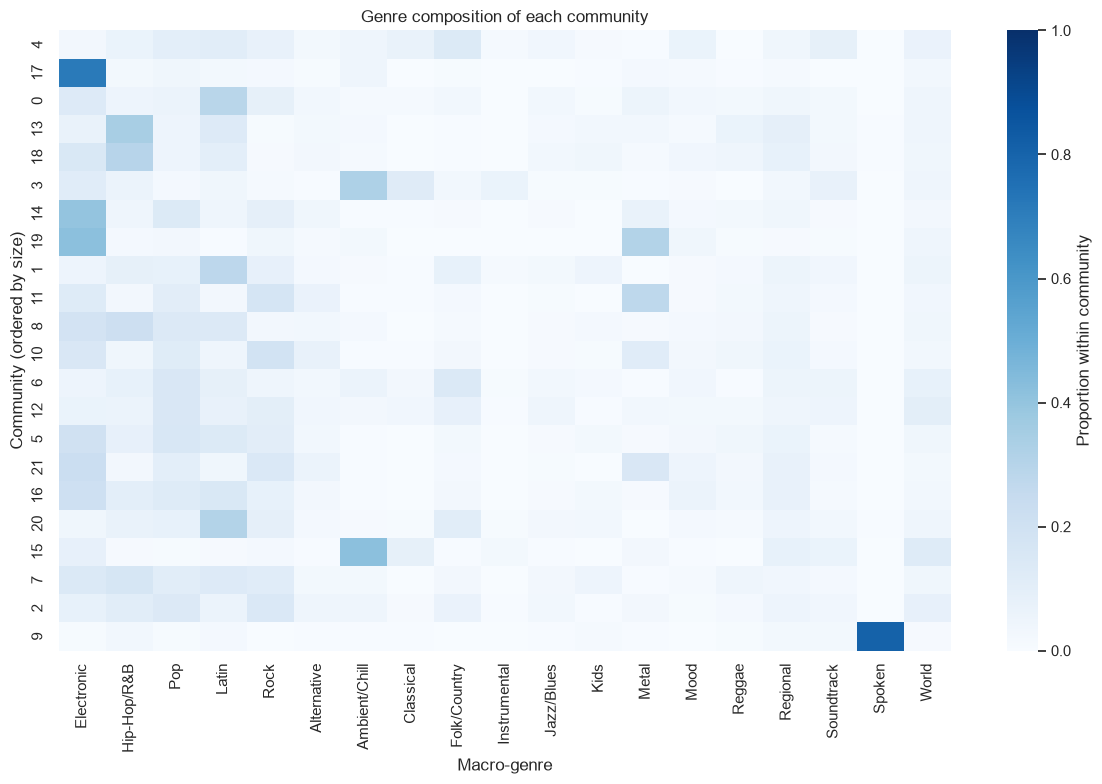

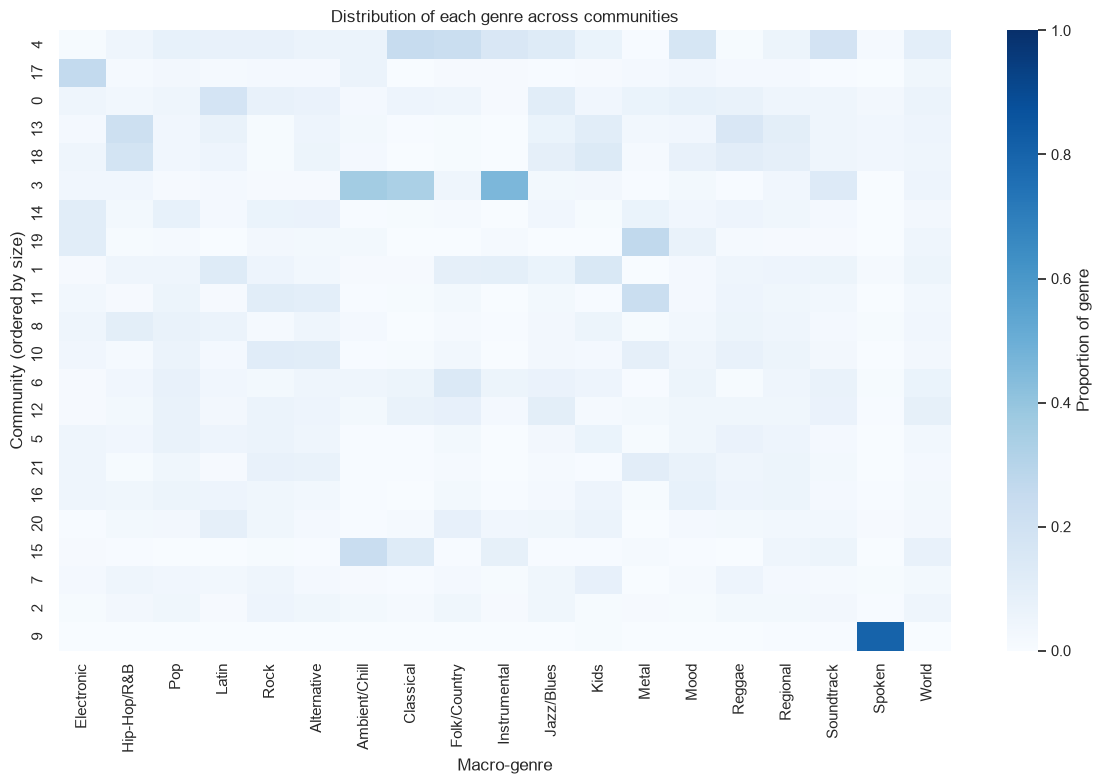

In [39]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# --------------------------------------------------------
# Community × Genre contingency table
# --------------------------------------------------------

community_genre = pd.crosstab(
    pd.Series(community_labels, name="Community"),
    pd.Series(genre_labels, name="Genre")
)

# --------------------------------------------------------
# Order communities by size
# --------------------------------------------------------

community_order = (
    community_genre.sum(axis=1)
    .sort_values(ascending=False)
    .index
)

# Put major genres first (edit if your names differ)
genre_order = [
    "Electronic",
    "Hip-Hop/R&B",
    "Pop",
    "Latin",
    "Rock",
]

remaining = [
    g for g in community_genre.columns
    if g not in genre_order
]

genre_order = genre_order + sorted(remaining)

community_genre = community_genre.loc[
    community_order,
    genre_order
]

# ========================================================
# FIGURE 1
# Community -> Genre composition (row normalized)
# ========================================================

community_to_genre = community_genre.div(
    community_genre.sum(axis=1),
    axis=0
)

plt.figure(figsize=(12,8))

sns.heatmap(
    community_to_genre,
    cmap="Blues",
    vmin=0,
    vmax=1,
    cbar_kws={"label":"Proportion within community"}
)

plt.xlabel("Macro-genre")
plt.ylabel("Community (ordered by size)")
plt.title("Genre composition of each community")

plt.tight_layout()
plt.savefig(
    "community_to_genre_heatmap.pdf",
    dpi=300,
    bbox_inches="tight"
)
plt.show()


# ========================================================
# FIGURE 2
# Genre -> Community distribution (column normalized)
# ========================================================

genre_to_community = community_genre.div(
    community_genre.sum(axis=0),
    axis=1
)

plt.figure(figsize=(12,8))

sns.heatmap(
    genre_to_community,
    cmap="Blues",
    vmin=0,
    vmax=1,
    cbar_kws={"label":"Proportion of genre"}
)

plt.xlabel("Macro-genre")
plt.ylabel("Community (ordered by size)")
plt.title("Distribution of each genre across communities")

plt.tight_layout()
plt.savefig(
    "genre_to_community_heatmap.pdf",
    dpi=300,
    bbox_inches="tight"
)
plt.show()

,danceability,energy,loudness,speechiness,acousticness,instrumentalness,liveness,valence,tempo
community,,,,,,,,,
4,-0.51,-1.17,-0.60,-0.42,1.40,-0.46,-0.25,-0.30,-0.95
17,0.65,0.46,0.00,-0.23,-0.73,1.77,-0.47,-0.10,0.24
0,-0.25,0.24,0.19,-0.15,0.03,-0.47,2.52,0.10,0.03
13,0.81,0.05,0.21,1.42,-0.20,-0.50,-0.15,0.43,-0.93
18,0.63,0.18,0.33,1.63,-0.25,-0.49,-0.21,0.27,1.00
3,-0.25,-1.39,-1.63,-0.26,1.35,2.07,-0.42,-0.49,-0.18
14,0.11,0.67,0.61,-0.34,-0.76,-0.47,-0.47,-0.45,0.24
19,-0.76,0.90,0.39,-0.06,-0.83,1.63,0.42,-0.84,0.37
1,0.72,0.01,0.26,-0.32,0.75,-0.50,-0.32,1.16,-0.46


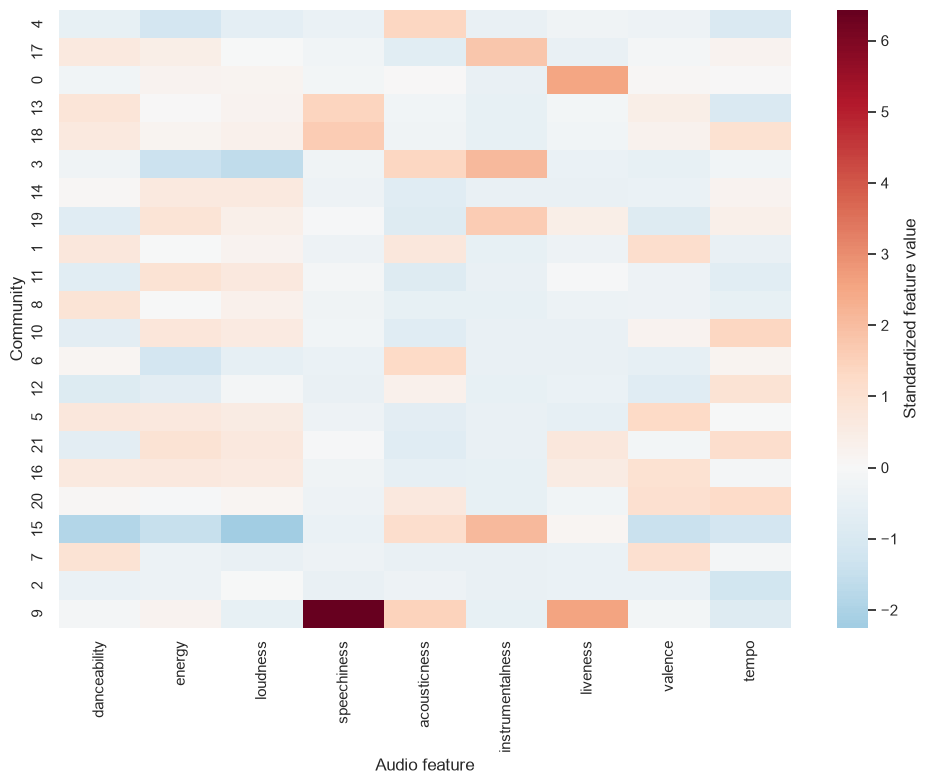

In [156]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

# -----------------------------------------
# Feature names
# -----------------------------------------

audio_features = [
    "danceability",
    "energy",
    "loudness",
    "speechiness",
    "acousticness",
    "instrumentalness",
    "liveness",
    "valence",
    "tempo",
]

# -----------------------------------------
# Build dataframe of standardized features
# -----------------------------------------

feature_df = pd.DataFrame(
    X_for_clustering,
    columns=audio_features
)

feature_df["community"] = community_labels
feature_df["genre"] = genre_labels

# -----------------------------------------
# Community centroids
# -----------------------------------------

community_centroids = (
    feature_df
    .groupby("community")[audio_features]
    .mean()
)

# Order by community size
community_order = (
    feature_df["community"]
    .value_counts()
    .index
)

community_centroids = community_centroids.loc[community_order]

display(community_centroids.round(2))

# -----------------------------------------
# Heatmap
# -----------------------------------------

plt.figure(figsize=(10,8))

sns.heatmap(
    community_centroids,
    cmap="RdBu_r",
    center=0,
    cbar_kws={"label":"Standardized feature value"}
)

plt.xlabel("Audio feature")
plt.ylabel("Community")

plt.tight_layout()

plt.savefig(
    "community_feature_heatmap.pdf",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

In [58]:
from sklearn.preprocessing import MinMaxScaler

feature_df = pd.DataFrame(
    X_for_clustering,
    columns=audio_features
)

feature_df["community"] = community_labels
feature_df["genre"] = genre_labels

# 1. Calculate average features per community
comm_features = feature_df.groupby('community')[continuous_features].mean()

# 2. Scale 0-1 for radar chart
scaler = MinMaxScaler()
comm_scaled = pd.DataFrame(scaler.fit_transform(comm_features), columns=comm_features.columns)


In [154]:
import numpy as np
import matplotlib.pyplot as plt

def plot_representative_communities(
    communities,
    titles=None,
    sample_size=20,
    radial_limits=(-3, 7)
):
    categories = list(comm_scaled.columns)
    N = len(categories)

    angles = np.linspace(0, 2*np.pi, N, endpoint=False).tolist()
    angles += angles[:1]

    if titles is None:
        titles = [f"Community {c}" for c in communities]

    fig, axes = plt.subplots(
        2, 2,
        figsize=(12, 12),
        subplot_kw=dict(polar=True)
    )

    axes = axes.flatten()

    for ax, comm_id, title in zip(axes, communities, titles):

        # Community centroid
        avg_values = comm_scaled.loc[comm_id].values.flatten().tolist()
        avg_values += avg_values[:1]

        # Sample songs
        comm_songs = feature_df[
            feature_df["community"] == comm_id
        ]

        sample = comm_songs[continuous_features].sample(
            min(sample_size, len(comm_songs)),
            random_state=42
        )

        sample_scaled = scaler.transform(sample)

        # Plot individual songs
        for row in sample_scaled:
            vals = row.tolist()
            vals += vals[:1]
            ax.plot(
                angles,
                vals,
                color="steelblue",
                alpha=0.12,
                linewidth=1
            )

        # Plot centroid
        ax.plot(
            angles,
            avg_values,
            color="crimson",
            linewidth=3,
            label="Community average"
        )

        ax.fill(
            angles,
            avg_values,
            color="crimson",
            alpha=0.15
        )

        ax.set_xticks(angles[:-1])
        ax.set_xticklabels(categories, fontsize=9)

        #ax.set_ylim(*radial_limits)

        ax.set_title(
            title,
            fontsize=13,
            pad=20
        )

        ax.grid(alpha=0.4)

    # Single legend
    handles, labels = axes[0].get_legend_handles_labels()

    fig.legend(
        handles,
        labels,
        loc="lower center",
        ncol=1,
        fontsize=11
    )

    plt.tight_layout(rect=[0, 0.05, 1, 1])

    plt.savefig(
        "community_radar_profiles.pdf",
        dpi=300,
        bbox_inches="tight"
    )

    plt.show()

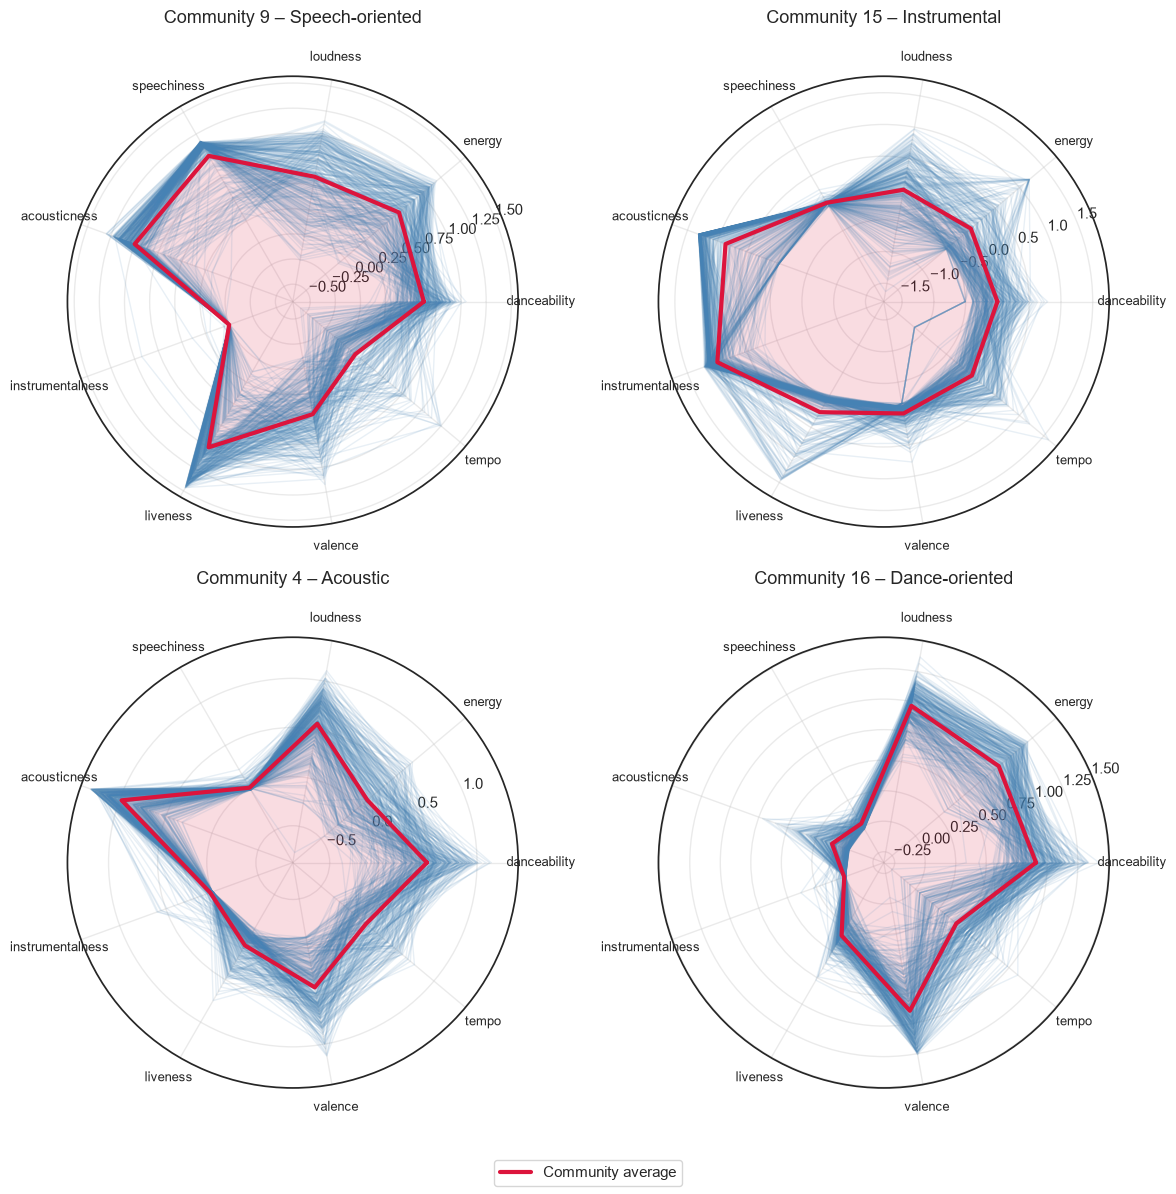

In [155]:
plot_representative_communities(
    communities=[9, 15, 4, 16],
    sample_size=300,
    titles=[
        "Community 9 – Speech-oriented",
        "Community 15 – Instrumental",
        "Community 4 – Acoustic",
        "Community 16 – Dance-oriented"
    ]
)

In [107]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.lines import Line2D


def plot_representative_communities(
    communities,
    titles=None,
    sample_size=30,
    random_state=42
):
    categories = list(continuous_features)
    n_features = len(categories)

    # Angles for the radar axes
    angles = np.linspace(
        0,
        2 * np.pi,
        n_features,
        endpoint=False
    ).tolist()

    closed_angles = angles + angles[:1]

    if titles is None:
        titles = [
            f"Community {community_id}"
            for community_id in communities
        ]

    # ----------------------------------------------------
    # Convert every standardized feature into its
    # percentile rank across the entire dataset
    # ----------------------------------------------------

    percentile_df = feature_df[categories].rank(
        pct=True,
        method="average"
    )

    percentile_df["community"] = feature_df["community"].values

    # Average percentile profile of each community
    community_profiles = (
        percentile_df
        .groupby("community")[categories]
        .mean()
    )

    # ----------------------------------------------------
    # Plot
    # ----------------------------------------------------

    fig, axes = plt.subplots(
        2,
        2,
        figsize=(13, 13),
        subplot_kw={"polar": True}
    )

    axes = axes.flatten()

    for ax, community_id, title in zip(
        axes,
        communities,
        titles
    ):
        # Community average percentile profile
        average_values = (
            community_profiles
            .loc[community_id, categories]
            .to_numpy()
            .tolist()
        )

        average_values += average_values[:1]

        # All songs belonging to the selected community
        community_songs = percentile_df[
            percentile_df["community"] == community_id
        ]

        sampled_songs = community_songs[categories].sample(
            n=min(sample_size, len(community_songs)),
            random_state=random_state
        )

        # Individual sampled songs
        for _, song in sampled_songs.iterrows():
            values = song.to_numpy().tolist()
            values += values[:1]

            ax.plot(
                closed_angles,
                values,
                color="steelblue",
                alpha=0.20,
                linewidth=0.8
            )

        # Community average
        ax.plot(
            closed_angles,
            average_values,
            color="crimson",
            linewidth=3,
            zorder=5
        )

        ax.fill(
            closed_angles,
            average_values,
            color="crimson",
            alpha=0.14,
            zorder=4
        )

        # Feature labels
        ax.set_thetagrids(
            np.degrees(angles),
            labels=categories,
            fontsize=9
        )

        # Same meaningful scale for every community
        ax.set_ylim(0, 1)

        ax.set_yticks([0.25, 0.50, 0.75, 1.00])
        ax.set_yticklabels(
            ["25th", "50th", "75th", "100th"],
            fontsize=8
        )

        ax.set_rlabel_position(15)

        community_size = len(community_songs)

        ax.set_title(
            f"{title}\n($n={community_size:,}$)",
            fontsize=13,
            pad=28
        )

        ax.grid(alpha=0.35)
        ax.spines["polar"].set_alpha(0.4)

    # Remove unused panels when fewer than four are supplied
    for ax in axes[len(communities):]:
        ax.remove()

    # Common legend
    legend_elements = [
        Line2D(
            [0],
            [0],
            color="steelblue",
            alpha=0.5,
            linewidth=1,
            label="Sampled songs"
        ),
        Line2D(
            [0],
            [0],
            color="crimson",
            linewidth=3,
            label="Community average"
        )
    ]

    fig.legend(
        handles=legend_elements,
        loc="lower center",
        ncol=2,
        fontsize=11
    )

    plt.tight_layout(rect=[0, 0.06, 1, 1])

    plt.savefig(
        "community_radar_profiles.pdf",
        dpi=300,
        bbox_inches="tight"
    )

    plt.show()

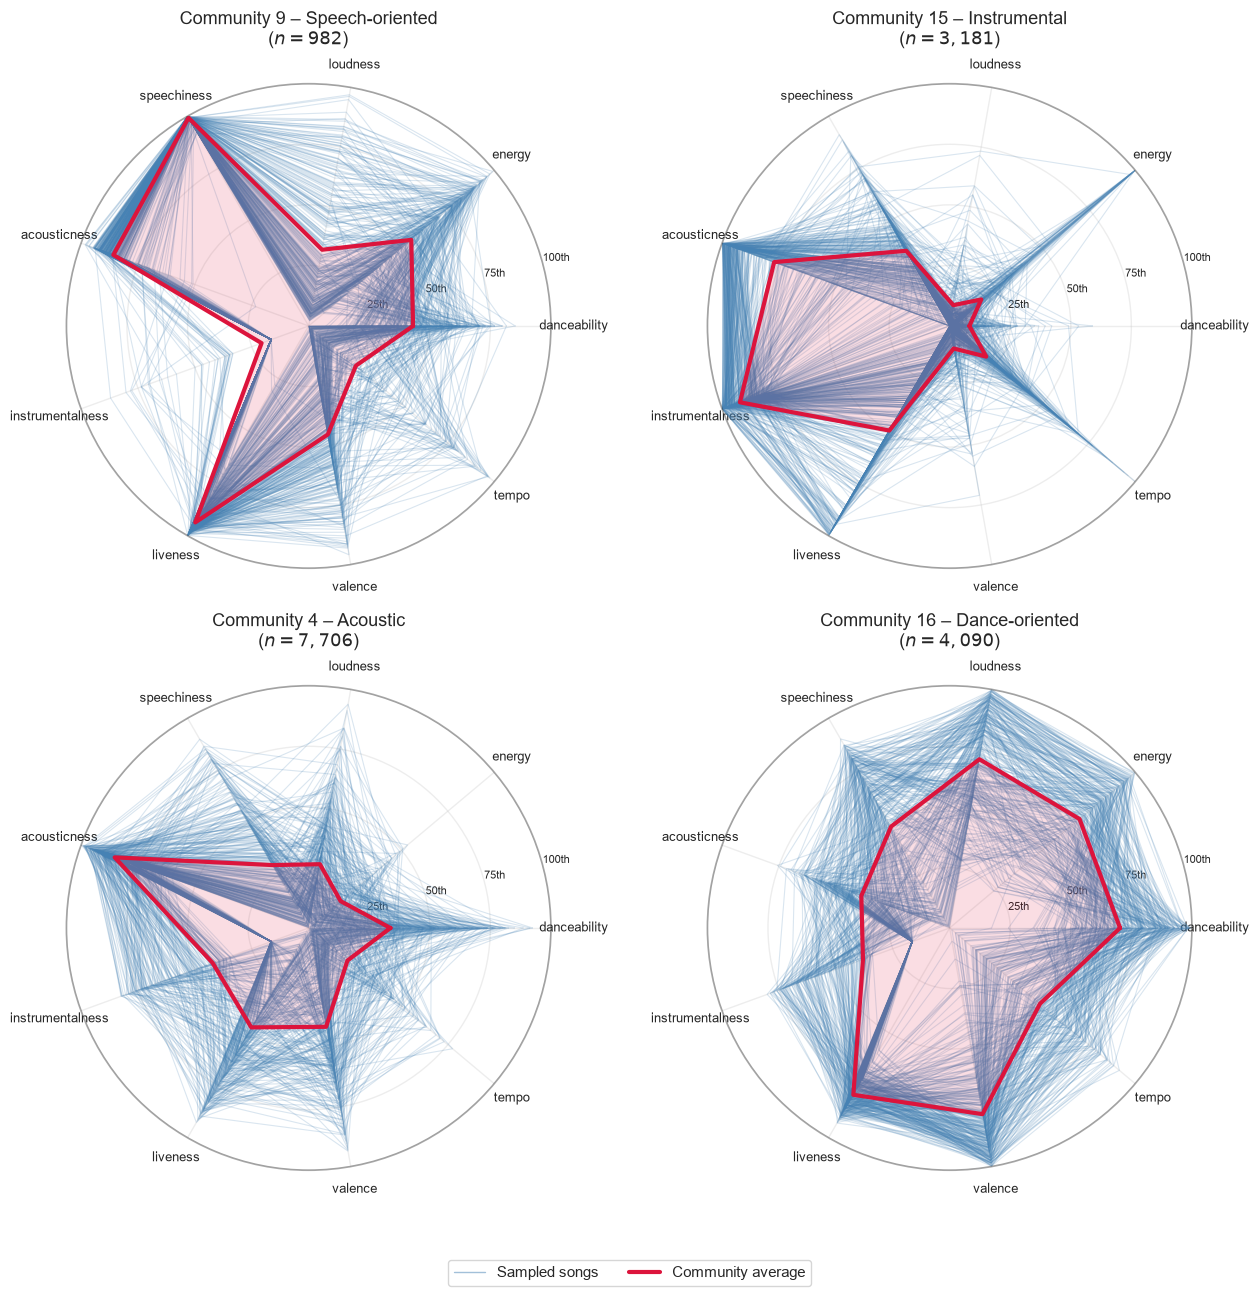

In [131]:
plot_representative_communities(
    communities=[9, 15, 4, 16],
    titles=[
        "Community 9 – Speech-oriented",
        "Community 15 – Instrumental",
        "Community 4 – Acoustic",
        "Community 16 – Dance-oriented"
    ],
    sample_size=300
)

In [134]:
from scipy.spatial.distance import cosine

feature_df['kmeans_cluster'] = kmeans_labels

# Calculate distance of every song to its community centroid
def calculate_fidelity(row, column='community'):
    comm_id = int(row[column])
    centroid = comm_features.loc[comm_id].values
    song_vec = row[continuous_features].values
    # Fidelity is 1 - Cosine Distance
    return 1 - cosine(song_vec, centroid)

feature_df['fidelity'] = feature_df.apply(calculate_fidelity, axis=1)
feature_df['kmeans_fidelity'] = feature_df.apply(lambda row: calculate_fidelity(row, column='kmeans_cluster'), axis=1)

# Average Fidelity per Community
fidelity_report = feature_df.groupby('community')['fidelity'].mean()
print("Average Acoustic Fidelity per Community (Higher = More Consistent):")
print(fidelity_report.sort_values(ascending=False))


# Average Fidelity per KMeans Cluster
kmeans_fidelity_report = feature_df.groupby('kmeans_cluster')['kmeans_fidelity'].mean()
print("Average KMeans Fidelity per Cluster (Higher = More Consistent):")
print(kmeans_fidelity_report.sort_values(ascending=False))




Average Acoustic Fidelity per Community (Higher = More Consistent):
community
9     0.949830
5     0.885028
15    0.853749
10    0.824248
21    0.822397
16    0.803871
14    0.795753
4     0.794878
11    0.792751
6     0.784486
7     0.776750
3     0.776004
1     0.767656
20    0.761380
12    0.758227
17    0.754763
0     0.752141
19    0.747025
2     0.739328
18    0.730278
13    0.728641
8     0.724007
Name: fidelity, dtype: float64
Average KMeans Fidelity per Cluster (Higher = More Consistent):
kmeans_cluster
8     0.570714
3     0.507573
18    0.507238
6     0.452705
16    0.433175
10    0.417212
9     0.245361
14    0.158012
2     0.007635
0    -0.074436
15   -0.159412
1    -0.270976
7    -0.272473
5    -0.274463
13   -0.339519
17   -0.359076
11   -0.409024
4    -0.425134
12   -0.426960
Name: kmeans_fidelity, dtype: float64


In [136]:
import numpy as np
import pandas as pd
from scipy.spatial.distance import cosine, euclidean

# ---------------------------------------------------------
# 1. Attach K-Means labels
# ---------------------------------------------------------

feature_df = feature_df.copy()
feature_df["kmeans_cluster"] = kmeans_labels

# Ensure acoustic features are numeric
feature_df[continuous_features] = (
    feature_df[continuous_features]
    .apply(pd.to_numeric, errors="coerce")
)

# Remove rows with missing feature values or missing partition labels
analysis_df = feature_df.dropna(
    subset=continuous_features + ["community", "kmeans_cluster"]
).copy()

analysis_df["community"] = analysis_df["community"].astype(int)
analysis_df["kmeans_cluster"] = analysis_df["kmeans_cluster"].astype(int)


# ---------------------------------------------------------
# 2. Compute the correct centroids for each partition
# ---------------------------------------------------------

louvain_centroids = (
    analysis_df
    .groupby("community")[continuous_features]
    .mean()
)

kmeans_centroids = (
    analysis_df
    .groupby("kmeans_cluster")[continuous_features]
    .mean()
)


# ---------------------------------------------------------
# 3. Generic function for distance to the correct centroid
# ---------------------------------------------------------

def distance_to_centroid(
    row,
    label_column,
    centroid_table,
    metric="cosine"
):
    """
    Compute the distance or similarity between one song and the
    centroid of its assigned group.

    Parameters
    ----------
    row : pd.Series
        One row of analysis_df.

    label_column : str
        Column containing the group label.

    centroid_table : pd.DataFrame
        Table indexed by group labels containing group centroids.

    metric : str
        'cosine_similarity' or 'euclidean_distance'.
    """

    group_id = int(row[label_column])

    song_vector = row[continuous_features].to_numpy(dtype=float)
    centroid_vector = centroid_table.loc[group_id].to_numpy(dtype=float)

    if metric == "cosine_similarity":
        # scipy cosine returns cosine distance,
        # so similarity = 1 - cosine distance
        return 1 - cosine(song_vector, centroid_vector)

    if metric == "euclidean_distance":
        return euclidean(song_vector, centroid_vector)

    raise ValueError(
        "metric must be 'cosine_similarity' or "
        "'euclidean_distance'"
    )


# ---------------------------------------------------------
# 4. Compute centroid-based measures
# ---------------------------------------------------------

analysis_df["louvain_cosine_similarity"] = analysis_df.apply(
    distance_to_centroid,
    axis=1,
    label_column="community",
    centroid_table=louvain_centroids,
    metric="cosine_similarity"
)

analysis_df["kmeans_cosine_similarity"] = analysis_df.apply(
    distance_to_centroid,
    axis=1,
    label_column="kmeans_cluster",
    centroid_table=kmeans_centroids,
    metric="cosine_similarity"
)

analysis_df["louvain_euclidean_distance"] = analysis_df.apply(
    distance_to_centroid,
    axis=1,
    label_column="community",
    centroid_table=louvain_centroids,
    metric="euclidean_distance"
)

analysis_df["kmeans_euclidean_distance"] = analysis_df.apply(
    distance_to_centroid,
    axis=1,
    label_column="kmeans_cluster",
    centroid_table=kmeans_centroids,
    metric="euclidean_distance"
)


# ---------------------------------------------------------
# 5. Per-group reports
# ---------------------------------------------------------

louvain_report = (
    analysis_df
    .groupby("community")
    .agg(
        size=("community", "size"),
        mean_cosine_similarity=(
            "louvain_cosine_similarity", "mean"
        ),
        median_cosine_similarity=(
            "louvain_cosine_similarity", "median"
        ),
        mean_euclidean_distance=(
            "louvain_euclidean_distance", "mean"
        ),
        median_euclidean_distance=(
            "louvain_euclidean_distance", "median"
        )
    )
    .sort_values("mean_cosine_similarity", ascending=False)
)

kmeans_report = (
    analysis_df
    .groupby("kmeans_cluster")
    .agg(
        size=("kmeans_cluster", "size"),
        mean_cosine_similarity=(
            "kmeans_cosine_similarity", "mean"
        ),
        median_cosine_similarity=(
            "kmeans_cosine_similarity", "median"
        ),
        mean_euclidean_distance=(
            "kmeans_euclidean_distance", "mean"
        ),
        median_euclidean_distance=(
            "kmeans_euclidean_distance", "median"
        )
    )
    .sort_values("mean_cosine_similarity", ascending=False)
)

print("\nLouvain community centroid report")
display(louvain_report)

print("\nK-Means cluster centroid report")
display(kmeans_report)


# ---------------------------------------------------------
# 6. Overall weighted comparison
# ---------------------------------------------------------

centroid_comparison = pd.DataFrame({
    "Partition": ["Louvain", "K-Means"],

    "Mean cosine similarity": [
        analysis_df["louvain_cosine_similarity"].mean(),
        analysis_df["kmeans_cosine_similarity"].mean()
    ],

    "Median cosine similarity": [
        analysis_df["louvain_cosine_similarity"].median(),
        analysis_df["kmeans_cosine_similarity"].median()
    ],

    "Mean Euclidean distance": [
        analysis_df["louvain_euclidean_distance"].mean(),
        analysis_df["kmeans_euclidean_distance"].mean()
    ],

    "Median Euclidean distance": [
        analysis_df["louvain_euclidean_distance"].median(),
        analysis_df["kmeans_euclidean_distance"].median()
    ]
})

print("\nOverall centroid comparison")
display(centroid_comparison.round(4))


Louvain community centroid report


,size,mean_cosine_similarity,median_cosine_similarity,mean_euclidean_distance,median_euclidean_distance
community,,,,,
9,982,0.949830,0.970834,2.501443,2.185526
5,4374,0.885028,0.902931,1.053386,1.025294
15,3181,0.853749,0.910153,2.711003,2.474328
10,4789,0.824248,0.846877,1.431331,1.383298
21,4132,0.822397,0.841211,1.486317,1.412194
16,4090,0.803871,0.839643,1.286332,1.241974
14,5527,0.795753,0.820264,1.119185,1.096903
4,7706,0.794878,0.832371,1.772412,1.696816
11,5002,0.792751,0.810118,1.411154,1.361289



K-Means cluster centroid report


,size,mean_cosine_similarity,median_cosine_similarity,mean_euclidean_distance,median_euclidean_distance
kmeans_cluster,,,,,
7,915,0.957007,0.972498,2.240934,2.024177
11,3650,0.932389,0.950921,2.111016,1.927365
3,6160,0.863743,0.881001,1.631360,1.582140
6,3588,0.842169,0.857367,2.082070,1.999058
14,4612,0.840394,0.864751,1.550137,1.471755
5,3321,0.833946,0.849675,1.926508,1.838941
9,1216,0.823926,0.832038,2.846292,2.618317
13,7773,0.822806,0.836954,1.500947,1.441440
15,5501,0.821334,0.834107,2.088624,2.046847



Overall centroid comparison


,Partition,Mean cosine similarity,Median cosine similarity,Mean Euclidean distance,Median Euclidean distance
0,Louvain,0.7782,0.8113,1.7348,1.6067
1,K-Means,0.7885,0.8144,1.6246,1.5295


In [135]:
from scipy.spatial.distance import cosine, euclidean

feature_df['kmeans_cluster'] = kmeans_labels

# Calculate distance of every song to its community centroid
def calculate_fidelity(row, column='community', distance_metric='cosine'):
    comm_id = int(row[column])
    centroid = comm_features.loc[comm_id].values
    song_vec = row[continuous_features].values
    # Fidelity is 1 - Distance
    if distance_metric == 'cosine':
        return 1 - cosine(song_vec, centroid)
    else:
        return 1 - euclidean(song_vec, centroid)

feature_df['fidelity_euclidean'] = feature_df.apply(calculate_fidelity, axis=1, distance_metric='euclidean')
feature_df['fidelity_cosine'] = feature_df.apply(calculate_fidelity, axis=1, distance_metric='cosine')
feature_df['kmeans_fidelity_euclidean'] = feature_df.apply(lambda row: calculate_fidelity(row, column='kmeans_cluster', distance_metric='euclidean'), axis=1)
feature_df['kmeans_fidelity_cosine'] = feature_df.apply(lambda row: calculate_fidelity(row, column='kmeans_cluster', distance_metric='cosine'), axis=1)

# Average Fidelity per Community
fidelity_report = feature_df.groupby('community')['fidelity_cosine'].mean()
print("Average Acoustic Fidelity per Community (Higher = More Consistent):")
print(fidelity_report.sort_values(ascending=False))


# Average Fidelity per KMeans Cluster
kmeans_fidelity_report = feature_df.groupby('kmeans_cluster')['kmeans_fidelity_cosine'].mean()
print("Average KMeans Fidelity per Cluster (Higher = More Consistent):")
print(kmeans_fidelity_report.sort_values(ascending=False))

# Average Fidelity per Community
fidelity_report = feature_df.groupby('community')['fidelity_euclidean'].mean()
print("Average Acoustic Fidelity per Community (Higher = More Consistent):")
print(fidelity_report.sort_values(ascending=False))


# Average Fidelity per KMeans Cluster
kmeans_fidelity_report = feature_df.groupby('kmeans_cluster')['kmeans_fidelity_euclidean'].mean()
print("Average KMeans Fidelity per Cluster (Higher = More Consistent):")
print(kmeans_fidelity_report.sort_values(ascending=False))




Average Acoustic Fidelity per Community (Higher = More Consistent):
community
9     0.949830
5     0.885028
15    0.853749
10    0.824248
21    0.822397
16    0.803871
14    0.795753
4     0.794878
11    0.792751
6     0.784486
7     0.776750
3     0.776004
1     0.767656
20    0.761380
12    0.758227
17    0.754763
0     0.752141
19    0.747025
2     0.739328
18    0.730278
13    0.728641
8     0.724007
Name: fidelity_cosine, dtype: float64
Average KMeans Fidelity per Cluster (Higher = More Consistent):
kmeans_cluster
8     0.570714
3     0.507573
18    0.507238
6     0.452705
16    0.433175
10    0.417212
9     0.245361
14    0.158012
2     0.007635
0    -0.074436
15   -0.159412
1    -0.270976
7    -0.272473
5    -0.274463
13   -0.339519
17   -0.359076
11   -0.409024
4    -0.425134
12   -0.426960
Name: kmeans_fidelity_cosine, dtype: float64
Average Acoustic Fidelity per Community (Higher = More Consistent):
community
5    -0.053386
14   -0.119185
16   -0.286332
8    -0.330356
7    -0

In [137]:
import numpy as np
import pandas as pd
from scipy.spatial.distance import cosine, euclidean

analysis_df = feature_df.dropna(
    subset=continuous_features + ["community"]
).copy()

analysis_df["community"] = analysis_df["community"].astype(int)

# Community centroids
community_centroids = (
    analysis_df
    .groupby("community")[continuous_features]
    .mean()
)


def community_centroid_metrics(row):
    community_id = row["community"]

    song_vector = row[continuous_features].to_numpy(dtype=float)
    centroid_vector = (
        community_centroids
        .loc[community_id]
        .to_numpy(dtype=float)
    )

    return pd.Series({
        "centroid_cosine_similarity":
            1 - cosine(song_vector, centroid_vector),

        "centroid_euclidean_distance":
            euclidean(song_vector, centroid_vector)
    })


metrics = analysis_df.apply(
    community_centroid_metrics,
    axis=1
)

analysis_df = pd.concat(
    [analysis_df, metrics],
    axis=1
)

In [157]:
community_coherence_report = (
    analysis_df
    .groupby("community")
    .agg(
        size=("community", "size"),

        cosine_mean=(
            "centroid_cosine_similarity", "mean"
        ),
        cosine_median=(
            "centroid_cosine_similarity", "median"
        ),
        cosine_std=(
            "centroid_cosine_similarity", "std"
        ),
        cosine_q1=(
            "centroid_cosine_similarity",
            lambda x: x.quantile(0.25)
        ),
        cosine_q3=(
            "centroid_cosine_similarity",
            lambda x: x.quantile(0.75)
        ),

        euclidean_mean=(
            "centroid_euclidean_distance", "mean"
        ),
        euclidean_median=(
            "centroid_euclidean_distance", "median"
        )
    )
    .sort_values("cosine_mean", ascending=False)
)

display(community_coherence_report.round(3))

,size,cosine_mean,cosine_median,cosine_std,cosine_q1,cosine_q3,euclidean_mean,euclidean_median
community,,,,,,,,
9,982,0.950,0.971,0.057,0.940,0.983,2.501,2.186
5,4374,0.885,0.903,0.075,0.849,0.939,1.053,1.025
15,3181,0.854,0.910,0.132,0.780,0.958,2.711,2.474
10,4789,0.824,0.847,0.116,0.764,0.910,1.431,1.383
21,4132,0.822,0.841,0.106,0.769,0.899,1.486,1.412
16,4090,0.804,0.840,0.142,0.750,0.901,1.286,1.242
14,5527,0.796,0.820,0.128,0.739,0.886,1.119,1.097
4,7706,0.795,0.832,0.146,0.720,0.904,1.772,1.697
11,5002,0.793,0.810,0.110,0.726,0.878,1.411,1.361


In [158]:
overall_coherence = pd.Series({
    "Number of communities":
        analysis_df["community"].nunique(),

    "Mean cosine similarity":
        analysis_df["centroid_cosine_similarity"].mean(),

    "Median cosine similarity":
        analysis_df["centroid_cosine_similarity"].median(),

    "Standard deviation":
        analysis_df["centroid_cosine_similarity"].std(),

    "First quartile":
        analysis_df["centroid_cosine_similarity"].quantile(0.25),

    "Third quartile":
        analysis_df["centroid_cosine_similarity"].quantile(0.75),

    "Mean Euclidean distance":
        analysis_df["centroid_euclidean_distance"].mean(),

    "Median Euclidean distance":
        analysis_df["centroid_euclidean_distance"].median()
})

display(overall_coherence.round(3))

Number of communities        22.000
Mean cosine similarity        0.778
Median cosine similarity      0.811
Standard deviation            0.151
First quartile                0.701
Third quartile                0.891
Mean Euclidean distance       1.735
Median Euclidean distance     1.607
dtype: float64

In [159]:
import numpy as np
import pandas as pd
import networkx as nx

from scipy.spatial.distance import cosine, euclidean
from scipy.stats import spearmanr


def compute_within_community_pagerank(
    G,
    feature_df,
    feature_columns,
    community_col="community",
    title_col="track_name",
    artist_col="artists",
    weight="weight",
    alpha=0.85
):
    """
    Compute PageRank independently within every Louvain community and
    compare each song with the centroid of its assigned community.

    Assumptions
    -----------
    - G nodes correspond to feature_df.index.
    - feature_columns contain the standardized features used for the graph.
    - community_col contains the Louvain community assignment.
    """

    missing_nodes = set(feature_df.index) - set(G.nodes)

    if missing_nodes:
        print(
            f"Warning: {len(missing_nodes)} dataframe rows are not present "
            "in the graph and will be ignored."
        )

    results = []

    for community_id, community_rows in feature_df.groupby(community_col):

        # Keep only nodes actually present in G
        community_nodes = [
            node for node in community_rows.index
            if node in G
        ]

        if not community_nodes:
            continue

        community_subgraph = G.subgraph(community_nodes).copy()

        # Centroid computed in the same standardized feature space
        centroid = (
            feature_df.loc[community_nodes, feature_columns]
            .mean(axis=0)
            .to_numpy()
        )

        # PageRank computed only inside this community
        pagerank = nx.pagerank(
            community_subgraph,
            alpha=alpha,
            weight=weight
        )

        # Percentile rank makes PageRank comparable within communities
        pagerank_percentiles = (
            pd.Series(pagerank)
            .rank(method="average", pct=True)
            .to_dict()
        )

        for node in community_nodes:

            song_vector = (
                feature_df.loc[node, feature_columns]
                .to_numpy(dtype=float)
            )

            # Protect cosine distance from zero-vector issues
            if (
                np.linalg.norm(song_vector) == 0
                or np.linalg.norm(centroid) == 0
            ):
                cosine_similarity = np.nan
            else:
                cosine_similarity = 1 - cosine(
                    song_vector,
                    centroid
                )

            row = {
                "node": node,
                "community": community_id,
                "community_size": len(community_nodes),
                "pagerank": pagerank[node],
                "pagerank_percentile": pagerank_percentiles[node],
                "cosine_to_centroid": cosine_similarity,
                "euclidean_to_centroid": euclidean(
                    song_vector,
                    centroid
                )
            }

            if title_col in feature_df.columns:
                row["track_name"] = feature_df.loc[node, title_col]

            if artist_col in feature_df.columns:
                row["artist"] = feature_df.loc[node, artist_col]

            if "macro_genre" in feature_df.columns:
                row["macro_genre"] = feature_df.loc[
                    node, "macro_genre"
                ]

            if "subgenre" in feature_df.columns:
                row["subgenre"] = feature_df.loc[node, "subgenre"]

            results.append(row)

    return pd.DataFrame(results)


pagerank_results = compute_within_community_pagerank(
    G=G,
    feature_df=feature_df,
    feature_columns=continuous_features,
    community_col="community",
    title_col="track_name",   # change if necessary
    artist_col="artists",     # change if necessary
    weight=None
)

pagerank_results.head()

,node,community,community_size,pagerank,pagerank_percentile,cosine_to_centroid,euclidean_to_centroid
0,25,0,6950,0.000151,0.618705,0.913769,1.655701
1,31,0,6950,0.000166,0.771799,0.963017,1.818266
2,55,0,6950,0.000170,0.805468,0.837239,2.674863
3,65,0,6950,0.000126,0.291079,0.848733,1.828092
4,84,0,6950,0.000148,0.581583,0.645400,2.064195


In [160]:
top_n = 3

top_pagerank_songs = (
    pagerank_results
    .sort_values(
        ["community", "pagerank"],
        ascending=[True, False]
    )
    .groupby("community", group_keys=False)
    .head(top_n)
    .reset_index(drop=True)
)

display_columns = [
    "community",
    "community_size",
    "track_name",
    "artist",
    "pagerank",
    "pagerank_percentile",
    "cosine_to_centroid",
    "euclidean_to_centroid"
]

# Retain only columns that actually exist
display_columns = [
    column for column in display_columns
    if column in top_pagerank_songs.columns
]

top_pagerank_songs[display_columns]

,community,community_size,pagerank,pagerank_percentile,cosine_to_centroid,euclidean_to_centroid
0,0,6950,0.000298,1.000000,0.854784,1.673659
1,0,6950,0.000284,0.999856,0.609021,3.954725
2,0,6950,0.000281,0.999712,0.896188,1.817119
3,1,5173,0.000410,1.000000,0.716458,1.457492
4,1,5173,0.000388,0.999807,0.839584,1.511383
...,...,...,...,...,...,...
61,20,3355,0.000560,0.999702,0.860181,1.749573
62,20,3355,0.000550,0.999404,0.870452,1.829868
63,21,4132,0.000470,1.000000,0.593763,2.104500
64,21,4132,0.000467,0.999758,0.782107,1.933960


In [161]:
top_nodes = set(top_pagerank_songs["node"])

pagerank_results["is_top_pagerank"] = (
    pagerank_results["node"].isin(top_nodes)
)

comparison = (
    pagerank_results
    .groupby("is_top_pagerank")
    .agg(
        number_of_songs=("node", "size"),
        mean_cosine_similarity=("cosine_to_centroid", "mean"),
        median_cosine_similarity=("cosine_to_centroid", "median"),
        std_cosine_similarity=("cosine_to_centroid", "std"),
        mean_euclidean_distance=("euclidean_to_centroid", "mean"),
        median_euclidean_distance=("euclidean_to_centroid", "median")
    )
    .rename(
        index={
            False: "Other community songs",
            True: "Top PageRank songs"
        }
    )
)

comparison

,number_of_songs,mean_cosine_similarity,median_cosine_similarity,std_cosine_similarity,mean_euclidean_distance,median_euclidean_distance
is_top_pagerank,,,,,,
Other community songs,105942,0.778172,0.811343,0.151010,1.734794,1.606606
Top PageRank songs,66,0.755382,0.806233,0.181417,1.793218,1.751858


In [162]:
def safe_spearman(x, y):
    valid = pd.DataFrame({"x": x, "y": y}).dropna()

    if len(valid) < 3:
        return np.nan, np.nan

    if valid["x"].nunique() < 2 or valid["y"].nunique() < 2:
        return np.nan, np.nan

    return spearmanr(valid["x"], valid["y"])


correlation_rows = []

for community_id, group in pagerank_results.groupby("community"):

    cosine_rho, cosine_p = safe_spearman(
        group["pagerank"],
        group["cosine_to_centroid"]
    )

    distance_rho, distance_p = safe_spearman(
        group["pagerank"],
        group["euclidean_to_centroid"]
    )

    correlation_rows.append({
        "community": community_id,
        "community_size": len(group),
        "rho_pagerank_cosine": cosine_rho,
        "p_pagerank_cosine": cosine_p,
        "rho_pagerank_euclidean": distance_rho,
        "p_pagerank_euclidean": distance_p
    })

community_correlations = pd.DataFrame(correlation_rows)

community_correlations.round(4)

,community,community_size,rho_pagerank_cosine,p_pagerank_cosine,rho_pagerank_euclidean,p_pagerank_euclidean
0,0,6950,0.2339,0.0,0.0082,0.4965
1,1,5173,0.2706,0.0,-0.1181,0.0000
2,2,2801,0.2561,0.0,-0.0917,0.0000
3,3,6169,0.1402,0.0,-0.0540,0.0000
4,4,7706,0.1982,0.0,-0.0748,0.0000
5,5,4374,0.3366,0.0,-0.2207,0.0000
6,6,4501,0.1978,0.0,-0.1004,0.0000
7,7,3028,0.2917,0.0,-0.1310,0.0000
8,8,4875,0.2418,0.0,-0.1036,0.0000
9,9,982,0.3158,0.0,-0.3018,0.0000


In [163]:
overall_cosine = spearmanr(
    pagerank_results["pagerank_percentile"],
    pagerank_results["cosine_to_centroid"],
    nan_policy="omit"
)

overall_euclidean = spearmanr(
    pagerank_results["pagerank_percentile"],
    pagerank_results["euclidean_to_centroid"],
    nan_policy="omit"
)

print(
    "PageRank percentile vs cosine similarity:\n"
    f"rho = {overall_cosine.statistic:.4f}, "
    f"p = {overall_cosine.pvalue:.4g}"
)

print(
    "\nPageRank percentile vs Euclidean distance:\n"
    f"rho = {overall_euclidean.statistic:.4f}, "
    f"p = {overall_euclidean.pvalue:.4g}"
)

PageRank percentile vs cosine similarity:
rho = 0.2180, p = 0

PageRank percentile vs Euclidean distance:
rho = -0.0685, p = 1.473e-110


In [164]:
community_summary = (
    pagerank_results
    .groupby("community")
    .agg(
        community_size=("node", "size"),
        community_mean_cosine=("cosine_to_centroid", "mean"),
        community_median_cosine=("cosine_to_centroid", "median"),
        community_mean_euclidean=("euclidean_to_centroid", "mean")
    )
    .reset_index()
)

top_one_per_community = (
    pagerank_results
    .sort_values(
        ["community", "pagerank"],
        ascending=[True, False]
    )
    .groupby("community", as_index=False)
    .first()
)

pagerank_community_table = top_one_per_community.merge(
    community_summary,
    on="community",
    how="left",
    suffixes=("_top_song", "_community")
)

pagerank_community_table["cosine_difference"] = (
    pagerank_community_table["cosine_to_centroid"]
    - pagerank_community_table["community_mean_cosine"]
)

pagerank_community_table["euclidean_difference"] = (
    pagerank_community_table["euclidean_to_centroid"]
    - pagerank_community_table["community_mean_euclidean"]
)

table_columns = [
    "community",
    "community_size_community",
    "track_name",
    "artist",
    "pagerank",
    "cosine_to_centroid",
    "community_mean_cosine",
    "cosine_difference",
    "euclidean_to_centroid",
    "community_mean_euclidean",
    "euclidean_difference"
]

table_columns = [
    column for column in table_columns
    if column in pagerank_community_table.columns
]

pagerank_community_table[table_columns].round(4)

,community,community_size_community,pagerank,cosine_to_centroid,community_mean_cosine,cosine_difference,euclidean_to_centroid,community_mean_euclidean,euclidean_difference
0,0,6950,0.0003,0.8548,0.7521,0.1026,1.6737,2.2560,-0.5823
1,1,5173,0.0004,0.7165,0.7677,-0.0512,1.4575,1.4809,-0.0235
2,2,2801,0.0007,0.7254,0.7393,-0.0139,1.2563,1.4926,-0.2363
3,3,6169,0.0003,0.8032,0.7760,0.0272,2.0163,2.6158,-0.5995
4,4,7706,0.0003,0.6051,0.7949,-0.1898,2.4678,1.7724,0.6954
5,5,4374,0.0005,0.9671,0.8850,0.0820,0.6762,1.0534,-0.3772
6,6,4501,0.0005,0.4137,0.7845,-0.3708,2.0144,1.5888,0.4257
7,7,3028,0.0007,0.7049,0.7767,-0.0719,1.4472,1.3984,0.0488
8,8,4875,0.0004,0.8144,0.7240,0.0904,1.1847,1.3304,-0.1456
9,9,982,0.0017,0.9965,0.9498,0.0467,1.1817,2.5014,-1.3197


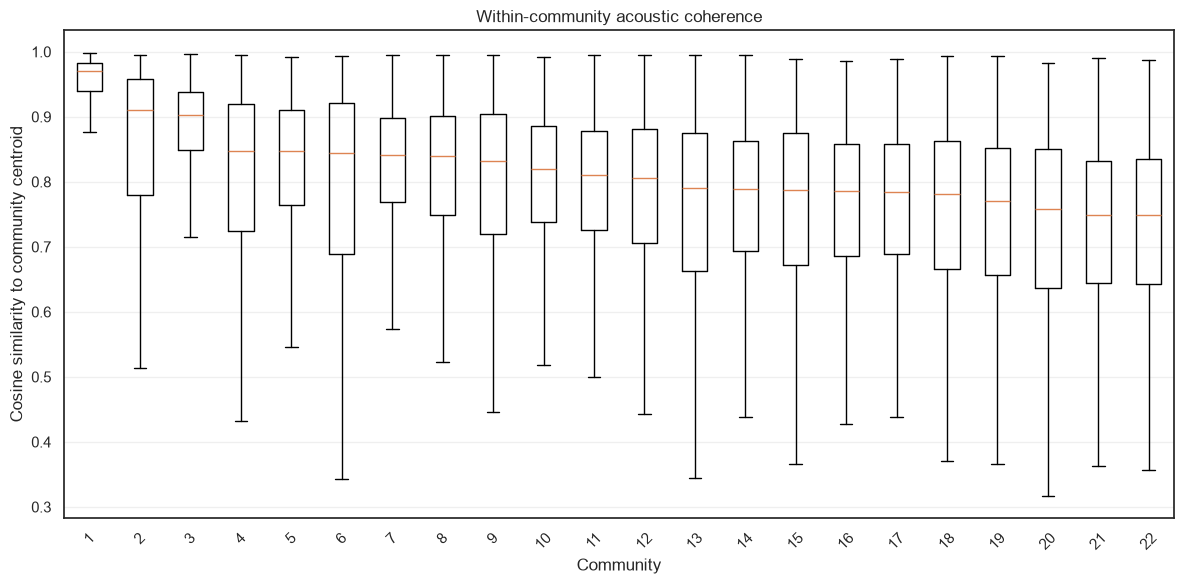

In [146]:
import matplotlib.pyplot as plt

community_order = (
    community_coherence_report
    .sort_values("cosine_median", ascending=False)
    .index
)

boxplot_data = [
    analysis_df.loc[
        analysis_df["community"] == community,
        "centroid_cosine_similarity"
    ].dropna()
    for community in community_order
]

plt.figure(figsize=(12, 6))

plt.boxplot(
    boxplot_data,
    label=community_order.astype(int).tolist(),
    showfliers=False
)

plt.xlabel("Community")
plt.ylabel("Cosine similarity to community centroid")
plt.title("Within-community acoustic coherence")
plt.xticks(rotation=45)
plt.grid(axis="y", alpha=0.3)
plt.tight_layout()
plt.show()

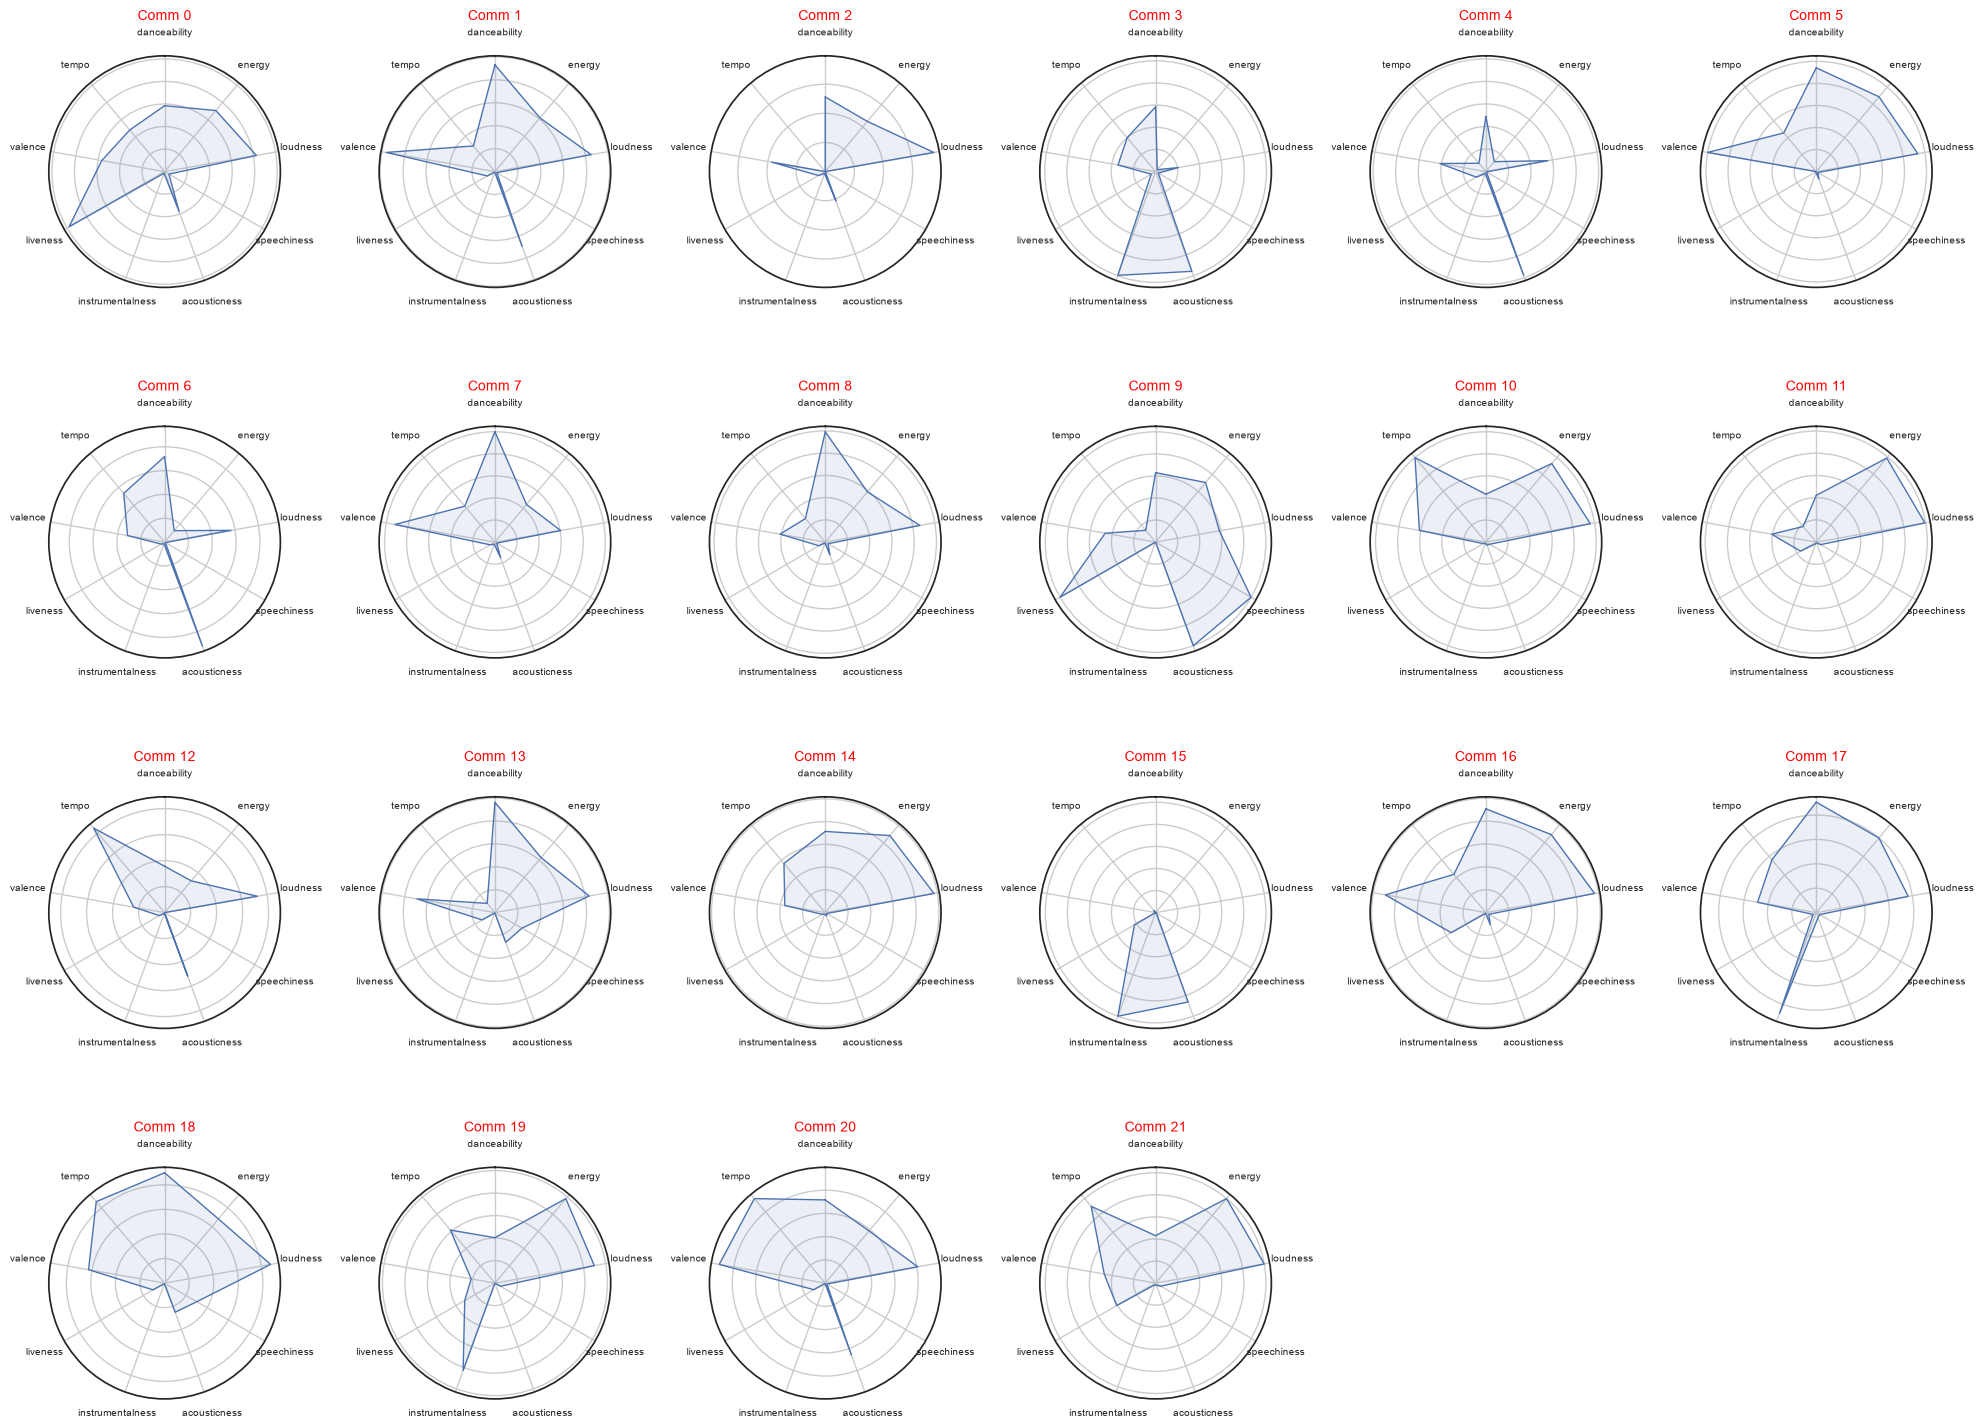

In [66]:
from sklearn.preprocessing import MinMaxScaler

# 1. Calculate average features per community
comm_features = feature_df.groupby('community')[continuous_features].mean()

# 2. Scale 0-1 for radar chart
scaler = MinMaxScaler()
comm_scaled = pd.DataFrame(scaler.fit_transform(comm_features), columns=comm_features.columns)

# 3. Plotting function for "Small Multiples"
def plot_community_radars(df):
    categories = list(df.columns)
    N = len(categories)
    angles = [n / float(N) * 2 * np.pi for n in range(N)]
    angles += angles[:1]
    
    # Create a grid (e.g., 4 rows x 6 columns)
    fig, axes = plt.subplots(4, 6, figsize=(20, 15), subplot_kw=dict(polar=True))
    axes = axes.flatten()
    
    for i in range(len(df)):
        ax = axes[i]
        values = df.iloc[i].values.flatten().tolist()
        values += values[:1]
        
        ax.plot(angles, values, linewidth=1, linestyle='solid')
        ax.fill(angles, values, 'b', alpha=0.1)
        ax.set_theta_offset(np.pi / 2)
        ax.set_theta_direction(-1)
        ax.set_xticks(angles[:-1])
        ax.set_xticklabels(categories, size=7)
        ax.set_title(f"Comm {i}", size=10, color='red')
        ax.set_yticklabels([]) # Hide radial labels for clarity

    # Hide unused axes
    for j in range(i + 1, len(axes)):
        axes[j].axis('off')
        
    plt.tight_layout()
    plt.show()

plot_community_radars(comm_scaled)

In [119]:
from sklearn.cluster import KMeans

model = KMeans(
    n_clusters=19,
    random_state=42,
    n_init=10
)

kmeans_labels = model.fit_predict(X_for_clustering)

In [120]:
import numpy as np
import pandas as pd
from sklearn.metrics import pairwise_distances, silhouette_score

# ============================================================
# INPUTS
# ============================================================

X = np.asarray(X_for_clustering, dtype=float)

partitions = {
    "Louvain communities": np.asarray(community_labels),

    # Replace with your actual K-Means labels
    "K-Means clusters": np.asarray(kmeans_labels)
}

feature_names = list(continuous_features)


# ============================================================
# PARTITION EVALUATION
# ============================================================

def evaluate_partition_geometry(
    X,
    labels,
    feature_names=None,
    silhouette_sample_size=10000,
    random_state=42
):
    """
    Evaluate within-group compactness, between-centroid separation,
    and explained acoustic variance for a partition.
    """

    labels = np.asarray(labels)
    unique_groups = np.unique(labels)

    if len(X) != len(labels):
        raise ValueError("X and labels must have the same number of rows.")

    global_centroid = X.mean(axis=0)

    centroids = []
    group_sizes = []
    within_distances = []
    per_group_rows = []

    # --------------------------------------------------------
    # Group centroids and within-group distances
    # --------------------------------------------------------

    for group in unique_groups:
        mask = labels == group
        X_group = X[mask]

        centroid = X_group.mean(axis=0)
        distances = np.linalg.norm(X_group - centroid, axis=1)

        centroids.append(centroid)
        group_sizes.append(len(X_group))
        within_distances.extend(distances)

        per_group_rows.append({
            "group": group,
            "size": len(X_group),
            "mean_distance_to_centroid": distances.mean(),
            "median_distance_to_centroid": np.median(distances),
            "mean_feature_std": X_group.std(axis=0, ddof=0).mean()
        })

    centroids = np.vstack(centroids)
    group_sizes = np.asarray(group_sizes)
    within_distances = np.asarray(within_distances)

    # --------------------------------------------------------
    # Variance decomposition
    # --------------------------------------------------------

    # Total sum of squares
    tss = np.sum((X - global_centroid) ** 2)

    # Within-group sum of squares
    wss = 0.0

    for group, centroid in zip(unique_groups, centroids):
        X_group = X[labels == group]
        wss += np.sum((X_group - centroid) ** 2)

    # Between-group sum of squares
    bss = tss - wss

    explained_variance_ratio = bss / tss

    # --------------------------------------------------------
    # Distances between group centroids
    # --------------------------------------------------------

    centroid_distances = pairwise_distances(
        centroids,
        metric="euclidean"
    )

    upper_triangle = centroid_distances[
        np.triu_indices_from(centroid_distances, k=1)
    ]

    mean_centroid_distance = upper_triangle.mean()
    median_centroid_distance = np.median(upper_triangle)
    minimum_centroid_distance = upper_triangle.min()

    mean_within_distance = within_distances.mean()

    # Simple separation-to-compactness ratio
    separation_ratio = (
        mean_centroid_distance / mean_within_distance
    )

    # --------------------------------------------------------
    # Approximate silhouette on a sample
    # --------------------------------------------------------

    rng = np.random.default_rng(random_state)

    if len(X) > silhouette_sample_size:
        sample_indices = rng.choice(
            len(X),
            size=silhouette_sample_size,
            replace=False
        )

        silhouette = silhouette_score(
            X[sample_indices],
            labels[sample_indices],
            metric="euclidean"
        )
    else:
        silhouette = silhouette_score(
            X,
            labels,
            metric="euclidean"
        )

    # --------------------------------------------------------
    # Per-feature explained variance
    # --------------------------------------------------------

    feature_eta_squared = {}

    if feature_names is None:
        feature_names = [
            f"feature_{i}" for i in range(X.shape[1])
        ]

    for feature_index, feature_name in enumerate(feature_names):
        feature_values = X[:, feature_index]
        feature_mean = feature_values.mean()

        feature_tss = np.sum(
            (feature_values - feature_mean) ** 2
        )

        feature_wss = 0.0

        for group in unique_groups:
            group_values = feature_values[labels == group]

            feature_wss += np.sum(
                (group_values - group_values.mean()) ** 2
            )

        feature_eta_squared[feature_name] = (
            1 - feature_wss / feature_tss
            if feature_tss > 0
            else np.nan
        )

    summary = {
        "groups": len(unique_groups),
        "mean_within_distance": mean_within_distance,
        "median_within_distance": np.median(within_distances),
        "mean_centroid_distance": mean_centroid_distance,
        "median_centroid_distance": median_centroid_distance,
        "minimum_centroid_distance": minimum_centroid_distance,
        "separation_ratio": separation_ratio,
        "explained_variance": explained_variance_ratio,
        "silhouette": silhouette
    }

    return (
        summary,
        pd.DataFrame(per_group_rows),
        pd.Series(
            feature_eta_squared,
            name="explained_variance"
        )
    )


# ============================================================
# RUN BOTH PARTITIONS
# ============================================================

summary_rows = []
group_details = {}
feature_explained_variance = {}

for partition_name, labels in partitions.items():

    summary, details, feature_eta = evaluate_partition_geometry(
        X=X,
        labels=labels,
        feature_names=feature_names,
        silhouette_sample_size=10000,
        random_state=42
    )

    summary["partition"] = partition_name
    summary_rows.append(summary)

    group_details[partition_name] = details
    feature_explained_variance[partition_name] = feature_eta


comparison_df = (
    pd.DataFrame(summary_rows)
    .set_index("partition")
)

feature_comparison_df = pd.DataFrame(
    feature_explained_variance
)

display(comparison_df.round(4))
display(feature_comparison_df.round(4))

,groups,mean_within_distance,median_within_distance,mean_centroid_distance,median_centroid_distance,minimum_centroid_distance,separation_ratio,explained_variance,silhouette
partition,,,,,,,,,
Louvain communities,22,1.7348,1.6067,3.4976,3.1161,1.1588,2.0161,0.6060,0.0421
K-Means clusters,19,1.6246,1.5295,4.1235,3.7029,1.4017,2.5382,0.6709,0.1445


,Louvain communities,K-Means clusters
danceability,0.4825,0.5688
energy,0.5803,0.6787
loudness,0.4816,0.6433
speechiness,0.7388,0.7840
acousticness,0.6657,0.7087
instrumentalness,0.9047,0.8751
liveness,0.6252,0.6475
valence,0.4341,0.6152
tempo,0.5412,0.5168


In [121]:
# ============================================================
# PRINT SUMMARY
# ============================================================

for partition_name, labels in partitions.items():

    summary, details, feature_eta = evaluate_partition_geometry(
        X=X,
        labels=labels,
        feature_names=feature_names,
        silhouette_sample_size=10000,
        random_state=42
    )

    print("\n" + "="*60)
    print(partition_name)
    print("="*60)

    print(f"Number of groups:            {summary['groups']}")
    print(f"Mean within distance:        {summary['mean_within_distance']:.4f}")
    print(f"Median within distance:      {summary['median_within_distance']:.4f}")
    print(f"Mean centroid distance:      {summary['mean_centroid_distance']:.4f}")
    print(f"Median centroid distance:    {summary['median_centroid_distance']:.4f}")
    print(f"Minimum centroid distance:   {summary['minimum_centroid_distance']:.4f}")
    print(f"Separation ratio:            {summary['separation_ratio']:.4f}")
    print(f"Explained variance (η²):     {summary['explained_variance']:.4f}")
    print(f"Silhouette score:            {summary['silhouette']:.4f}")

    print("\nTop 5 most homogeneous groups:")
    print(
        details.sort_values("mean_distance_to_centroid")
               .head(5)
               .to_string(index=False)
    )

    print("\nTop explained features:")
    print(
        feature_eta.sort_values(ascending=False)
                   .round(3)
                   .to_string()
    )


Louvain communities
Number of groups:            22
Mean within distance:        1.7348
Median within distance:      1.6067
Mean centroid distance:      3.4976
Median centroid distance:    3.1161
Minimum centroid distance:   1.1588
Separation ratio:            2.0161
Explained variance (η²):     0.6060
Silhouette score:            0.0421

Top 5 most homogeneous groups:
 group  size  mean_distance_to_centroid  median_distance_to_centroid  mean_feature_std
     5  4374                   1.053386                     1.025294          0.342379
    14  5527                   1.119185                     1.096903          0.361761
    16  4090                   1.286332                     1.241974          0.420774
     8  4875                   1.330356                     1.285527          0.438220
     7  3028                   1.398441                     1.351046          0.459565

Top explained features:
instrumentalness    0.905
speechiness         0.739
acousticness        0.666
li

In [118]:
# ============================================================
# PRINT SUMMARY
# ============================================================

for partition_name, labels in partitions.items():

    summary, details, feature_eta = evaluate_partition_geometry(
        X=X,
        labels=labels,
        feature_names=feature_names,
        silhouette_sample_size=10000,
        random_state=42
    )

    print("\n" + "="*60)
    print(partition_name)
    print("="*60)

    print(f"Number of groups:            {summary['groups']}")
    print(f"Mean within distance:        {summary['mean_within_distance']:.4f}")
    print(f"Median within distance:      {summary['median_within_distance']:.4f}")
    print(f"Mean centroid distance:      {summary['mean_centroid_distance']:.4f}")
    print(f"Median centroid distance:    {summary['median_centroid_distance']:.4f}")
    print(f"Minimum centroid distance:   {summary['minimum_centroid_distance']:.4f}")
    print(f"Separation ratio:            {summary['separation_ratio']:.4f}")
    print(f"Explained variance (η²):     {summary['explained_variance']:.4f}")
    print(f"Silhouette score:            {summary['silhouette']:.4f}")

    print("\nTop 5 most homogeneous groups:")
    print(
        details.sort_values("mean_distance_to_centroid")
               .head(5)
               .to_string(index=False)
    )

    print("\nTop explained features:")
    print(
        feature_eta.sort_values(ascending=False)
                   .round(3)
                   .to_string()
    )


Louvain communities
Number of groups:            22
Mean within distance:        1.7348
Median within distance:      1.6067
Mean centroid distance:      3.4976
Median centroid distance:    3.1161
Minimum centroid distance:   1.1588
Separation ratio:            2.0161
Explained variance (η²):     0.6060
Silhouette score:            0.0421

Top 5 most homogeneous groups:
 group  size  mean_distance_to_centroid  median_distance_to_centroid  mean_feature_std
     5  4374                   1.053386                     1.025294          0.342379
    14  5527                   1.119185                     1.096903          0.361761
    16  4090                   1.286332                     1.241974          0.420774
     8  4875                   1.330356                     1.285527          0.438220
     7  3028                   1.398441                     1.351046          0.459565

Top explained features:
instrumentalness    0.905
speechiness         0.739
acousticness        0.666
li

In [122]:
import numpy as np
import pandas as pd
import networkx as nx


def evaluate_partition_connectivity(
    G,
    labels,
    partition_name,
    node_order=None
):
    """
    Evaluate whether each group in a partition forms a connected
    subgraph of G.

    Parameters
    ----------
    G : networkx.Graph
        Song similarity graph.

    labels : array-like
        Group label for each node.

    partition_name : str
        Name used in the printed output.

    node_order : list, optional
        Node ordering corresponding to labels.
        Defaults to list(G.nodes()).
    """

    if node_order is None:
        node_order = list(G.nodes())

    labels = np.asarray(labels)

    if len(node_order) != len(labels):
        raise ValueError(
            f"Number of nodes ({len(node_order)}) does not match "
            f"number of labels ({len(labels)})."
        )

    node_to_group = dict(zip(node_order, labels))
    unique_groups = np.unique(labels)

    rows = []

    for group in unique_groups:

        group_nodes = [
            node for node in node_order
            if node_to_group[node] == group
        ]

        subgraph = G.subgraph(group_nodes)
        size = subgraph.number_of_nodes()
        internal_edges = subgraph.number_of_edges()

        if size == 0:
            continue

        components = list(nx.connected_components(subgraph))
        component_sizes = sorted(
            [len(component) for component in components],
            reverse=True
        )

        n_components = len(component_sizes)
        largest_component_size = component_sizes[0]
        largest_component_share = largest_component_size / size

        isolated_nodes = nx.number_of_isolates(subgraph)
        isolated_share = isolated_nodes / size

        # Edges incident to nodes in the group, counted once
        incident_edges = {
            tuple(sorted((u, v), key=str))
            for node in group_nodes
            for u, v in G.edges(node)
        }

        total_incident_edges = len(incident_edges)

        internal_edge_ratio = (
            internal_edges / total_incident_edges
            if total_incident_edges > 0
            else np.nan
        )

        rows.append({
            "group": group,
            "size": size,
            "connected_components": n_components,
            "largest_component_size": largest_component_size,
            "largest_component_share": largest_component_share,
            "isolated_nodes": isolated_nodes,
            "isolated_share": isolated_share,
            "internal_edges": internal_edges,
            "internal_edge_ratio": internal_edge_ratio
        })

    details = pd.DataFrame(rows)

    # Weighted metrics prevent small groups from having the same
    # influence as very large groups.
    weights = details["size"] / details["size"].sum()

    summary = {
        "partition": partition_name,
        "groups": len(details),
        "fully_connected_groups": int(
            (details["connected_components"] == 1).sum()
        ),
        "fragmented_groups": int(
            (details["connected_components"] > 1).sum()
        ),
        "total_components": int(
            details["connected_components"].sum()
        ),
        "mean_components_per_group": (
            details["connected_components"].mean()
        ),
        "median_components_per_group": (
            details["connected_components"].median()
        ),
        "weighted_largest_component_share": (
            details["largest_component_share"] * weights
        ).sum(),
        "weighted_isolated_share": (
            details["isolated_share"] * weights
        ).sum(),
        "weighted_internal_edge_ratio": (
            details["internal_edge_ratio"] * weights
        ).sum()
    }

    return summary, details


def print_connectivity_results(summary, details, top_n=10):

    print("\n" + "=" * 68)
    print(summary["partition"])
    print("=" * 68)

    print(f"Number of groups:                    {summary['groups']}")
    print(f"Fully connected groups:              {summary['fully_connected_groups']}")
    print(f"Fragmented groups:                   {summary['fragmented_groups']}")
    print(f"Total induced components:            {summary['total_components']}")
    print(
        f"Mean components per group:           "
        f"{summary['mean_components_per_group']:.2f}"
    )
    print(
        f"Median components per group:         "
        f"{summary['median_components_per_group']:.2f}"
    )
    print(
        f"Weighted largest-component share:    "
        f"{summary['weighted_largest_component_share']:.4f}"
    )
    print(
        f"Weighted isolated-node share:        "
        f"{summary['weighted_isolated_share']:.4f}"
    )
    print(
        f"Weighted internal-edge ratio:        "
        f"{summary['weighted_internal_edge_ratio']:.4f}"
    )

    print("\nMost fragmented groups:")
    print(
        details
        .sort_values(
            ["largest_component_share", "connected_components"],
            ascending=[True, False]
        )
        .head(top_n)
        .to_string(
            index=False,
            formatters={
                "largest_component_share": "{:.4f}".format,
                "isolated_share": "{:.4f}".format,
                "internal_edge_ratio": "{:.4f}".format
            }
        )
    )

In [123]:
node_order = list(G.nodes())

louvain_summary, louvain_connectivity = evaluate_partition_connectivity(
    G=G,
    labels=community_labels,
    partition_name="Louvain communities",
    node_order=node_order
)

kmeans_summary, kmeans_connectivity = evaluate_partition_connectivity(
    G=G,
    labels=kmeans_labels,
    partition_name="K-Means clusters",
    node_order=node_order
)

print_connectivity_results(
    louvain_summary,
    louvain_connectivity
)

print_connectivity_results(
    kmeans_summary,
    kmeans_connectivity
)


Louvain communities
Number of groups:                    22
Fully connected groups:              22
Fragmented groups:                   0
Total induced components:            22
Mean components per group:           1.00
Median components per group:         1.00
Weighted largest-component share:    1.0000
Weighted isolated-node share:        0.0000
Weighted internal-edge ratio:        0.7716

Most fragmented groups:
 group  size  connected_components  largest_component_size largest_component_share  isolated_nodes isolated_share  internal_edges internal_edge_ratio
     0  6950                     1                    6950                  1.0000               0         0.0000           35691              0.8423
     1  5173                     1                    5173                  1.0000               0         0.0000           23772              0.7214
     2  2801                     1                    2801                  1.0000               0         0.0000           12371

In [124]:
node_order = list(range(len(kmeans_labels)))

assert set(node_order) == set(G.nodes())

In [125]:
node_order = list(G.nodes())

print(node_order[:10])
print(node_order[-10:])

assert node_order == list(range(len(kmeans_labels)))

[0, 1, 2, 3, 4, 5, 6, 7, 8, 9]
[105998, 105999, 106000, 106001, 106002, 106003, 106004, 106005, 106006, 106007]


In [126]:
# Use the exact dataframe index corresponding to the matrix used by K-Means
kmeans_by_node = pd.Series(
    kmeans_labels,
    index=feature_df.index
)

node_order = list(G.nodes())

kmeans_labels_aligned = (
    kmeans_by_node
    .loc[node_order]
    .to_numpy()
)

In [127]:
kmeans_summary, kmeans_connectivity = evaluate_partition_connectivity(
    G=G,
    labels=kmeans_labels_aligned,
    partition_name="K-Means clusters",
    node_order=node_order
)

In [129]:
print_connectivity_results(
    louvain_summary,
    louvain_connectivity
)

print_connectivity_results(
    kmeans_summary,
    kmeans_connectivity
)


Louvain communities
Number of groups:                    22
Fully connected groups:              22
Fragmented groups:                   0
Total induced components:            22
Mean components per group:           1.00
Median components per group:         1.00
Weighted largest-component share:    1.0000
Weighted isolated-node share:        0.0000
Weighted internal-edge ratio:        0.7716

Most fragmented groups:
 group  size  connected_components  largest_component_size largest_component_share  isolated_nodes isolated_share  internal_edges internal_edge_ratio
     0  6950                     1                    6950                  1.0000               0         0.0000           35691              0.8423
     1  5173                     1                    5173                  1.0000               0         0.0000           23772              0.7214
     2  2801                     1                    2801                  1.0000               0         0.0000           12371

In [63]:
import networkx as nx
from sklearn.neighbors import NearestNeighbors

# 1. Build the k-NN for 100k songs (k=10)
# Use the dataframe where you kept the 'genre' column for labels
knn = NearestNeighbors(n_neighbors=10, metric='cosine')
knn.fit(X_for_clustering)
distances, indices = knn.kneighbors(X_for_clustering)

# 2. Create the Graph
G_songs = nx.Graph()

# 3. Add edges (this may take a minute for 1M edges)
# We use the index of the songs as nodes
for i, neighbors in enumerate(indices):
    for neighbor in neighbors[1:]: # Skip the first one because it's the song itself
        G_songs.add_edge(i, neighbor)

# 4. Attach genre labels to the nodes
# Assuming 'spotify' is your original df with the 'genre' column
genre_labels = spotify['genre'].to_dict()
nx.set_node_attributes(G_songs, genre_labels, 'genre')

# 5. CALCULATE ASSORTATIVITY
assortativity = nx.attribute_assortativity_coefficient(G_songs, 'genre')

print(f"The Genre Assortativity of the Spotify Dataset is: {assortativity:.4f}")

The Genre Assortativity of the Spotify Dataset is: 0.1001


In [65]:
import networkx as nx
from sklearn.neighbors import NearestNeighbors

# 1. Build the k-NN for 100k songs (k=10)
# Use the dataframe where you kept the 'genre' column for labels
knn = NearestNeighbors(n_neighbors=10, metric='cosine')
knn.fit(X_for_clustering)
distances, indices = knn.kneighbors(X_for_clustering)

# 2. Create the Graph
G_songs = nx.Graph()

# 3. Add edges (this may take a minute for 1M edges)
# We use the index of the songs as nodes
for i, neighbors in enumerate(indices):
    for neighbor in neighbors[1:]: # Skip the first one because it's the song itself
        G_songs.add_edge(i, neighbor)

# 4. Attach genre labels to the nodes
# Assuming 'spotify' is your original df with the 'genre' column
genre_labels = spotify['macro_genre'].to_dict()
nx.set_node_attributes(G_songs, genre_labels, 'macro_genre')

# 5. CALCULATE ASSORTATIVITY
assortativity = nx.attribute_assortativity_coefficient(G_songs, 'macro_genre')

print(f"The Macro-Genre Assortativity of the Spotify Dataset is: {assortativity:.4f}")

The Macro-Genre Assortativity of the Spotify Dataset is: 0.1886


Efficient Graph Construction

In [66]:
import numpy as np
import pandas as pd
import networkx as nx
import scipy.sparse as sp
from sklearn.neighbors import NearestNeighbors

# 1. Build the k-NN (k=10)
# We use Cosine because music is about the 'ratio' of features
knn = NearestNeighbors(n_neighbors=11, metric='cosine', n_jobs=-1)
knn.fit(X_for_clustering)
distances, indices = knn.kneighbors(X_for_clustering)

# 2. Build the Adjacency Matrix (Sparse)
rows = np.repeat(np.arange(indices.shape[0]), indices.shape[1]-1)
cols = indices[:, 1:].flatten() # Skip self-link
data = np.ones(len(rows))

adj_matrix = sp.csr_matrix((data, (rows, cols)), shape=(len(spotify), len(spotify)))

# 3. Create the NetworkX object (for metrics)
G_songs = nx.from_scipy_sparse_array(adj_matrix)

In [67]:
# Attach genre labels to nodes
genre_dict = spotify['macro_genre'].to_dict()
nx.set_node_attributes(G_songs, genre_dict, 'macro_genre')

# Calculate Assortativity
global_assortativity = nx.attribute_assortativity_coefficient(G_songs, 'macro_genre')
print(f"Global Macro-Genre Assortativity: {global_assortativity:.4f}")

Global Macro-Genre Assortativity: 0.1876


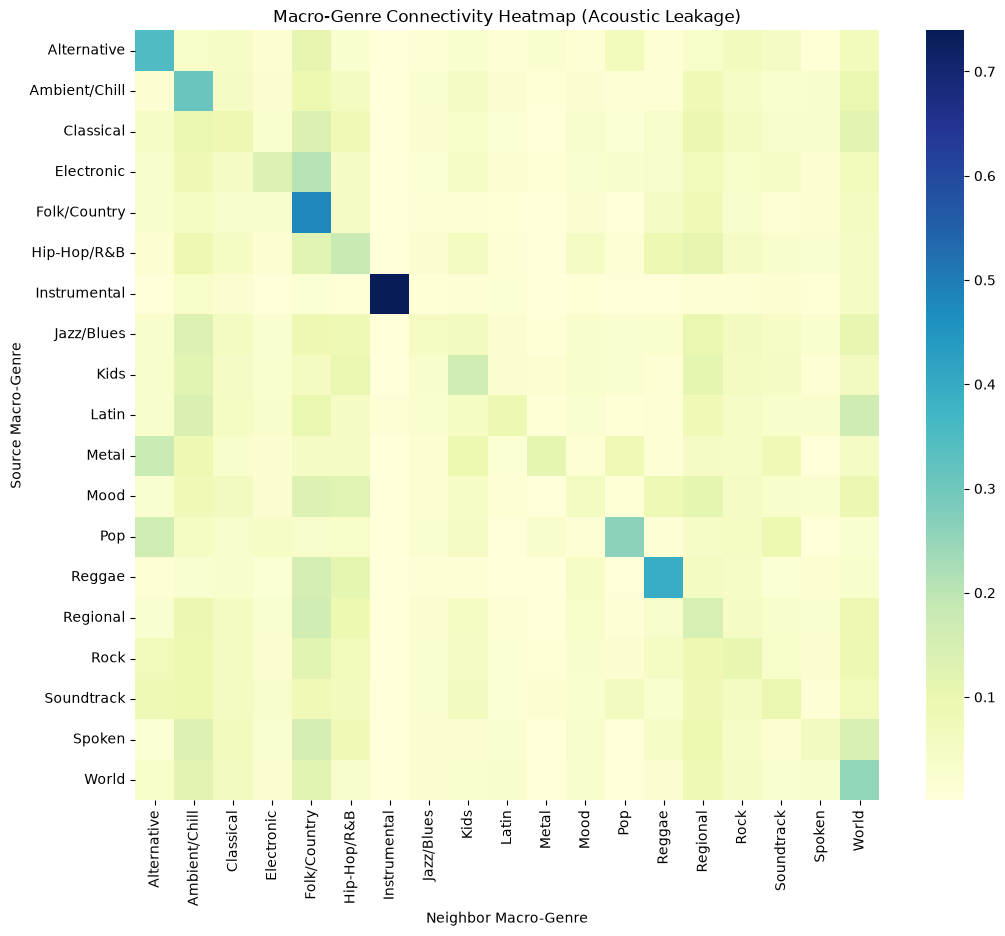

In [71]:
import seaborn as sns

# 1. Get the mixing matrix (counts of edges between genre pairs)
# This results in a matrix where [i, j] is the number of edges from Genre I to Genre J
mixing_matrix = nx.attribute_mixing_matrix(G_songs, 'macro_genre')

# 2. Convert to DataFrame for visualization
genres_list = sorted(spotify['macro_genre'].unique())
mixing_df = pd.DataFrame(mixing_matrix, index=genres_list, columns=genres_list)

# 3. Normalize by row to see "If I am genre X, where do my neighbors go?"
mixing_df_norm = mixing_df.div(mixing_df.sum(axis=1), axis=0)

plt.figure(figsize=(12, 10))
sns.heatmap(mixing_df_norm, cmap='YlGnBu', annot=False)
plt.title("Macro-Genre Connectivity Heatmap (Acoustic Leakage)")
plt.xlabel("Neighbor Macro-Genre")
plt.ylabel("Source Macro-Genre")
plt.show()

In [81]:
import numpy as np

# 1. Force the genre column into a vanilla NumPy "Object" array
# .tolist() is the most reliable way to strip all Pandas-specific behaviors
all_genres_np = np.array(spotify['macro_genre'].tolist(), dtype=object)

# 2. Map neighbor indices to genres -> Result is a (100000, 10) NumPy array
neighbor_genres = all_genres_np[indices[:, 1:]]

# 3. Get own genres and reshape -> Result is a (100000, 1) NumPy array
own_genres = all_genres_np.reshape(-1, 1)

# 4. Perform the comparison
# Because these are now pure NumPy object arrays, != will work perfectly with broadcasting
mismatches_matrix = (neighbor_genres != own_genres)

# 5. Sum the True values across the rows (axis 1)
mismatches = mismatches_matrix.sum(axis=1)

# 6. Assign the score back to your dataframe
spotify['boundary_index'] = mismatches / 10.0

# 7. Show the results
print("Success! Boundary Index calculated.")
print(spotify[['name', 'artists', 'macro_genre', 'boundary_index']].head())

Success! Boundary Index calculated.
                            name                   artists  macro_genre  \
0                          Lolly                      Rill     Regional   
1  Böxig Leise - Pig & Dan Remix  Paul Kalkbrenner;Pig&Dan   Electronic   
2                     Teeje Week             Jordan Sandhu  Hip-Hop/R&B   
3                           Tief          Paul Kalkbrenner   Electronic   
4                       Pangarap           Barbie's Cradle         Rock   

   boundary_index  
0             1.0  
1             0.5  
2             0.8  
3             0.8  
4             0.6  


In [87]:
# A low average boundary index means the genre is very distinct/pure
genre_stability = spotify.groupby('macro_genre')['boundary_index'].mean().sort_values()

print("Genre Stability Score (Lower = More Acoustically Distinct):")
print(genre_stability)

Genre Stability Score (Lower = More Acoustically Distinct):
macro_genre
Spoken           0.217629
Electronic       0.522047
Metal            0.588119
Ambient/Chill    0.645091
Latin            0.678639
Classical        0.718218
Hip-Hop/R&B      0.745456
Rock             0.819128
Folk/Country     0.832992
Pop              0.854151
Mood             0.867199
Instrumental     0.878456
World            0.890332
Soundtrack       0.896848
Kids             0.904707
Regional         0.909911
Reggae           0.936731
Alternative      0.939584
Jazz/Blues       0.946368
Name: boundary_index, dtype: float64


In [89]:
# Boundary Index 0.0 means all 10 neighbors are the same genre
archetypes = spotify[spotify['boundary_index'] == 0.0]
print(f"Found {len(archetypes)} archetype songs.")
print(archetypes[['name', 'artists', 'macro_genre']].sample(10))

Found 3356 archetype songs.
                                           name  \
64130       Hukum Dan Keadilan Hanya Formalitas   
52003                                  Diazepam   
19545                              Latinos Work   
36560                             Hey Metallica   
102814                                      Rkd   
39805                               Vire e Mexe   
59565    Ocean Sounds: Relaxing Wind - Loopable   
83724                               Interlinked   
28681   Embrace - Black Coffee + Aquatone Remix   
41650                                  Tomorrow   

                                    artists    macro_genre  
64130                                  Noxa          Metal  
52003                                ten56.          Metal  
19545                          George Lopez         Spoken  
36560                           Archagathus          Metal  
102814                        Burning Skies          Metal  
39805                        Bonde do Forró 

In [91]:
# Boundary Index 1.0 means NONE of the neighbors share the song's genre
crossovers = spotify[spotify['boundary_index'] >= 0.9]
print("Crossover / Bridge Songs (Acoustic Imposters):")
print(crossovers[['name', 'artists', 'macro_genre']].head(10))

Crossover / Bridge Songs (Acoustic Imposters):
                                        name                 artists  \
0                                      Lolly                    Rill   
7   El Tiempo Es Dinero - Remasterizado 2007             Soda Stereo   
8                                   Poor Man  Old Crow Medicine Show   
13                        Sandwiches de Miga           Pappo's Blues   
14                                  Lovemark              Ouse;Powfu   
18                                 キミが好きで、、、                   Leola   
20                        Got You On My Mind    Horizon Blue;Carston   
21           528Hz Energía curativa profunda                 Mc_team   
25                        Yemyeşil Bir Deniz              İlhan İrem   
26                                Shaayraana     Pritam;Arijit Singh   

     macro_genre  
0       Regional  
7    Alternative  
8   Folk/Country  
13   Alternative  
14   Alternative  
18      Regional  
20      Regional  
21      

In [82]:
import community as community_louvain

# This finds communities based on song connectivity
partition = community_louvain.best_partition(G_songs)
spotify['network_community'] = spotify.index.map(partition)

# Now, let's see how many 'Network Communities' represent each 'Spotify Genre'
community_agreement = spotify.groupby('macro_genre')['network_community'].nunique()
print("Number of acoustic communities per macro_genre:")
print(community_agreement.sort_values(ascending=False).head(10))

Number of acoustic communities per macro_genre:
macro_genre
Alternative      22
Ambient/Chill    22
Classical        22
Electronic       22
Folk/Country     22
Hip-Hop/R&B      22
Jazz/Blues       22
Latin            22
Kids             22
Metal            22
Name: network_community, dtype: int64


In [83]:
# 1. Create a Cross-tabulation (Genre vs Community)
# This shows exactly how many songs of Genre X are in Community Y
ctab = pd.crosstab(spotify['macro_genre'], spotify['network_community'])

# 2. Calculate the "Concentration"
# What % of the genre is in its most populated community?
concentration = (ctab.max(axis=1) / ctab.sum(axis=1)).sort_values(ascending=False)

# 3. Find the "Primary Community ID" for each genre
primary_comm = ctab.idxmax(axis=1)

enrichment_df = pd.DataFrame({
    'Primary_Community': primary_comm,
    'Concentration_Score': concentration
})

print("Genre Concentration (How much a genre 'sticks' to one acoustic community):")
print(enrichment_df)

Genre Concentration (How much a genre 'sticks' to one acoustic community):
               Primary_Community  Concentration_Score
macro_genre                                          
Alternative                    8             0.124517
Ambient/Chill                 13             0.465905
Classical                     13             0.460106
Electronic                    20             0.301371
Folk/Country                  15             0.180543
Hip-Hop/R&B                    0             0.217417
Instrumental                  13             0.517281
Jazz/Blues                    15             0.156236
Kids                           0             0.134647
Latin                         16             0.178293
Metal                         10             0.234134
Mood                          18             0.102897
Pop                           15             0.120560
Reggae                         0             0.156923
Regional                       0             0.111657
Rock   

In [84]:
# Function to get the top genres for a specific community
def get_community_makeup(comm_id, top_n=3):
    subset = spotify[spotify['network_community'] == comm_id]
    makeup = subset['macro_genre'].value_counts(normalize=True).head(top_n)
    return ", ".join([f"{g} ({p:.1%})" for g, p in makeup.items()])

# Apply to all 22 communities
community_profiles = pd.DataFrame(index=range(22))
community_profiles['Top_Genres'] = community_profiles.index.map(get_community_makeup)

print("What are the communities actually made of?")
print(community_profiles)

What are the communities actually made of?
                                           Top_Genres
0   Hip-Hop/R&B (34.1%), Latin (12.0%), Regional (...
1   Ambient/Chill (38.9%), Electronic (32.6%), Wor...
2   Hip-Hop/R&B (29.7%), Electronic (15.4%), Latin...
3   Pop (15.6%), Hip-Hop/R&B (15.3%), Electronic (...
4   Spoken (75.7%), Soundtrack (4.2%), Hip-Hop/R&B...
5     Latin (32.3%), Rock (9.5%), Folk/Country (8.8%)
6     Electronic (24.3%), Metal (15.0%), Rock (13.6%)
7     Metal (34.8%), Electronic (31.4%), World (5.8%)
8     Electronic (25.3%), Rock (16.5%), Metal (14.9%)
9       Rock (19.6%), Pop (17.3%), Electronic (17.3%)
10    Metal (25.6%), Rock (17.2%), Electronic (12.6%)
11  Electronic (34.5%), Hip-Hop/R&B (16.3%), Pop (...
12   Folk/Country (14.7%), Pop (12.6%), Latin (11.5%)
13  Ambient/Chill (34.1%), Classical (13.6%), Elec...
14  Hip-Hop/R&B (16.0%), Rock (15.1%), Electronic ...
15    Pop (15.4%), Folk/Country (11.0%), World (9.4%)
16     Latin (30.3%), Electronic (12.4%

In [85]:
from scipy.stats import entropy

def calculate_entropy(comm_id):
    # Get the distribution of genres in this community
    probs = spotify[spotify['network_community'] == comm_id]['macro_genre'].value_counts(normalize=True)
    return entropy(probs)

community_profiles['Entropy'] = community_profiles.index.map(calculate_entropy)
print(community_profiles.sort_values(by='Entropy'))

                                           Top_Genres   Entropy
4   Spoken (75.7%), Soundtrack (4.2%), Hip-Hop/R&B...  1.158624
20  Electronic (66.7%), Ambient/Chill (6.1%), Pop ...  1.456812
1   Ambient/Chill (38.9%), Electronic (32.6%), Wor...  1.822625
7     Metal (34.8%), Electronic (31.4%), World (5.8%)  1.872991
11  Electronic (34.5%), Hip-Hop/R&B (16.3%), Pop (...  2.169031
13  Ambient/Chill (34.1%), Classical (13.6%), Elec...  2.223485
8     Electronic (25.3%), Rock (16.5%), Metal (14.9%)  2.303871
0   Hip-Hop/R&B (34.1%), Latin (12.0%), Regional (...  2.305008
10    Metal (25.6%), Rock (17.2%), Electronic (12.6%)  2.308583
2   Hip-Hop/R&B (29.7%), Electronic (15.4%), Latin...  2.327641
6     Electronic (24.3%), Metal (15.0%), Rock (13.6%)  2.335641
5     Latin (32.3%), Rock (9.5%), Folk/Country (8.8%)  2.366424
21     Electronic (18.8%), Latin (18.1%), Pop (14.3%)  2.390917
9       Rock (19.6%), Pop (17.3%), Electronic (17.3%)  2.397516
16     Latin (30.3%), Electronic (12.4%)

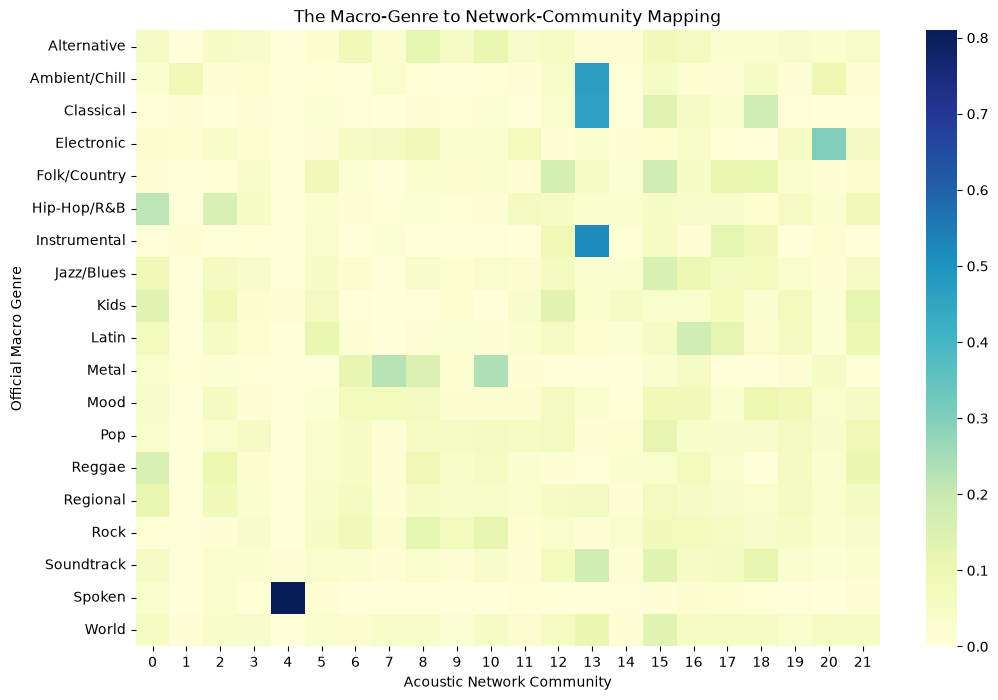

In [86]:
import seaborn as sns

# Normalize the cross-tab so rows sum to 1
ctab_norm = ctab.div(ctab.sum(axis=1), axis=0)

plt.figure(figsize=(12, 8))
sns.heatmap(ctab_norm, cmap="YlGnBu", annot=False)
plt.title("The Macro-Genre to Network-Community Mapping")
plt.ylabel("Official Macro Genre")
plt.xlabel("Acoustic Network Community")
plt.show()

### Page Rank

In [93]:
# Calculate how many times each song was chosen as a neighbor by others
# (Using the sparse adjacency matrix columns)
in_degrees = np.array(adj_matrix.sum(axis=0)).flatten()
spotify['archetype_score'] = in_degrees

# Top "Archetype" songs (The most typical sounding tracks)
print("Top Archetype Songs:")
print(spotify.sort_values(by='archetype_score', ascending=False)[['name', 'artists', 'macro_genre']].head(5))

Top Archetype Songs:
                                           name                      artists  \
29134                                 Powerload                      Disfear   
87378                          Come on Feat. XL             Roy Davis Jr.;XL   
5288   Unchained Melody - Live at Ann Arbor, MI                Elvis Presley   
38776     Story of My Life (Heavy Edit) - Remix  ILLENIUM;Sueco;Trippie Redd   
59749          Bipolar Star - Victor Ruiz Remix           Olivier Giacomotto   

      macro_genre  
29134       Metal  
87378  Electronic  
5288         Rock  
38776      Reggae  
59749  Electronic  


In [94]:
# Compute PageRank on the 100k song graph
# (Using NetworkX's sparse-friendly implementation)
pagerank_scores = nx.pagerank(G_songs, alpha=0.85)

# Map back to dataframe
spotify['pagerank'] = spotify.index.map(pagerank_scores)

print("Top PageRank Songs (The Acoustic Core):")
print(spotify.sort_values(by='pagerank', ascending=False)[['name', 'artists', 'macro_genre']].head(5))

Top PageRank Songs (The Acoustic Core):
                              name        artists  macro_genre
35987                        Feliz    Gonzaguinha        Latin
29134                    Powerload        Disfear        Metal
3841   Más de 100 palabras para ti          Finde  Alternative
15903                   SELECTA 19        JOYRYDE   Electronic
59158       Heartbeat - Radio Edit  John Dahlbäck   Electronic


In [95]:
# Compute clustering coefficient for nodes (subset or full if fast enough)
clustering_coeffs = nx.clustering(G_songs)
spotify['clustering'] = spotify.index.map(clustering_coeffs)

print("Highest Clustering (Tightest sub-genre niches):")
print(spotify.sort_values(by='clustering', ascending=False)[['name', 'artists', 'macro_genre']].head(5))

Highest Clustering (Tightest sub-genre niches):
                                              name  \
15142                             Comforting Noise   
45233                                Hypnotic Song   
52165                                 Non Abrasive   
63040                                 Angelin Song   
20755  Hair Dryer Sound 19 - Loopable With No Fade   

                                                 artists    macro_genre  
15142  Meditation Rain Sounds;Massage Tribe;Perfect M...  Ambient/Chill  
45233  Meditation Rain Sounds;Massage Tribe;Perfect M...  Ambient/Chill  
52165  Meditation Rain Sounds;Massage Tribe;Perfect M...  Ambient/Chill  
63040  Meditation Rain Sounds;Massage Tribe;Perfect M...  Ambient/Chill  
20755  Deep Sleep Hair Dryers;Hair Dryer Collection;H...  Ambient/Chill  


In [97]:
import random

# Take a random sample of 5,000 nodes to estimate 'global' bridges
sample_nodes = random.sample(list(G_songs.nodes()), 5000)
subgraph = G_songs.subgraph(sample_nodes)

betweenness = nx.betweenness_centrality(subgraph, k=100) # k=100 is the number of nodes to sample per step
spotify['betweenness'] = spotify.index.map(betweenness)
spotify['betweenness'] = spotify['betweenness'].fillna(0)

print("Top 10 Crossover Bridges:")
print(spotify.sort_values(by='betweenness', ascending=False)[['name', 'artists', 'macro_genre']].head(10))

Top 10 Crossover Bridges:
                                               name  \
105445                            Young Man's Fancy   
23353                                       Therapy   
59860                               Tears in Heaven   
56217                                   Remembrance   
48016                                  street beats   
90838                             Myintrotoletuknow   
72866                                   Twenty-Five   
78983                                  Bad Together   
94631   Mozart-Twinkle Twinkle Little Star(Lullaby)   
48499                                          3005   

                                artists    macro_genre  
105445                   George Winston  Ambient/Chill  
23353   Andrew Garfield;Vanessa Hudgens     Soundtrack  
59860                         Jon Sarta     Soundtrack  
56217                    George Winston  Ambient/Chill  
48016                            Synkop  Ambient/Chill  
90838                     

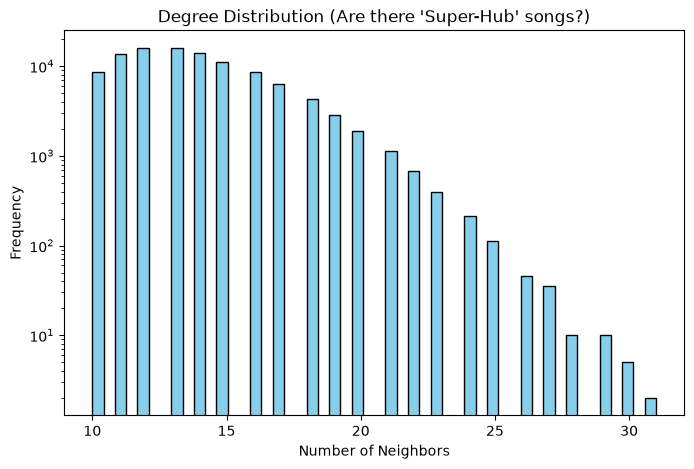

In [98]:
degrees = [d for n, d in G_songs.degree()]

plt.figure(figsize=(8, 5))
plt.hist(degrees, bins=50, color='skyblue', edgecolor='black')
plt.title("Degree Distribution (Are there 'Super-Hub' songs?)")
plt.xlabel("Number of Neighbors")
plt.ylabel("Frequency")
plt.yscale('log') # Log scale is standard for power-law detection
plt.show()

### COmmunities

In [99]:
import community.community_louvain as community_louvain

# Calculate the Modularity Score
mod_score = community_louvain.modularity(partition, G_songs)
print(f"Graph Modularity: {mod_score:.4f}")

Graph Modularity: 0.8098


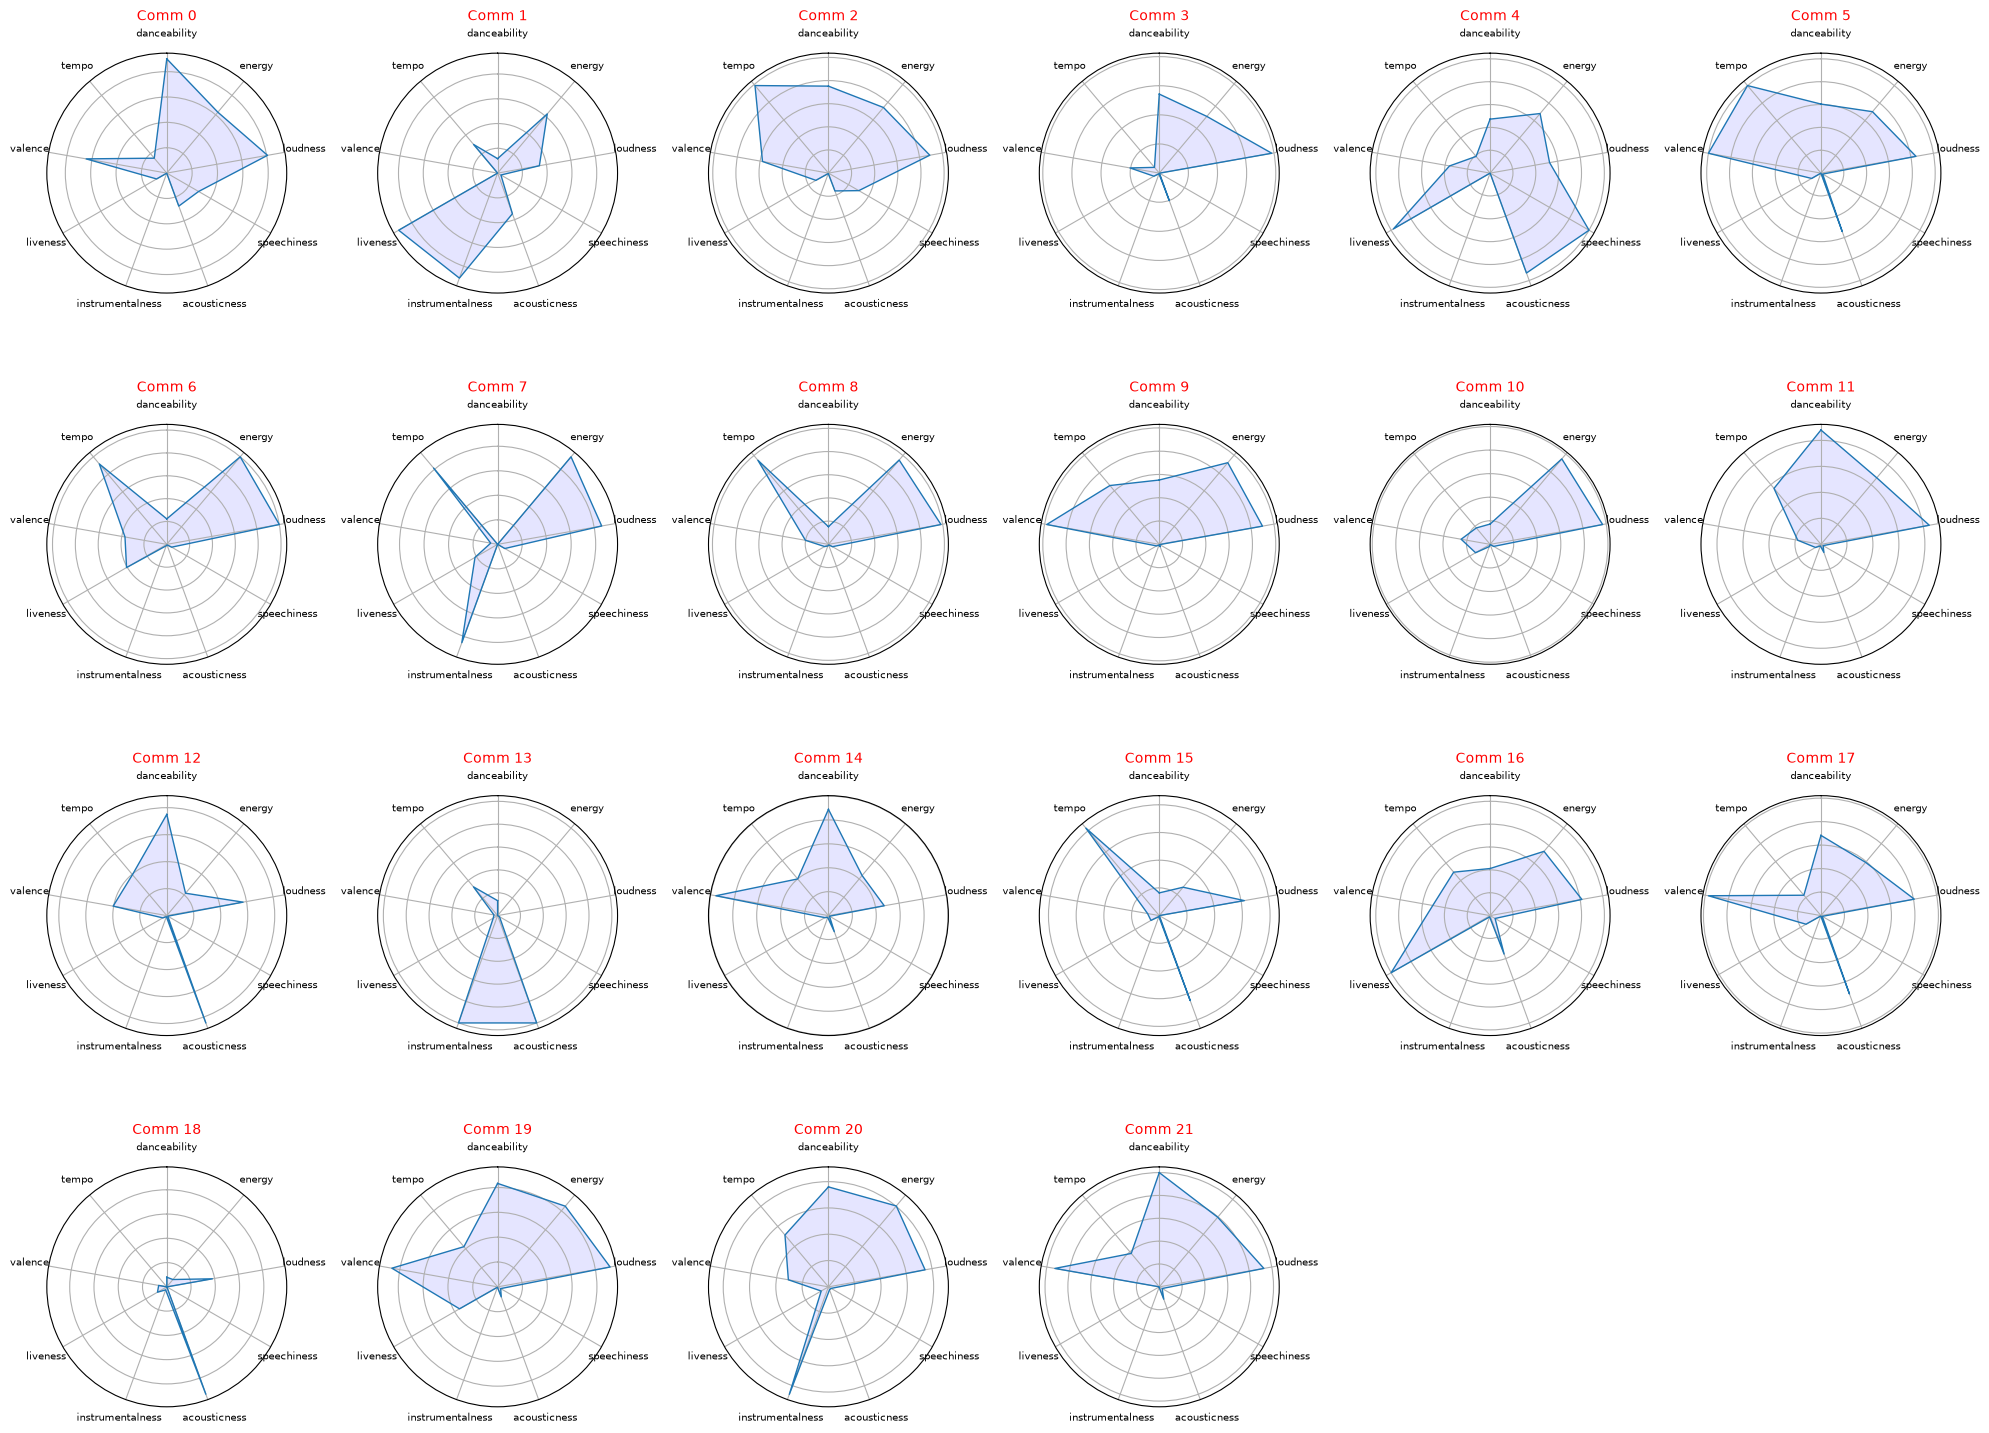

In [100]:
from sklearn.preprocessing import MinMaxScaler

# 1. Calculate average features per community
comm_features = spotify.groupby('network_community')[continuous_features].mean()

# 2. Scale 0-1 for radar chart
scaler = MinMaxScaler()
comm_scaled = pd.DataFrame(scaler.fit_transform(comm_features), columns=comm_features.columns)

# 3. Plotting function for "Small Multiples"
def plot_community_radars(df):
    categories = list(df.columns)
    N = len(categories)
    angles = [n / float(N) * 2 * np.pi for n in range(N)]
    angles += angles[:1]
    
    # Create a grid (e.g., 4 rows x 6 columns)
    fig, axes = plt.subplots(4, 6, figsize=(20, 15), subplot_kw=dict(polar=True))
    axes = axes.flatten()
    
    for i in range(len(df)):
        ax = axes[i]
        values = df.iloc[i].values.flatten().tolist()
        values += values[:1]
        
        ax.plot(angles, values, linewidth=1, linestyle='solid')
        ax.fill(angles, values, 'b', alpha=0.1)
        ax.set_theta_offset(np.pi / 2)
        ax.set_theta_direction(-1)
        ax.set_xticks(angles[:-1])
        ax.set_xticklabels(categories, size=7)
        ax.set_title(f"Comm {i}", size=10, color='red')
        ax.set_yticklabels([]) # Hide radial labels for clarity

    # Hide unused axes
    for j in range(i + 1, len(axes)):
        axes[j].axis('off')
        
    plt.tight_layout()
    plt.show()

plot_community_radars(comm_scaled)

In [102]:
# Degree centrality tells us which song has the most connections WITHIN the network
# (In a k-NN graph, degree is usually k, so we look for PageRank or 'Local Purity')

# Calculate Local Purity: How many of a song's 10 neighbors are in the SAME community?
own_comm = spotify['network_community'].values.reshape(-1, 1)
neighbor_comm = spotify['network_community'].values[indices[:, 1:]]
local_purity = np.sum(neighbor_comm == own_comm, axis=1) / 10.0
spotify['comm_purity'] = local_purity

# Top Archetypes (Purity = 1.0 means the song is 'Deep' inside its community)
archetypes = spotify.sort_values(by='comm_purity', ascending=False).head(10)
print("Top Archetype Songs (The 'Soul' of their respective communities):")
print(archetypes[['name', 'artists', 'macro_genre', 'network_community']])

Top Archetype Songs (The 'Soul' of their respective communities):
                                     name                      artists  \
106002                             以後別做朋友                    Eric Chou   
0                                   Lolly                         Rill   
105983                   Te Amar, Te Amar            Iguinho e Lulinha   
105980                 Soul Samba Express  Ron Trent;Anthony Nicholson   
105979                          Hula Hoop                 Daddy Yankee   
105978                        Dhalti Rahe                 Twin Strings   
105975  The Spice of Life - 2012 Remaster      Everything But The Girl   
105974             Poor Unfortunate Souls           Pat Carroll;Disney   
105972                         Cold Water                  Major Lazer   
105970                    Fruta Prohibida           Dragon & Caballero   

          macro_genre  network_community  
106002            Pop                 15  
0            Regional            

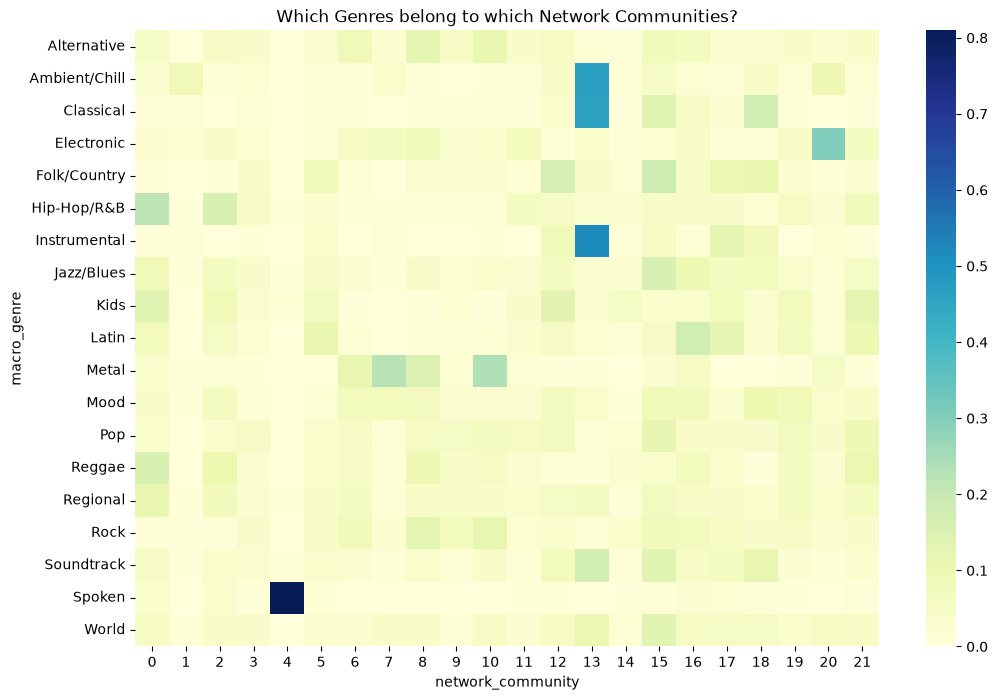

In [103]:
# Create a heatmap of Genre vs Community
# If a community is 'pure', it will have one dark square.
plt.figure(figsize=(12, 8))
sns.heatmap(pd.crosstab(spotify['macro_genre'], spotify['network_community'], normalize='index'), 
            cmap="YlGnBu", annot=False)
plt.title("Which Genres belong to which Network Communities?")
plt.show()

In [104]:
# 1. Prepare arrays for vectorized calculation
comm_labels = spotify['network_community'].values
# 'indices' was generated by your k-NN step (100k x 11)
neighbor_indices = indices[:, 1:] # Skip the first column (self)

# 2. Map neighbor indices to their community IDs
# This creates a 100k x 10 matrix of community IDs
neighbor_comms = comm_labels[neighbor_indices]

# 3. Compare each song's community to its neighbors' communities
# Using broadcasting: (100k, 10) == (100k, 1)
is_same_comm = (neighbor_comms == comm_labels.reshape(-1, 1))

# 4. Calculate Purity (0.0 to 1.0)
spotify['community_purity'] = np.mean(is_same_comm, axis=1)

print(f"Average Community Purity: {spotify['community_purity'].mean():.4f}")

Average Community Purity: 0.8705


In [106]:
# 1. Count how many times each index appears in the neighbor matrix
# np.bincount counts occurrences of integers in an array
in_degree_counts = np.bincount(neighbor_indices.flatten(), minlength=len(spotify))

# 2. Assign back to dataframe
spotify['in_degree'] = in_degree_counts

print("Top 5 Acoustic Magnets (Highest In-Degree):")
print(spotify.sort_values(by='in_degree', ascending=False)[['name', 'artists', 'macro_genre', 'in_degree']].head())

Top 5 Acoustic Magnets (Highest In-Degree):
                                           name                      artists  \
29134                                 Powerload                      Disfear   
87378                          Come on Feat. XL             Roy Davis Jr.;XL   
5288   Unchained Melody - Live at Ann Arbor, MI                Elvis Presley   
38776     Story of My Life (Heavy Edit) - Remix  ILLENIUM;Sueco;Trippie Redd   
59749          Bipolar Star - Victor Ruiz Remix           Olivier Giacomotto   

      macro_genre  in_degree  
29134       Metal         31  
87378  Electronic         30  
5288         Rock         30  
38776      Reggae         30  
59749  Electronic         30  


In [108]:
# 1. Count how many times each index appears in the neighbor matrix
# np.bincount counts occurrences of integers in an array
in_degree_counts = np.bincount(neighbor_indices.flatten(), minlength=len(spotify))

# 2. Assign back to dataframe
spotify['in_degree'] = in_degree_counts

print("Top 5 Acoustic Magnets (Highest In-Degree):")
print(spotify.sort_values(by='in_degree', ascending=False)[['name', 'artists', 'macro_genre', 'in_degree']].head())

Top 5 Acoustic Magnets (Highest In-Degree):
                                           name                      artists  \
29134                                 Powerload                      Disfear   
87378                          Come on Feat. XL             Roy Davis Jr.;XL   
5288   Unchained Melody - Live at Ann Arbor, MI                Elvis Presley   
38776     Story of My Life (Heavy Edit) - Remix  ILLENIUM;Sueco;Trippie Redd   
59749          Bipolar Star - Victor Ruiz Remix           Olivier Giacomotto   

      macro_genre  in_degree  
29134       Metal         31  
87378  Electronic         30  
5288         Rock         30  
38776      Reggae         30  
59749  Electronic         30  


In [109]:
# Which communities are the most 'solid'?
comm_stats = spotify.groupby('network_community').agg({
    'community_purity': 'mean',
    'in_degree': 'mean',
    'danceability': 'mean' # Example of adding an audio feature
}).sort_values(by='community_purity', ascending=False)

print(comm_stats)

                   community_purity  in_degree  danceability
network_community                                           
13                         0.953983   9.967430     -0.803331
4                          0.943033  10.197156     -0.078243
20                         0.929375   9.944318      0.532340
16                         0.917804  10.119898     -0.206755
8                          0.884738  10.199636     -0.757324
10                         0.882905  10.156646     -0.715513
0                          0.880088   9.902197      0.831461
15                         0.878221   9.977488     -0.732882
18                         0.877475  10.267822     -0.912614
7                          0.875351   9.763729     -1.080790
2                          0.870834   9.956196      0.514815
1                          0.854183   9.825498     -0.833188
21                         0.853283  10.300209      1.041599
6                          0.843914  10.001745     -0.607647
12                      

Radar observations

In [111]:
from scipy.spatial.distance import cosine

def get_community_archetypes(comm_id, top_n=5):
    # 1. Get the average vector for this community (the one in your radar)
    centroid = comm_features.loc[comm_id].values
    
    # 2. Get all songs in that community
    comm_songs = spotify[spotify['network_community'] == comm_id]
    
    # 3. Calculate distance of each song to the centroid
    # (Using the 9 continuous features)
    distances = comm_songs[continuous_features].apply(
        lambda x: cosine(x, centroid), axis=1
    )
    
    # 4. Return the songs with the smallest distance
    return comm_songs.loc[distances.nsmallest(top_n).index]

# Test it on a few communities
# Community 4 (The Spoken Word Needle)
print("Archetypes for Community 4:")
print(get_community_archetypes(4)[['name', 'artists', 'macro_genre']])

# Community 13 (The Instrumental Needle)
print("\nArchetypes for Community 13:")
print(get_community_archetypes(13)[['name', 'artists', 'macro_genre']])

Archetypes for Community 4:
                              name           artists macro_genre
84247                 Creepy Smile  Keith Alberstadt      Spoken
11480  Montana and the Flea Market        Josh Sneed      Spoken
64875                           Hi    Mike Birbiglia      Spoken
80346               Southern Words    Jeff Foxworthy      Spoken
83157      Sex, Tennis, And Pandas    Mike Birbiglia      Spoken

Archetypes for Community 13:
                                                 name  \
75900                             My Heart Will Go On   
32179   Merry Christmas Mr. Lawrence (Arr. for Piano)   
105872                         Comptine d'Un Autre té   
80655                     The Days That'll Never Come   
105150                                        Do You?   

                           artists    macro_genre  
75900               Piano Radiance     Soundtrack  
32179   Ryuichi Sakamoto;Lang Lang  Ambient/Chill  
105872                Benny Garner      Classical  
8

In [112]:
# Check the most frequent macro_genre for the "Spoken" communities
print(spotify[spotify['network_community'] == 4]['macro_genre'].value_counts().head(3))

macro_genre
Spoken         799
Soundtrack      44
Hip-Hop/R&B     40
Name: count, dtype: int64


In [113]:
# Calculate how 'spread out' a group is
def calculate_group_variance(df, group_col):
    return df.groupby(group_col)[continuous_features].std().mean(axis=1).mean()

genre_var = calculate_group_variance(spotify, 'macro_genre')
comm_var = calculate_group_variance(spotify, 'network_community')

print(f"Average Variance in Genres: {genre_var:.4f}")
print(f"Average Variance in Network Communities: {comm_var:.4f}")

Average Variance in Genres: 0.8884
Average Variance in Network Communities: 0.5768


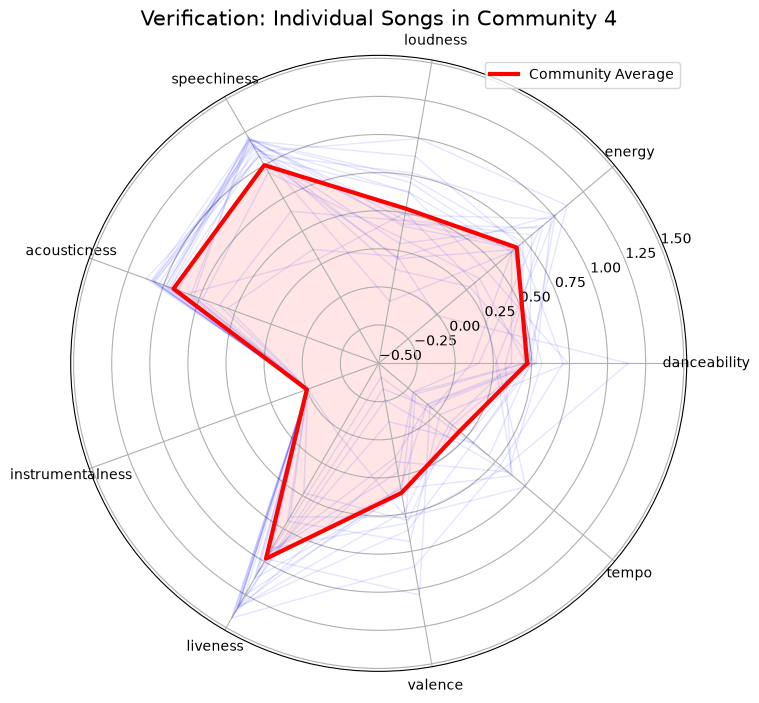

In [114]:
def plot_community_verification(comm_id, sample_size=20):
    categories = list(comm_scaled.columns)
    N = len(categories)
    angles = [n / float(N) * 2 * np.pi for n in range(N)]
    angles += angles[:1]
    
    # Get the community average
    avg_values = comm_scaled.iloc[comm_id].values.flatten().tolist()
    avg_values += avg_values[:1]
    
    # Get random songs from this community
    comm_songs = spotify[spotify['network_community'] == comm_id]
    sample_songs = comm_songs[continuous_features].sample(min(len(comm_songs), sample_size))
    # Scale sample songs using the same scaler used for the radar
    sample_scaled = scaler.transform(sample_songs)
    
    fig, ax = plt.subplots(figsize=(8, 8), subplot_kw=dict(polar=True))
    
    # Plot individual songs (thin, transparent)
    for i in range(len(sample_scaled)):
        values = sample_scaled[i].tolist()
        values += values[:1]
        ax.plot(angles, values, color='blue', alpha=0.1, linewidth=1)
    
    # Plot the Average (bold, red)
    ax.plot(angles, avg_values, color='red', linewidth=3, label='Community Average')
    ax.fill(angles, avg_values, 'red', alpha=0.1)
    
    ax.set_xticks(angles[:-1])
    ax.set_xticklabels(categories)
    ax.set_title(f"Verification: Individual Songs in Community {comm_id}", size=15)
    plt.legend()
    plt.show()

# Run this for your "spikiest" community (e.g., Community 4 or 13)
plot_community_verification(4)

In [115]:
from scipy.spatial.distance import cosine

# Calculate distance of every song to its community centroid
def calculate_fidelity(row):
    comm_id = int(row['network_community'])
    centroid = comm_features.loc[comm_id].values
    song_vec = row[continuous_features].values
    # Fidelity is 1 - Cosine Distance
    return 1 - cosine(song_vec, centroid)

spotify['fidelity'] = spotify.apply(calculate_fidelity, axis=1)

# Average Fidelity per Community
fidelity_report = spotify.groupby('network_community')['fidelity'].mean()
print("Average Acoustic Fidelity per Community (Higher = More Consistent):")
print(fidelity_report.sort_values(ascending=False))

Average Acoustic Fidelity per Community (Higher = More Consistent):
network_community
4     0.937107
18    0.867783
9     0.850422
21    0.848295
8     0.837787
13    0.828929
14    0.807863
6     0.802741
12    0.788976
10    0.781842
16    0.769126
5     0.764767
19    0.760685
3     0.753042
7     0.752188
17    0.745581
11    0.743610
2     0.739977
20    0.739165
0     0.732328
15    0.728782
1     0.723907
Name: fidelity, dtype: float64


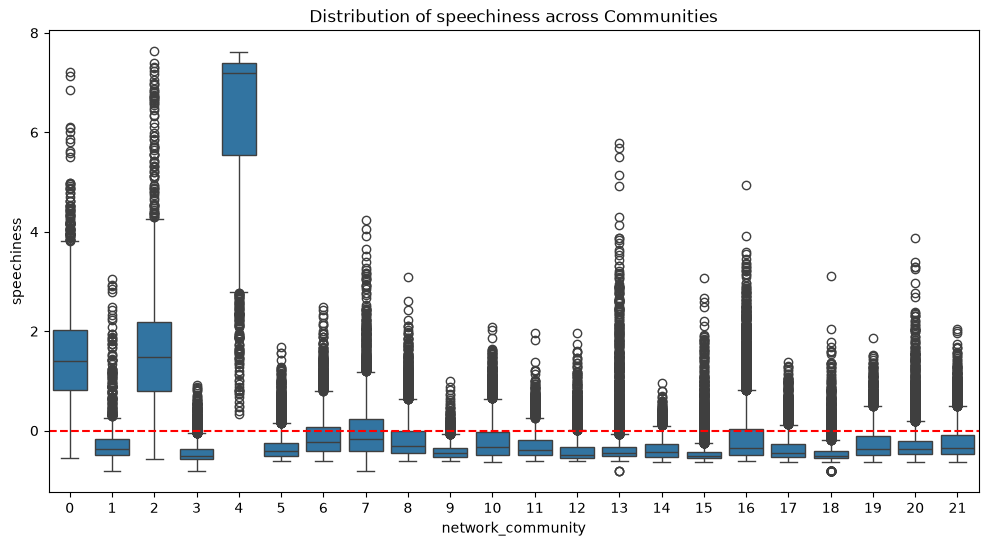

In [116]:
import seaborn as sns

# Pick a feature that has a spike in your radar (e.g., 'speechiness')
spike_feature = 'speechiness' 

plt.figure(figsize=(12, 6))
sns.boxplot(x='network_community', y=spike_feature, data=spotify)
plt.title(f"Distribution of {spike_feature} across Communities")
plt.axhline(spotify[spike_feature].mean(), color='red', linestyle='--', label='Global Average')
plt.show()

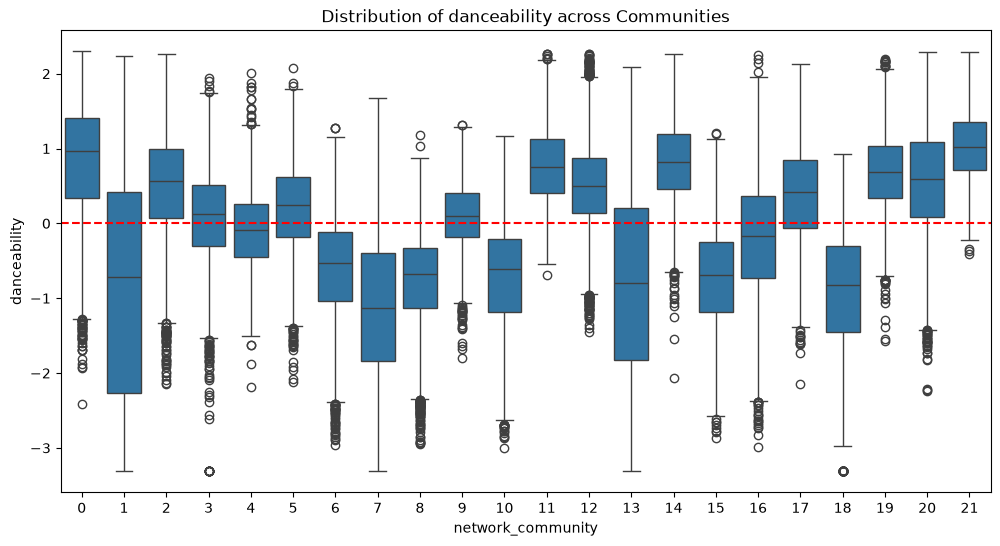

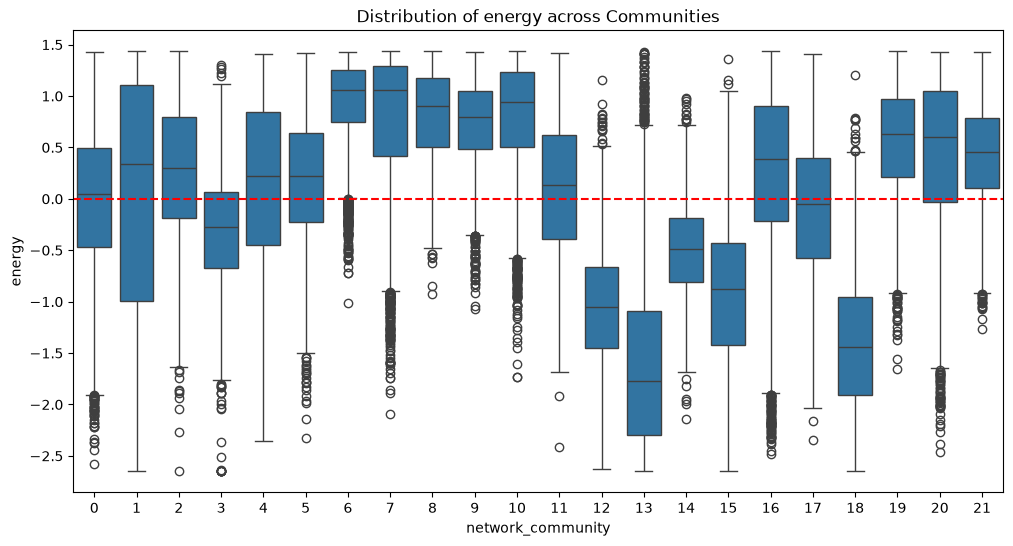

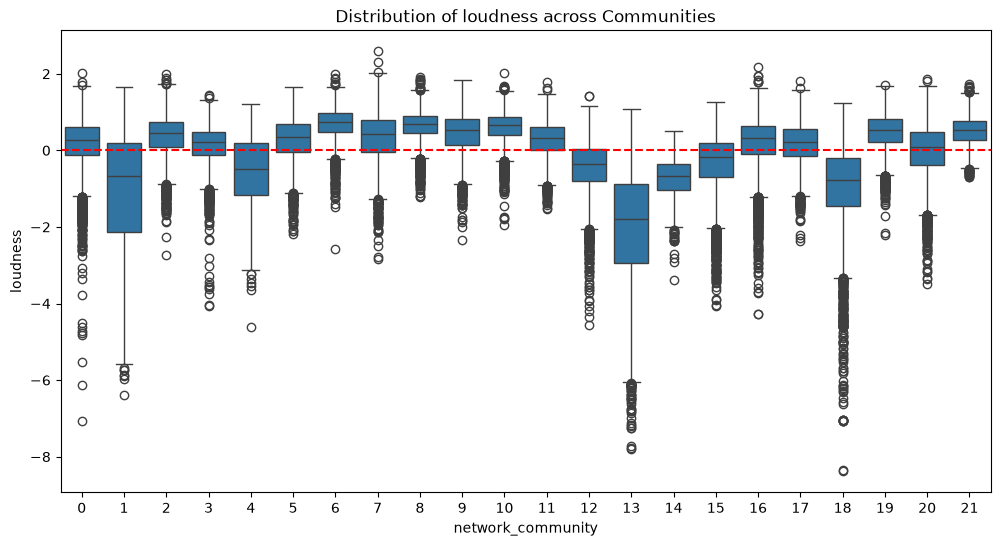

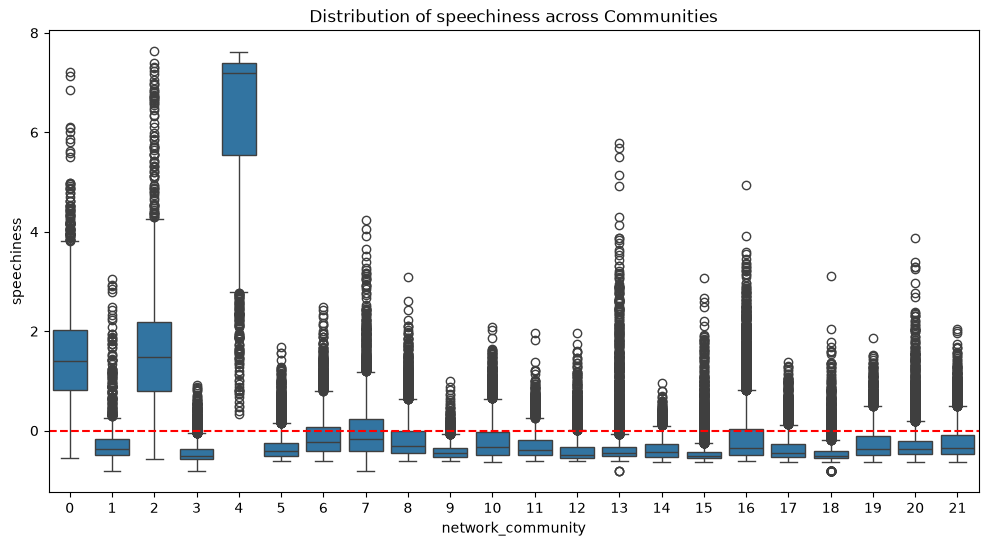

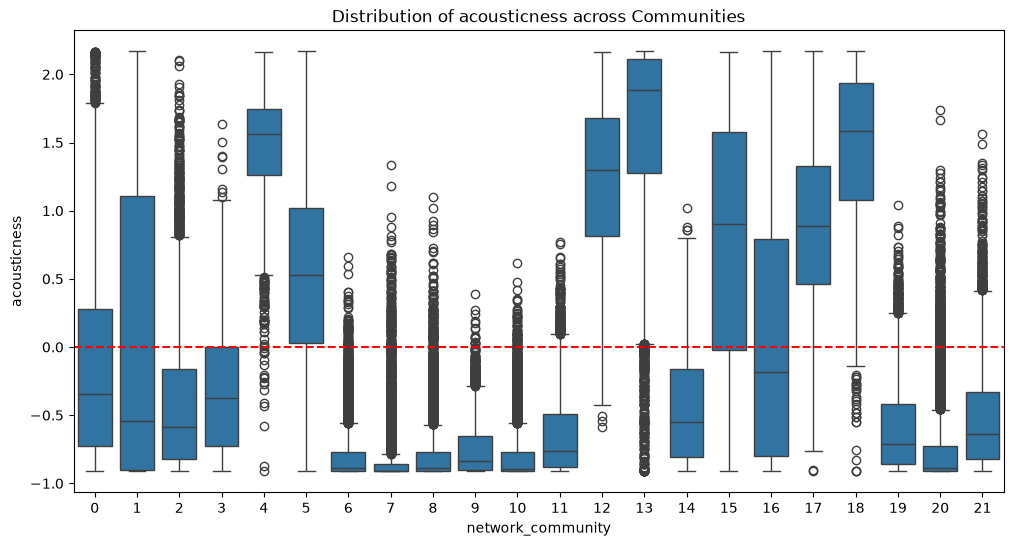

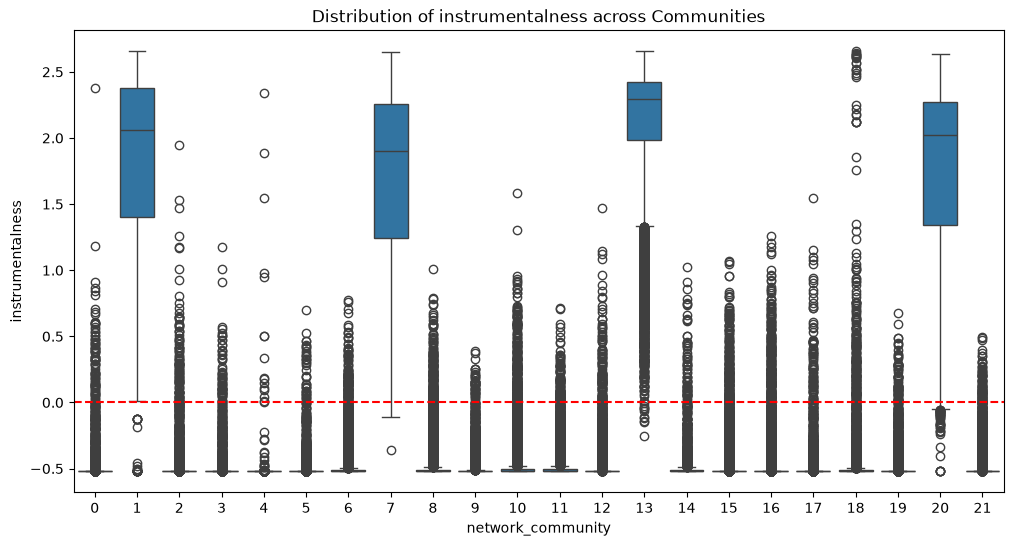

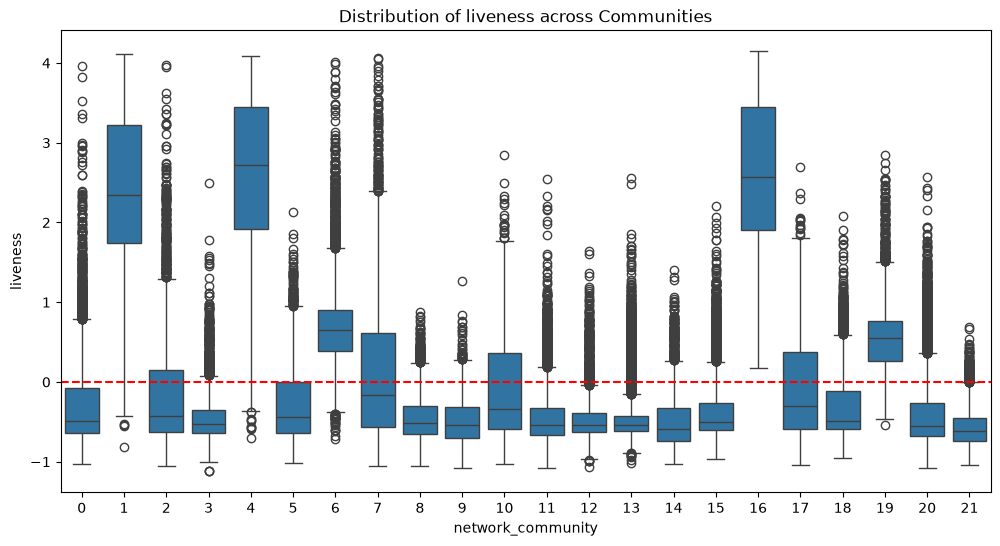

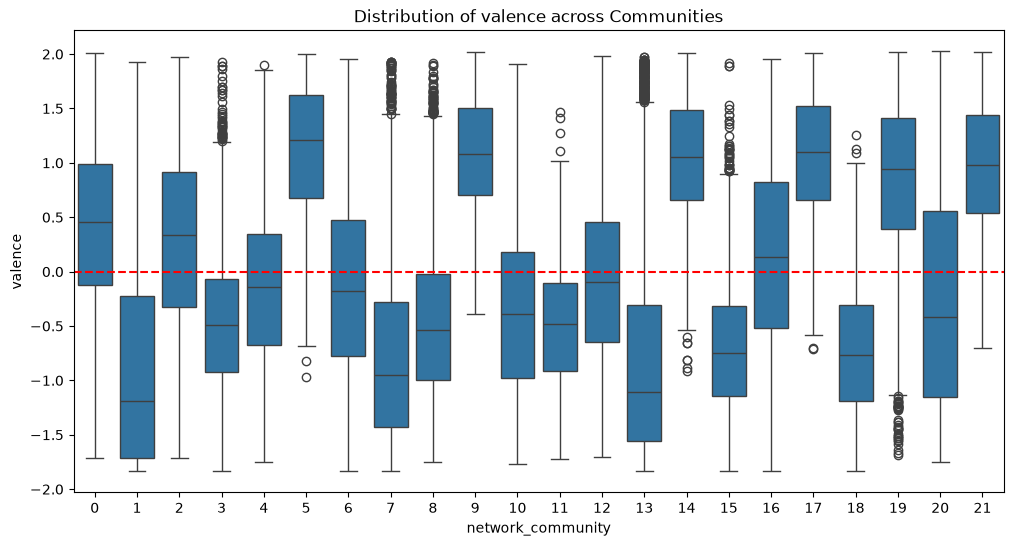

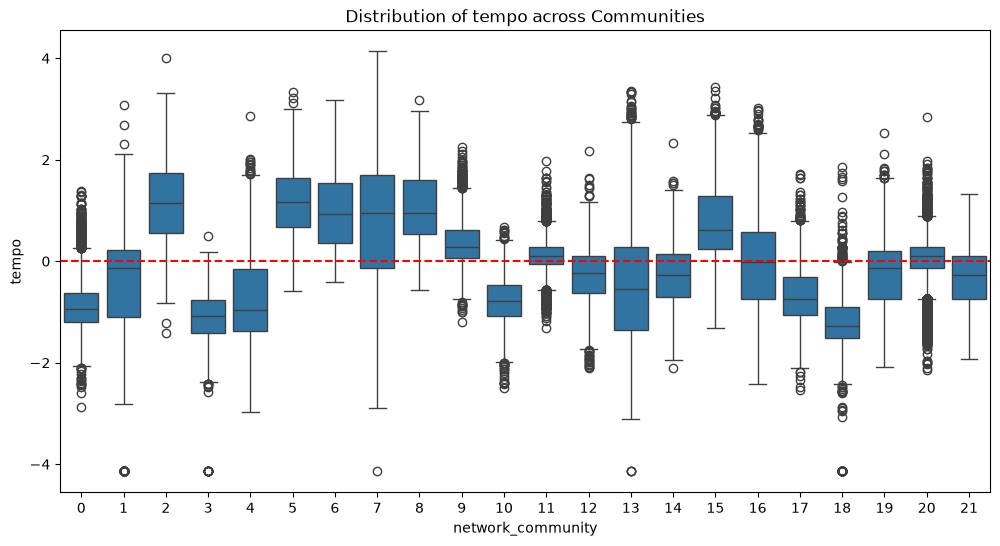

In [121]:
import seaborn as sns

# Pick a feature that has a spike in your radar (e.g., 'speechiness')

for feature in continuous_features:
    plt.figure(figsize=(12, 6))
    sns.boxplot(x='network_community', y=feature, data=spotify)
    plt.title(f"Distribution of {feature} across Communities")
    plt.axhline(spotify[feature].mean(), color='red', linestyle='--', label='Global Average')
    plt.show()

In [117]:
# 1. Calculate the Global Average for each feature
global_means = spotify[continuous_features].mean()

# 2. Calculate how much each community differs from the global average (Z-Score style)
# This highlights what makes each community 'special'
comm_diff = (comm_features - global_means) / spotify[continuous_features].std()

def get_identity(comm_id):
    # Find the feature with the highest positive deviation
    hero = comm_diff.loc[comm_id].idxmax()
    val = comm_diff.loc[comm_id].max()
    
    # Find the dominant macro-genre
    top_genre = spotify[spotify['network_community'] == comm_id]['macro_genre'].mode()[0]
    genre_pct = (spotify[spotify['network_community'] == comm_id]['macro_genre'] == top_genre).mean()
    
    return f"{hero} (+{val:.1f} std)", f"{top_genre} ({genre_pct:.1%})"

# Create a summary table for all 22
community_summary = pd.DataFrame(index=range(22))
community_summary[['Defining Feature', 'Primary Genre']] = [get_identity(i) for i in range(22)]
community_summary['Acoustic Fidelity'] = fidelity_report # From the previous step

print(community_summary.sort_values(by='Acoustic Fidelity', ascending=False))

               Defining Feature          Primary Genre  Acoustic Fidelity
4        speechiness (+6.2 std)         Spoken (75.7%)           0.937107
18      acousticness (+1.5 std)   Folk/Country (12.3%)           0.867783
9            valence (+1.1 std)           Rock (19.6%)           0.850422
21      danceability (+1.0 std)     Electronic (18.8%)           0.848295
8              tempo (+1.0 std)     Electronic (25.3%)           0.837787
13  instrumentalness (+2.1 std)  Ambient/Chill (34.1%)           0.828929
14           valence (+1.0 std)    Hip-Hop/R&B (16.0%)           0.807863
6              tempo (+1.0 std)     Electronic (24.3%)           0.802741
12      acousticness (+1.2 std)   Folk/Country (14.7%)           0.788976
10            energy (+0.8 std)          Metal (25.6%)           0.781842
16          liveness (+2.6 std)          Latin (30.3%)           0.769126
5              tempo (+1.2 std)          Latin (32.3%)           0.764767
19           valence (+0.8 std)     El

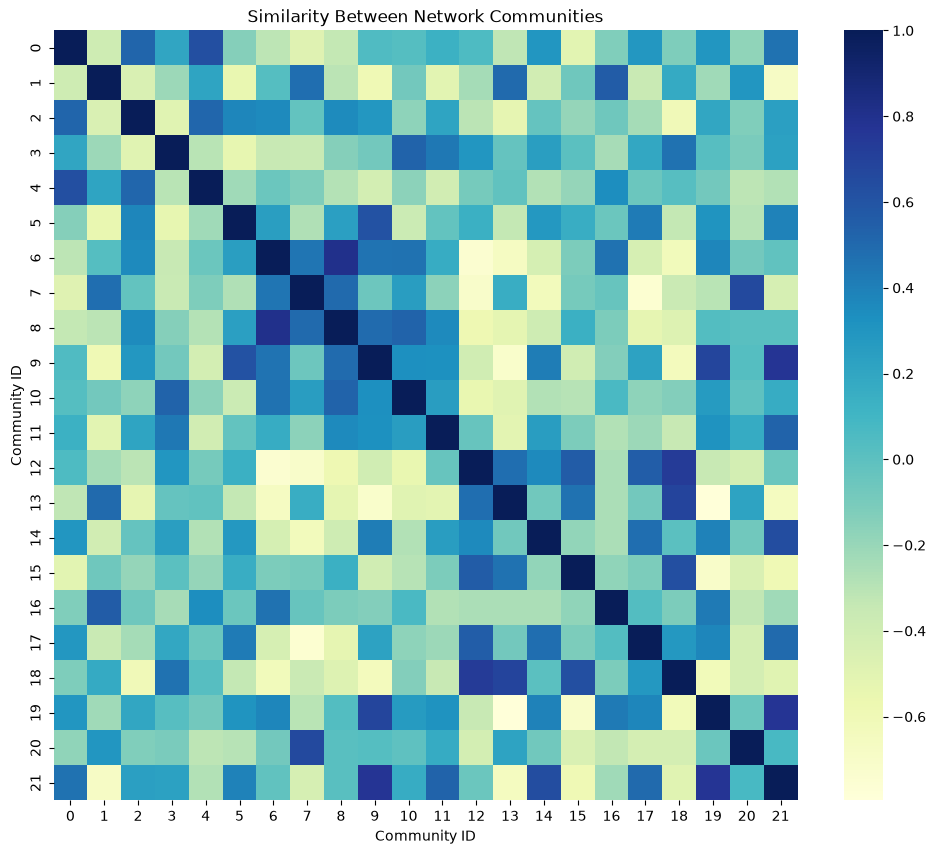

In [118]:
from sklearn.metrics.pairwise import cosine_similarity
import seaborn as sns

# Compute similarity between the 22 community centroids
comm_sim = cosine_similarity(comm_features)

plt.figure(figsize=(12, 10))
sns.heatmap(comm_sim, annot=False, cmap='YlGnBu', xticklabels=range(22), yticklabels=range(22))
plt.title("Similarity Between Network Communities")
plt.xlabel("Community ID")
plt.ylabel("Community ID")
plt.show()

In [120]:
archetype_list = []

for i in range(22):
    # Get the song with the highest fidelity in this community
    best_song = spotify[spotify['network_community'] == i].sort_values(by='fidelity', ascending=False).iloc[0]
    archetype_list.append({
        'Comm': i,
        'Track': best_song['name'],
        'Artist': best_song['artists'],
        'Genre': best_song['macro_genre']
    })

archetype_df = pd.DataFrame(archetype_list)
print("The Archetype Gallery (One representative song for every community):")
print(archetype_df)

The Archetype Gallery (One representative song for every community):
    Comm                         Track                            Artist  \
0      0                    starstruck                       Arden Jones   
1      1                Relaxing Waves      Ocean Sounds;Calm Sea Sounds   
2      2                      Immortal                         21 Savage   
3      3        Say It (feat. Tove Lo)                             Flume   
4      4                  Creepy Smile                  Keith Alberstadt   
5      5                      Me Falla                     Juancho Style   
6      6         The Light Tears Apart                          Shivered   
7      7  Satt scheint der Sud der Tat                              Horn   
8      8                     Avalanche              Bring Me The Horizon   
9      9          Big Fun - Radio Edit                        Inner City   
10    10           Show Me How to Live                        Audioslave   
11    11           

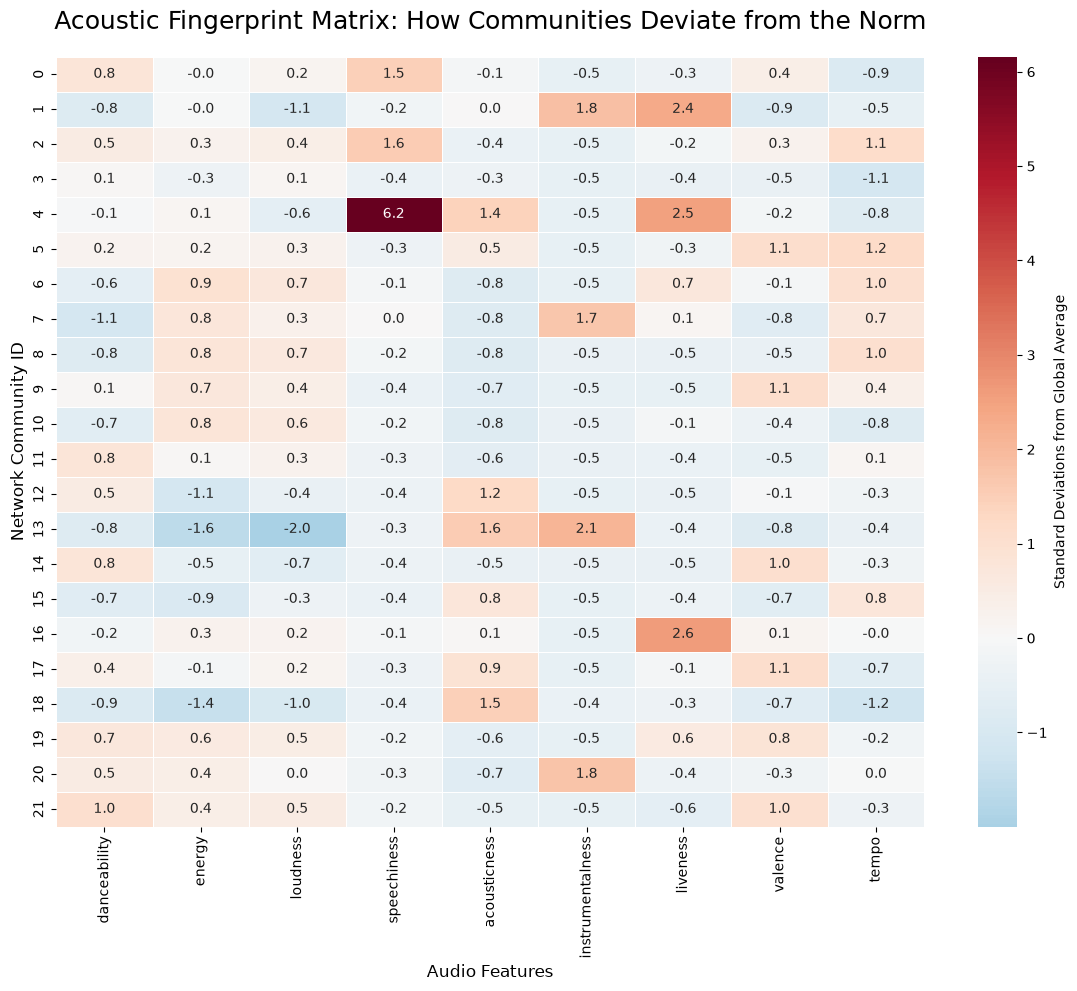

In [122]:
import seaborn as sns
import matplotlib.pyplot as plt

# 1. Calculate Z-Scores (Standard Deviations from the Mean)
# This makes features like 'loudness' (-60 to 0) comparable to 'danceability' (0 to 1)
global_means = spotify[continuous_features].mean()
global_stds = spotify[continuous_features].std()
comm_z_scores = (comm_features - global_means) / global_stds

# 2. Plotting the Heatmap
plt.figure(figsize=(14, 10))
sns.heatmap(comm_z_scores, 
            annot=True,      # Show the numbers
            fmt=".1f",       # 1 decimal place
            cmap="RdBu_r",   # Red for high, Blue for low, White for average
            center=0,        # Center the color bar at the global mean
            linewidths=.5, 
            cbar_kws={'label': 'Standard Deviations from Global Average'})

plt.title("Acoustic Fingerprint Matrix: How Communities Deviate from the Norm", fontsize=18, pad=20)
plt.xlabel("Audio Features", fontsize=12)
plt.ylabel("Network Community ID", fontsize=12)
plt.show()

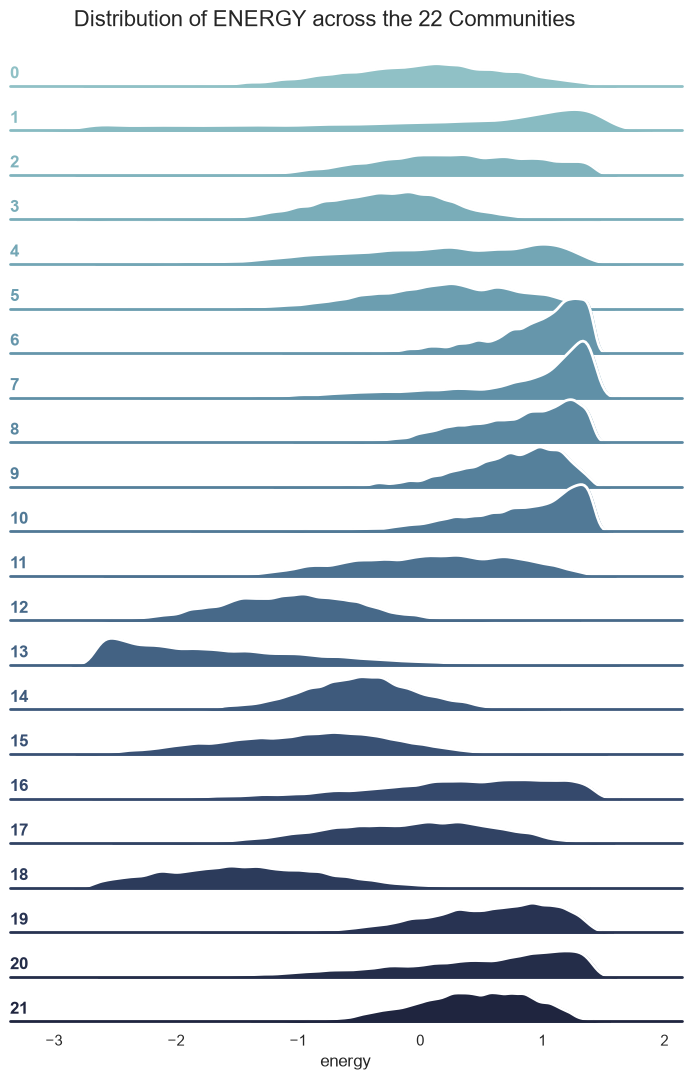

In [123]:
import seaborn as sns

def plot_ridge_joy(feature_name):
    # Set the aesthetic style
    sns.set_theme(style="white", rc={"axes.facecolor": (0, 0, 0, 0)})

    # Initialize the FacetGrid object
    pal = sns.cubehelix_palette(22, rot=-.25, light=.7)
    g = sns.FacetGrid(spotify, row="network_community", hue="network_community", 
                     aspect=15, height=.5, palette=pal)

    # Draw the densities
    g.map(sns.kdeplot, feature_name, bw_adjust=.5, clip_on=False, fill=True, alpha=1, linewidth=1.5)
    g.map(sns.kdeplot, feature_name, clip_on=False, color="w", lw=2, bw_adjust=.5)

    # passing color=None to refline so it matches the hue
    g.refline(y=0, linewidth=2, linestyle="-", color=None, clip_on=False)

    # Define and use a simple function to label the plot in axes coordinates
    def label(x, color, label):
        ax = plt.gca()
        ax.text(0, .2, label, fontweight="bold", color=color,
                ha="left", va="center", transform=ax.transAxes)

    g.map(label, feature_name)

    # Set the subplots to overlap
    g.figure.subplots_adjust(hspace=-.25)

    # Remove axes details that don't play well with overlap
    g.set_titles("")
    g.set(yticks=[], ylabel="")
    g.despine(bottom=True, left=True)
    plt.suptitle(f"Distribution of {feature_name.upper()} across the 22 Communities", fontsize=16)
    plt.show()

# Run for the most interesting feature
plot_ridge_joy('energy')

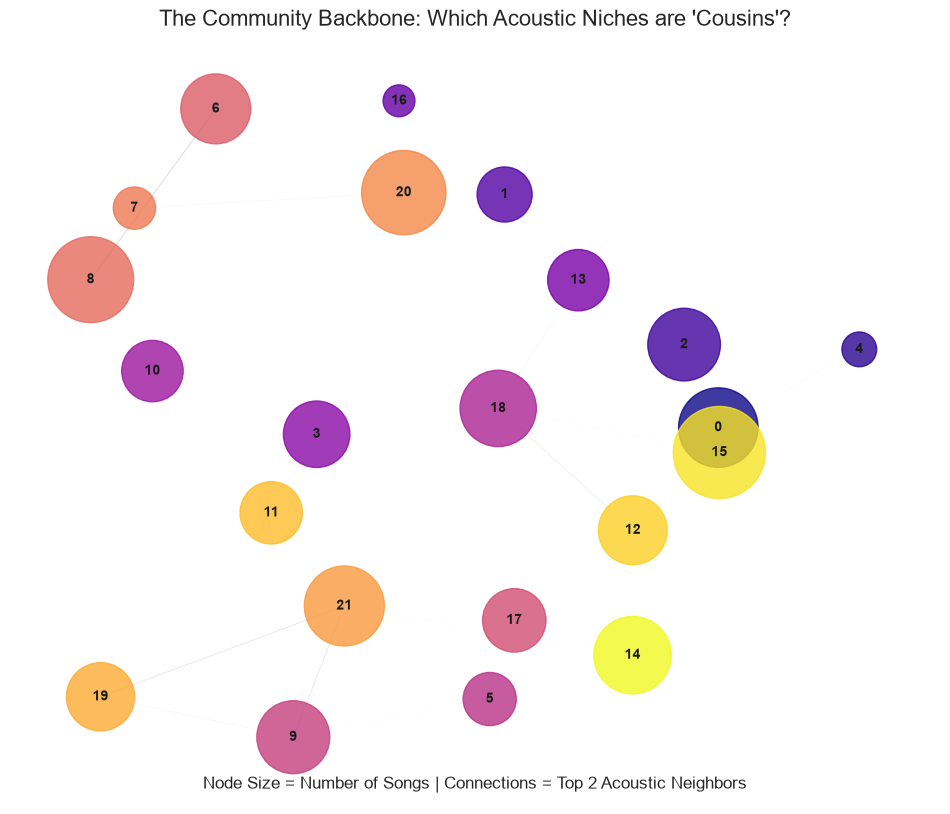

In [126]:
import networkx as nx
import matplotlib.pyplot as plt
from sklearn.metrics.pairwise import cosine_similarity

# 1. Compute similarity between the 22 community centroids
comm_sim = cosine_similarity(comm_features)
sim_df = pd.DataFrame(comm_sim, index=range(22), columns=range(22))

# 2. Build the Meta-Graph
G_meta = nx.Graph()

# 3. Connect each community to its TOP 2 "Closest Cousins"
# This guarantees the graph won't be blank!
for i in range(22):
    # Get the most similar communities for community i (excluding itself)
    closest_cousins = sim_df.loc[i].sort_values(ascending=False)[1:3] 
    for neighbor, score in closest_cousins.items():
        G_meta.add_edge(i, neighbor, weight=score)

# 4. Visualization
plt.figure(figsize=(12, 10))

# Use Kamada-Kawai layout (better for seeing clusters of communities)
pos = nx.kamada_kawai_layout(G_meta)

# Node size based on how many songs are in that community
node_sizes = spotify['network_community'].value_counts().sort_index() * 0.5

# Node color based on the "Entropy" or "Fidelity" we calculated earlier
# (Or just a nice color map)
node_colors = range(22)

nx.draw_networkx_nodes(G_meta, pos, node_size=node_sizes, 
                       node_color=node_colors, cmap='plasma', alpha=0.8)

nx.draw_networkx_labels(G_meta, pos, font_size=10, font_weight='bold')

# Edge width based on how similar the communities are
edges = G_meta.edges(data=True)
weights = [d['weight']**10 * 5 for u, v, d in edges] # Emphasize strong links
nx.draw_networkx_edges(G_meta, pos, width=weights, edge_color='gray', alpha=0.3)

plt.title("The Community Backbone: Which Acoustic Niches are 'Cousins'?", fontsize=16)
plt.annotate("Node Size = Number of Songs | Connections = Top 2 Acoustic Neighbors", 
             xy=(0.5, 0.02), xycoords='axes fraction', ha='center')
plt.axis('off')
plt.show()

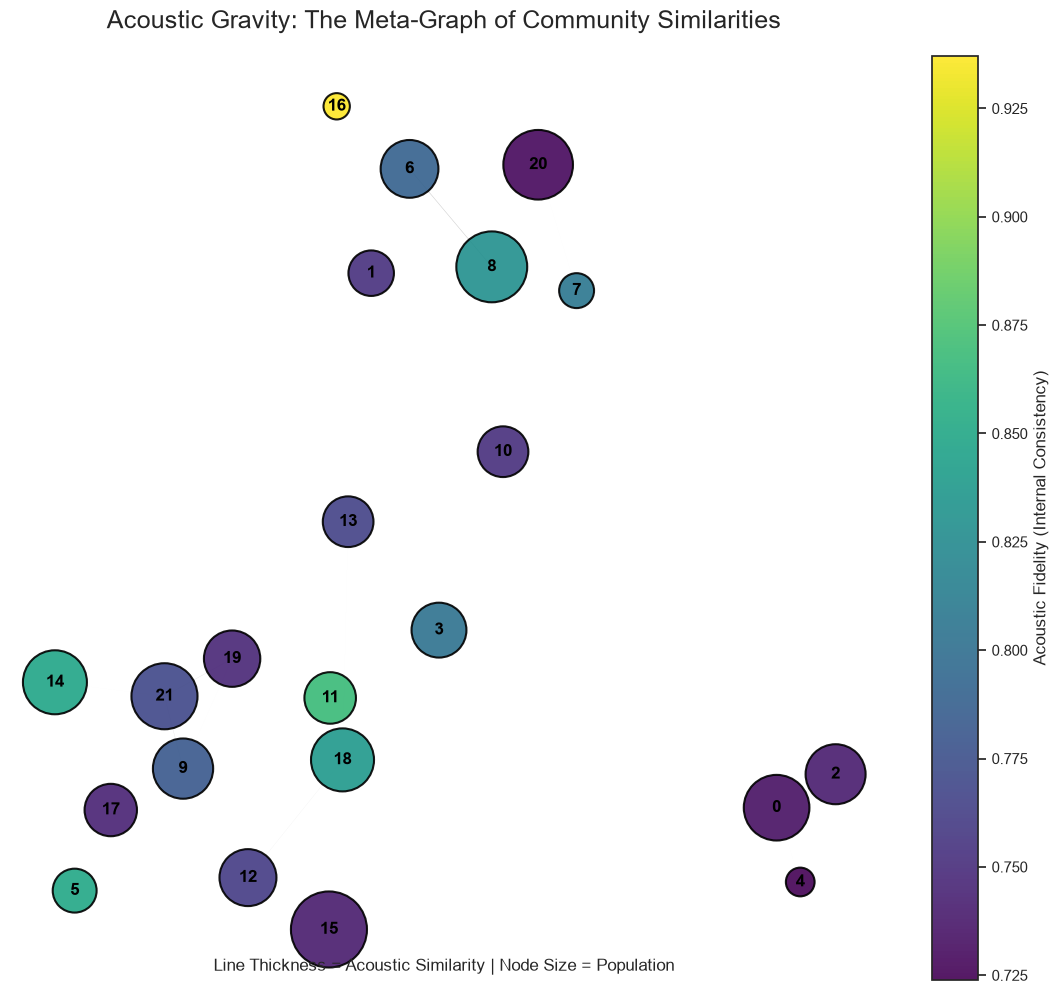

In [127]:
import networkx as nx
import matplotlib.pyplot as plt
from sklearn.metrics.pairwise import cosine_similarity
import pandas as pd

# 1. Similarity Matrix
comm_sim = cosine_similarity(comm_features)
sim_df = pd.DataFrame(comm_sim, index=range(22), columns=range(22))

# 2. Build Graph
G_weighted = nx.Graph()

# 3. Add Weighted Edges (Top 2 Neighbors)
for i in range(22):
    # Get top similarities (excluding self)
    top_neighbors = sim_df.loc[i].sort_values(ascending=False)[1:3]
    for neighbor, score in top_neighbors.items():
        # We store the raw score to use as 'weight'
        G_weighted.add_edge(i, neighbor, weight=score)

# 4. Visualization Setup
plt.figure(figsize=(14, 12))

# Layout: 'weight' parameter here tells the algorithm to pull similar nodes closer
pos = nx.spring_layout(G_weighted, weight='weight', k=0.7, iterations=100)

# Node Size: Relative to the number of songs in each community
node_counts = spotify['network_community'].value_counts().sort_index()
# Scaling node size for visibility
sizes = (node_counts / node_counts.max()) * 3000 

# Node Color: Let's use the 'Fidelity' to show which communities are most consistent
node_colors = fidelity_report.sort_index().values

# Edge Width & Alpha based on Strength
edges = G_weighted.edges(data=True)
# We amplify the difference in weights for visual impact (e.g., raise to power of 10)
edge_widths = [d['weight']**15 * 10 for u, v, d in edges]
edge_alphas = [d['weight']**5 for u, v, d in edges]

# 5. Drawing
# Draw Nodes
nodes = nx.draw_networkx_nodes(G_weighted, pos, 
                               node_size=sizes, 
                               node_color=node_colors, 
                               cmap='viridis', 
                               alpha=0.9, 
                               edgecolors='black', 
                               linewidths=1.5)

# Draw Labels
nx.draw_networkx_labels(G_weighted, pos, font_size=12, font_weight='bold', font_color='black')

# Draw Edges one by one to apply individual alphas
for (u, v, d), w, a in zip(edges, edge_widths, edge_alphas):
    nx.draw_networkx_edges(G_weighted, pos, 
                           edgelist=[(u, v)], 
                           width=w, 
                           alpha=a, 
                           edge_color='gray')

# Colorbar for Fidelity
cbar = plt.colorbar(nodes)
cbar.set_label('Acoustic Fidelity (Internal Consistency)', size=12)

plt.title("Acoustic Gravity: The Meta-Graph of Community Similarities", fontsize=18, pad=20)
plt.annotate("Line Thickness = Acoustic Similarity | Node Size = Population", 
             xy=(0.5, 0.01), xycoords='axes fraction', ha='center', fontsize=12)
plt.axis('off')
plt.show()

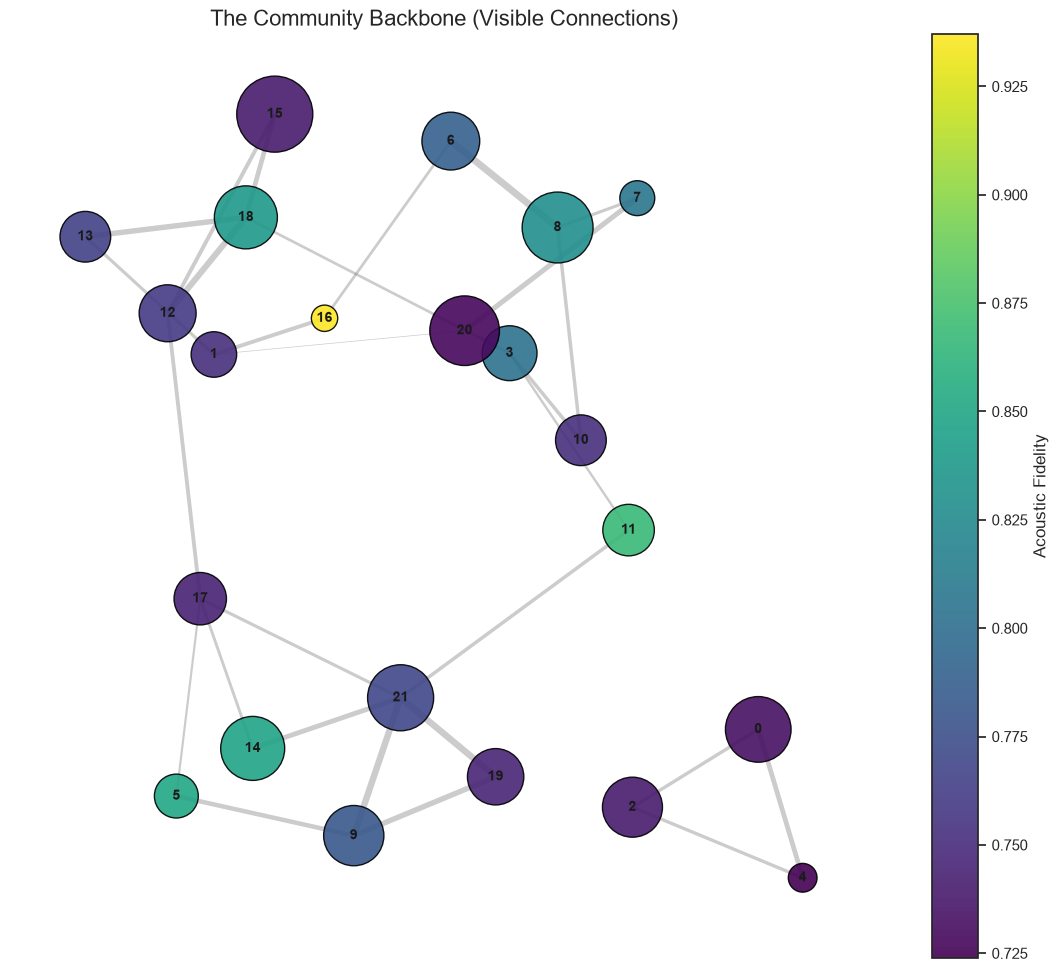

Min similarity between cousins: 0.2951
Max similarity between cousins: 0.8101


: 

In [ ]:
# --- REVISED DRAWING SECTION ---
plt.figure(figsize=(14, 12))
pos = nx.spring_layout(G_weighted, weight='weight', k=0.5)

# Calculate widths using a gentler approach: (Similarity - Min Similarity)
# This ensures even weak connections are visible
raw_weights = [d['weight'] for u, v, d in G_weighted.edges(data=True)]
min_w, max_w = min(raw_weights), max(raw_weights)

# Scale weights so they range from 0.5 to 5.0 in thickness
def scale_weight(w):
    return 0.5 + 4.5 * ((w - min_w) / (max_w - min_w + 1e-9))

edge_widths = [scale_weight(d['weight']) for u, v, d in G_weighted.edges(data=True)]

# Draw Nodes
nodes = nx.draw_networkx_nodes(G_weighted, pos, 
                               node_size=sizes, 
                               node_color=node_colors, 
                               cmap='viridis', alpha=0.9, edgecolors='black')

# Draw Labels
nx.draw_networkx_labels(G_weighted, pos, font_size=10, font_weight='bold')

# Draw Edges with the new gentle scaling
nx.draw_networkx_edges(G_weighted, pos, width=edge_widths, edge_color='gray', alpha=0.4)

plt.colorbar(nodes, label='Acoustic Fidelity')
plt.title("The Community Backbone (Visible Connections)", fontsize=16)
plt.axis('off')
plt.show()

# Print the similarities to see why they were invisible
print(f"Min similarity between cousins: {min_w:.4f}")
print(f"Max similarity between cousins: {max_w:.4f}")